# TDA

#### 分析の流れ
1. 目的設定
2. データ読み込み・前処理
3. TDAに用いる系列の選択
4. Sliding Window / Takens Embedding による点群化
5. Persistent Homology の計算
6. Persistence Diagram / Barcode の可視化
7. TDA特徴量の作成
8. TDA特徴量の考察

## 0. ライブラリの読み込み

In [1]:
# 数値計算を行うライブラリ
import pandas as pd
import numpy as np

# グラフを描画するためのライブラリ
import matplotlib.pyplot as plt

# 標準化するライブラリ
from sklearn.preprocessing import StandardScaler

# 表示設定
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 50)

## 1. 目的の設定
本ノートブックでは、時系列データに対して Sliding Window / Takens Embedding を適用し、
得られた点群に対して Persistent Homology を計算する。

そのうえで、Persistence Diagram / Barcode から
時系列の周期性・ループ構造・位相的な複雑さを表すTDA特徴量を抽出することを目的とする。

## 2. データの読み込み・前処理

本分析では、家庭の電力使用量データを読み込み、Date列とTime列を結合してdatetime型のindexを作成した。

元データは分単位の時系列データであるが、そのままTDAを適用すると点数が多く計算負荷が大きくなる。そのため、まずは日次平均に集約したデータを用いる。

目的変数は `Global_active_power` とし、以後のTDA分析ではこの系列を対象に Sliding Window / Takens Embedding を行う。

### 2.1 データの読み込み

In [2]:
file_path = "data/household_power_consumption.txt"

df = pd.read_csv(
    file_path,
    sep=";",
    na_values="?",
    low_memory=False
)

print("データの先頭")
display(df.head())

print("\nデータの形状")
print(df.shape)

print("\n列名")
print(df.columns)

print("\nデータ型")
print(df.dtypes)

データの先頭


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0



データの形状
(2075259, 9)

列名
Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

データ型
Date                      object
Time                      object
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


## 2.2 日時indexの作成

In [3]:
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

# datetime を index に設定
df = df.set_index("datetime")

# 元の Date, Time 列は不要なので削除
df = df.drop(columns=["Date", "Time"])

# datetime の変換に失敗した行があれば削除
df = df.dropna(subset=df.columns)

print("datetime index 設定後")
display(df.head())

print("\nデータ型")
print(df.dtypes)

print("\n欠損値数")
print(df.isna().sum())

datetime index 設定後


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0



データ型
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

欠損値数
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


## 2.3 数値型への変換

In [4]:
numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("数値型変換後のデータ型")
print(df.dtypes)

print("\n欠損値数")
print(df.isna().sum())

数値型変換後のデータ型
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

欠損値数
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


## 2.4 欠損値処理

In [5]:
# 時系列順に並べる
df = df.sort_index()

# 時間方向に補間
df = df.interpolate(method="time")

# 先頭・末尾に残った欠損を削除
df = df.dropna()

print("欠損値処理後の欠損値数")
print(df.isna().sum())

print("\nデータの形状")
print(df.shape)

欠損値処理後の欠損値数
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

データの形状
(2049280, 7)


## 2.5 日時データへの集約

In [6]:
df_daily = df.resample("D").mean()

# 欠損があれば再度補間
df_daily = df_daily.interpolate(method="time").dropna()

print("日次データの先頭")
display(df_daily.head())

print("\n日次データの形状")
print(df_daily.shape)

print("\n日次データの欠損値数")
print(df_daily.isna().sum())

日次データの先頭


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.000000,1.838889,9.765972



日次データの形状
(1442, 7)

日次データの欠損値数
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


## 2.6 目的変数 Global_active_power の確認

目的変数の先頭


datetime
2006-12-16    3.053475
2006-12-17    2.354486
2006-12-18    1.530435
2006-12-19    1.157079
2006-12-20    1.545658
Freq: D, Name: Global_active_power, dtype: float64


基本統計量


count    1442.000000
mean        1.090890
std         0.420265
min         0.173818
25%         0.810492
50%         1.078993
75%         1.319540
max         3.314851
Name: Global_active_power, dtype: float64

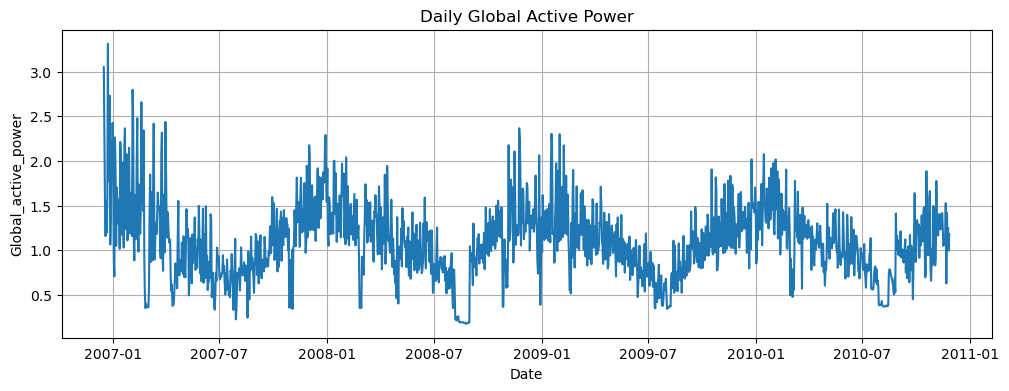

In [7]:
target_col = "Global_active_power"

y = df_daily[target_col]

print("目的変数の先頭")
display(y.head())

print("\n基本統計量")
display(y.describe())

plt.figure(figsize=(12, 4))
plt.plot(y)
plt.title("Daily Global Active Power")
plt.xlabel("Date")
plt.ylabel("Global_active_power")
plt.grid(True)
plt.show()

## 3. TDAに用いる系列の選択

本分析では、TDAに用いる時系列として `Global_active_power` の日次平均系列を選択する。

`Global_active_power` は家庭全体の有効電力消費量を表す主要な変数であり、電力使用量の周期性や反復構造を確認する対象として適している。

Persistent Homology では点群間の距離を用いるため、値のスケールが結果に影響する。そのため、TDAに用いる前に `Global_active_power` を標準化し、平均0・分散1の系列に変換した。

以後の Sliding Window / Takens Embedding では、この標準化済み系列 `tda_series_scaled` を使用する。

In [8]:
# TDAに用いる列
tda_col = "Global_active_power"

# df_daily から対象系列を取り出す
tda_series = df_daily[tda_col].copy()

# 欠損値がないか確認
print("TDA対象系列:", tda_col)
print("データ数:", len(tda_series))
print("欠損値数:", tda_series.isna().sum())

# 先頭を確認
display(tda_series.head())

TDA対象系列: Global_active_power
データ数: 1442
欠損値数: 0


datetime
2006-12-16    3.053475
2006-12-17    2.354486
2006-12-18    1.530435
2006-12-19    1.157079
2006-12-20    1.545658
Freq: D, Name: Global_active_power, dtype: float64

## 3.1 TDA対象系列の標準化

In [9]:
scaler = StandardScaler()

tda_values_scaled = scaler.fit_transform(
    tda_series.values.reshape(-1, 1)
).flatten()

# Series に戻す
tda_series_scaled = pd.Series(
    tda_values_scaled,
    index=tda_series.index,
    name=f"{tda_col}_scaled"
)

print("標準化後の基本統計量")
display(tda_series_scaled.describe())

標準化後の基本統計量


count    1.442000e+03
mean    -2.611565e-16
std      1.000347e+00
min     -2.182887e+00
25%     -6.674243e-01
50%     -2.831867e-02
75%      5.442501e-01
max      5.293649e+00
Name: Global_active_power_scaled, dtype: float64

## 3.2 原系列と標準化後系列の可視化

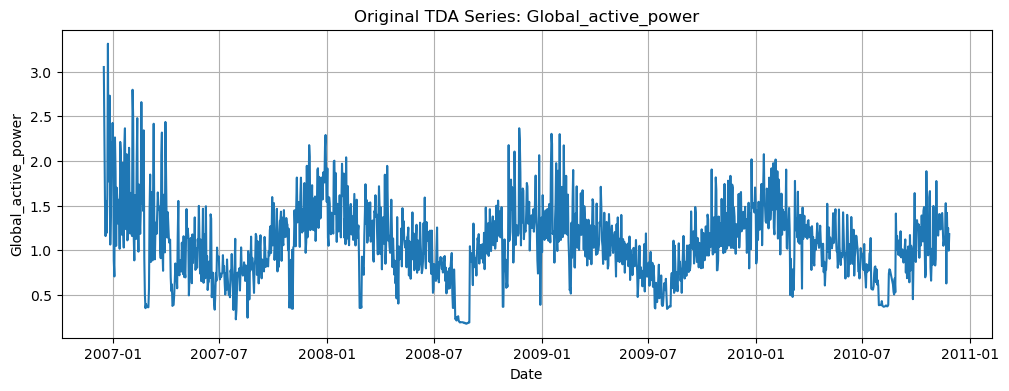

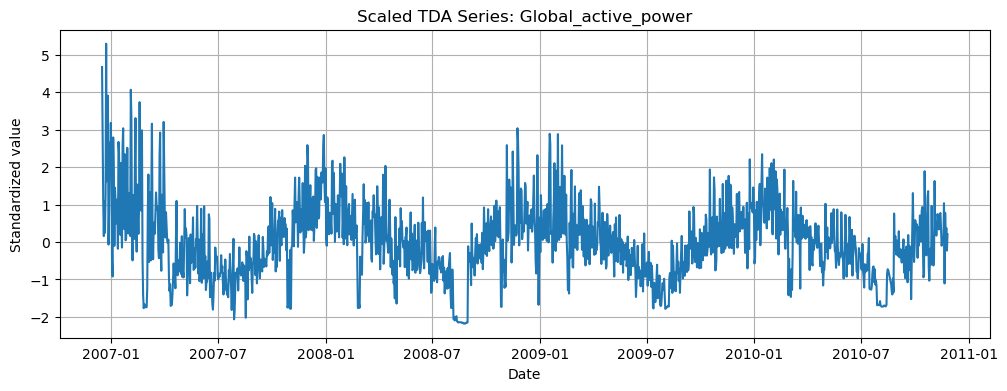

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(tda_series)
plt.title("Original TDA Series: Global_active_power")
plt.xlabel("Date")
plt.ylabel("Global_active_power")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(tda_series_scaled)
plt.title("Scaled TDA Series: Global_active_power")
plt.xlabel("Date")
plt.ylabel("Standardized value")
plt.grid(True)
plt.show()

## 3.3 TDA対象系列の最終確認

In [11]:
print("TDAに用いる系列")
print("列名:", tda_series_scaled.name)
print("開始日:", tda_series_scaled.index.min())
print("終了日:", tda_series_scaled.index.max())
print("データ数:", len(tda_series_scaled))
print("平均:", tda_series_scaled.mean())
print("標準偏差:", tda_series_scaled.std())
print("欠損値数:", tda_series_scaled.isna().sum())

TDAに用いる系列
列名: Global_active_power_scaled
開始日: 2006-12-16 00:00:00
終了日: 2010-11-26 00:00:00
データ数: 1442
平均: -2.6115648401723514e-16
標準偏差: 1.000346921085892
欠損値数: 0


## 4.4. Sliding Window / Takens Embedding による点群化

### 4.4.1 点群化の考え方

ここでは、1変量時系列 `Global_active_power` を Sliding Window / Takens Embedding によって点群へ変換する。

時刻 $t$ の値だけを見るのではなく、

$$
[x_t, x_{t+	au}, x_{t+2	au}, \ldots, x_{t+(m-1)	au}]
$$

を1つの点として扱う。  
ここで、`embedding_dim = m` は1点を作るために使う時点数、`delay = τ` は何日間隔で値を取るかを表す。

今回は日次データなので、まずは `delay=1` とし、`embedding_dim=30` とする。つまり、約30日分の推移パターンを1つの点として扱う。

In [12]:
# =========================
# 4.4.1 TDAに使う系列の確認
# =========================

# 基本方針:
# - 3章で作成した標準化済み系列 tda_series_scaled を使う
# - もし存在しない場合は tda_series を使う
# - さらに tda_series もない場合は df_daily から作る

if "tda_series_scaled" in globals():
    series_for_embedding = tda_series_scaled.copy()
    print("標準化済み系列 tda_series_scaled を使用します。")
elif "tda_series" in globals():
    series_for_embedding = tda_series.copy()
    print("tda_series を使用します。")
else:
    target_col = "Global_active_power"
    series_for_embedding = df_daily[target_col].copy()
    print("df_daily から TDA 対象系列を作成しました。")

# 念のため欠損値を除去し、時系列順に並べる
series_for_embedding = series_for_embedding.dropna().sort_index()

print("TDA点群化に使う系列")
print("系列名:", series_for_embedding.name)
print("データ数:", len(series_for_embedding))
print("開始日:", series_for_embedding.index.min())
print("終了日:", series_for_embedding.index.max())
print("欠損値数:", series_for_embedding.isna().sum())

display(series_for_embedding.head())

標準化済み系列 tda_series_scaled を使用します。
TDA点群化に使う系列
系列名: Global_active_power_scaled
データ数: 1442
開始日: 2006-12-16 00:00:00
終了日: 2010-11-26 00:00:00
欠損値数: 0


datetime
2006-12-16    4.671499
2006-12-17    3.007711
2006-12-18    1.046239
2006-12-19    0.157549
2006-12-20    1.082476
Freq: D, Name: Global_active_power_scaled, dtype: float64

### 4.4.2 Sliding Window / Takens Embedding の関数

この関数は、長さ $n$ の時系列から、次のような点を作る。

- 1点目: `[x_0, x_1, ..., x_29]`
- 2点目: `[x_1, x_2, ..., x_30]`
- 3点目: `[x_2, x_3, ..., x_31]`

`embedding_dim=30`, `delay=1` の場合、各点は30次元ベクトルになる。

In [13]:
# =========================
# 4.4.2 Sliding Window / Takens Embedding 関数
# =========================

def make_takens_embedding(series, embedding_dim=30, delay=1, stride=1):
    """
    1変量時系列を Sliding Window / Takens Embedding により点群化する関数。

    Parameters
    ----------
    series : pd.Series
        時系列データ。index は日時であることを想定。
    embedding_dim : int
        埋め込み次元。1つの点を構成する時点数。
    delay : int
        遅延幅。日次データなら delay=1 は1日ずつずらすことを意味する。
    stride : int
        窓を何ステップずつ動かすか。通常は1。

    Returns
    -------
    point_cloud : np.ndarray, shape = (n_points, embedding_dim)
        Takens embedding によって得られた点群。
    point_cloud_index : pd.DatetimeIndex
        各点に対応する日時。ここでは各窓の最後の日付を採用する。
    """
    if not isinstance(series, pd.Series):
        raise TypeError("series は pd.Series として渡してください。")

    if embedding_dim <= 1:
        raise ValueError("embedding_dim は 2 以上にしてください。")

    if delay <= 0:
        raise ValueError("delay は 1 以上にしてください。")

    if stride <= 0:
        raise ValueError("stride は 1 以上にしてください。")

    values = series.dropna().values.astype(float)
    index = series.dropna().index

    n = len(values)
    window_span = (embedding_dim - 1) * delay

    if n <= window_span:
        raise ValueError(
            "データ数が不足しています。"
            f"必要な最小データ数は {(embedding_dim - 1) * delay + 1} ですが、"
            f"現在は {n} です。"
        )

    start_positions = range(0, n - window_span, stride)

    point_cloud = np.array([
        values[i : i + embedding_dim * delay : delay]
        for i in start_positions
    ])

    # 各点は「窓の最後の日付」に対応させる
    point_cloud_index = pd.Index([
        index[i + window_span]
        for i in start_positions
    ])

    return point_cloud, point_cloud_index

### 4.4.3 点群化の実行

今回は最小構成として、以下の設定で実行する。

- `embedding_dim = 30`
- `delay = 1`
- `stride = 1`

これは「30日分の電力消費パターン」を1つの点として扱う設定である。

In [14]:
# =========================
# 4.4.3 点群化の実行
# =========================

embedding_dim = 30   # 1点を30日分の値で構成する
delay = 1            # 1日間隔で値を取る
stride = 1           # 1日ずつ窓を動かす

X_takens, X_takens_index = make_takens_embedding(
    series_for_embedding,
    embedding_dim=embedding_dim,
    delay=delay,
    stride=stride
)

print("Takens Embedding による点群化が完了しました。")
print("点群の形状:", X_takens.shape)
print("点の数:", X_takens.shape[0])
print("各点の次元:", X_takens.shape[1])
print("対応する期間:", X_takens_index.min(), "〜", X_takens_index.max())

# 先頭5点を確認
X_takens_df = pd.DataFrame(
    X_takens,
    index=X_takens_index,
    columns=[f"lag_{i}" for i in range(embedding_dim)]
)

display(X_takens_df.head())

Takens Embedding による点群化が完了しました。
点群の形状: (1413, 30)
点の数: 1413
各点の次元: 30
対応する期間: 2007-01-14 00:00:00 〜 2010-11-26 00:00:00


,lag_0,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29
2007-01-14,4.671499,3.007711,1.046239,0.157549,1.082476,0.244855,1.273543,5.293649,1.618475,1.937677,3.906349,-0.069625,0.829389,2.650557,2.020427,3.179184,1.947403,-0.498611,-0.920420,2.791093,1.888491,-0.103316,1.449224,1.108282,0.492871,0.965201,1.131149,-0.181142,2.671090,2.378667
2007-01-15,3.007711,1.046239,0.157549,1.082476,0.244855,1.273543,5.293649,1.618475,1.937677,3.906349,-0.069625,0.829389,2.650557,2.020427,3.179184,1.947403,-0.498611,-0.920420,2.791093,1.888491,-0.103316,1.449224,1.108282,0.492871,0.965201,1.131149,-0.181142,2.671090,2.378667,0.955081
2007-01-16,1.046239,0.157549,1.082476,0.244855,1.273543,5.293649,1.618475,1.937677,3.906349,-0.069625,0.829389,2.650557,2.020427,3.179184,1.947403,-0.498611,-0.920420,2.791093,1.888491,-0.103316,1.449224,1.108282,0.492871,0.965201,1.131149,-0.181142,2.671090,2.378667,0.955081,0.190956
2007-01-17,0.157549,1.082476,0.244855,1.273543,5.293649,1.618475,1.937677,3.906349,-0.069625,0.829389,2.650557,2.020427,3.179184,1.947403,-0.498611,-0.920420,2.791093,1.888491,-0.103316,1.449224,1.108282,0.492871,0.965201,1.131149,-0.181142,2.671090,2.378667,0.955081,0.190956,2.110525
2007-01-18,1.082476,0.244855,1.273543,5.293649,1.618475,1.937677,3.906349,-0.069625,0.829389,2.650557,2.020427,3.179184,1.947403,-0.498611,-0.920420,2.791093,1.888491,-0.103316,1.449224,1.108282,0.492871,0.965201,1.131149,-0.181142,2.671090,2.378667,0.955081,0.190956,2.110525,0.414203


### 4.4.4 点群の基本確認

Persistent Homology に進む前に、点群として破綻していないかを確認する。ここでは以下を見る。

- 点群のサイズ
- NaN / inf の有無
- 各座標の分布
- 最初の数点の形

In [15]:
# =========================
# 4.4.4 点群の基本確認
# =========================

print("点群の形状:", X_takens.shape)
print("NaN の数:", np.isnan(X_takens).sum())
print("inf の数:", np.isinf(X_takens).sum())
print("最小値:", np.min(X_takens))
print("最大値:", np.max(X_takens))
print("平均:", np.mean(X_takens))
print("標準偏差:", np.std(X_takens))

# 各 lag 座標の要約統計量
lag_summary = X_takens_df.describe().T

display(lag_summary.head(10))

点群の形状: (1413, 30)
NaN の数: 0
inf の数: 0
最小値: -2.182886698365247
最大値: 5.293648682071533
平均: -0.02107737507737345
標準偏差: 0.9779581455441699


,count,mean,std,min,25%,50%,75%,max
lag_0,1413.0,-0.004779,1.006782,-2.182887,-0.6746,-0.046666,0.542460,5.293649
lag_1,1413.0,-0.008513,0.999182,-2.182887,-0.6746,-0.047208,0.535094,5.293649
lag_2,1413.0,-0.009961,0.996286,-2.182887,-0.6746,-0.047208,0.535094,5.293649
lag_3,1413.0,-0.010812,0.995897,-2.182887,-0.6746,-0.052967,0.534231,5.293649
lag_4,1413.0,-0.011143,0.995919,-2.182887,-0.6746,-0.054207,0.534231,5.293649
lag_5,1413.0,-0.012354,0.995628,-2.182887,-0.6746,-0.059519,0.533458,5.293649
lag_6,1413.0,-0.012852,0.995675,-2.182887,-0.6746,-0.059837,0.533458,5.293649
lag_7,1413.0,-0.012602,0.996043,-2.182887,-0.6746,-0.059837,0.533458,5.293649
lag_8,1413.0,-0.016155,0.986005,-2.182887,-0.6746,-0.059837,0.532450,4.064393
lag_9,1413.0,-0.017026,0.985103,-2.182887,-0.6746,-0.059837,0.528274,4.064393


### 4.4.5 点群の可視化

点群は30次元なので、そのままでは可視化できない。ここでは確認用に、

1. 最初の3つの遅延座標を使った3次元プロット
2. PCAで2次元に圧縮したプロット
3. PCAで3次元に圧縮したプロット

を行う。これは Persistent Homology の入力確認のための可視化であり、最終的な位相的特徴の判断は次章以降の Persistence Diagram / Barcode で行う。

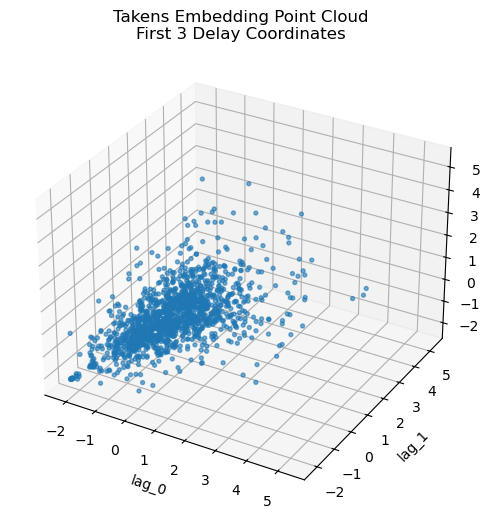

In [16]:
# =========================
# 4.4.5-1 最初の3つの遅延座標による3次元可視化
# =========================

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_takens[:, 0],
    X_takens[:, 1],
    X_takens[:, 2],
    s=8,
    alpha=0.6
)

ax.set_title("Takens Embedding Point Cloud\nFirst 3 Delay Coordinates")
ax.set_xlabel("lag_0")
ax.set_ylabel("lag_1")
ax.set_zlabel("lag_2")
plt.show()

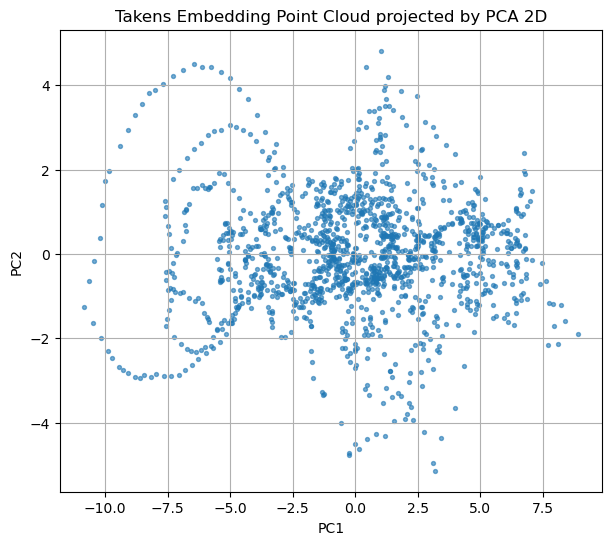

PCA 2D explained variance ratio: [0.46514254 0.06783733]
PCA 2D cumulative explained variance: 0.532979872277276


In [17]:
# =========================
# 4.4.5-2 PCAによる2次元可視化
# =========================

from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2, random_state=0)
X_takens_pca_2d = pca_2d.fit_transform(X_takens)

plt.figure(figsize=(7, 6))
plt.scatter(
    X_takens_pca_2d[:, 0],
    X_takens_pca_2d[:, 1],
    s=8,
    alpha=0.6
)
plt.title("Takens Embedding Point Cloud projected by PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

print("PCA 2D explained variance ratio:", pca_2d.explained_variance_ratio_)
print("PCA 2D cumulative explained variance:", pca_2d.explained_variance_ratio_.sum())

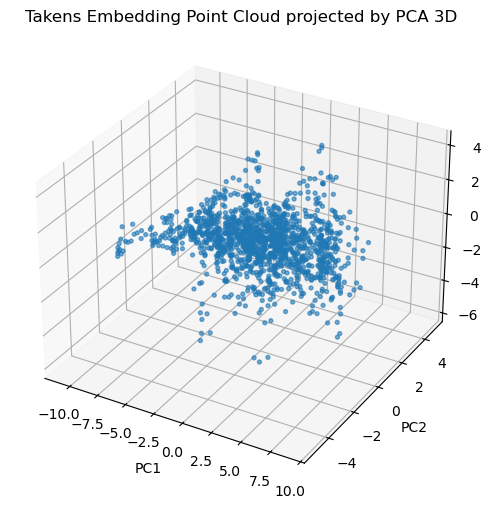

PCA 3D explained variance ratio: [0.46514254 0.06783733 0.04131883]
PCA 3D cumulative explained variance: 0.5742987026073958


In [18]:
# =========================
# 4.4.5-3 PCAによる3次元可視化
# =========================

pca_3d = PCA(n_components=3, random_state=0)
X_takens_pca_3d = pca_3d.fit_transform(X_takens)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_takens_pca_3d[:, 0],
    X_takens_pca_3d[:, 1],
    X_takens_pca_3d[:, 2],
    s=8,
    alpha=0.6
)

ax.set_title("Takens Embedding Point Cloud projected by PCA 3D")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

print("PCA 3D explained variance ratio:", pca_3d.explained_variance_ratio_)
print("PCA 3D cumulative explained variance:", pca_3d.explained_variance_ratio_.sum())

### 4.4.6 Persistent Homology 用の点群サイズ調整

Vietoris-Rips 複体は点数が増えると計算量が急増する。  
そのため、まずは全点ではなく、等間隔サンプリングした点群で Persistent Homology を計算する。

ここでは `max_points_for_ph = 500` とする。重い場合は `300` 程度まで下げる。

In [19]:
# =========================
# 4.4.6 Persistent Homology 用の点群サイズ調整
# =========================

max_points_for_ph = 500

if X_takens.shape[0] > max_points_for_ph:
    sample_positions = np.linspace(
        0,
        X_takens.shape[0] - 1,
        max_points_for_ph,
        dtype=int
    )
    X_takens_ph = X_takens[sample_positions]
    X_takens_ph_index = X_takens_index[sample_positions]
    print(f"点数が多いため、{X_takens.shape[0]} 点から {max_points_for_ph} 点を等間隔サンプリングしました。")
else:
    X_takens_ph = X_takens.copy()
    X_takens_ph_index = X_takens_index.copy()
    print("点数が十分少ないため、全点を Persistent Homology に使用します。")

print("PH用点群の形状:", X_takens_ph.shape)
print("PH用点群の期間:", X_takens_ph_index.min(), "〜", X_takens_ph_index.max())

点数が多いため、1413 点から 500 点を等間隔サンプリングしました。
PH用点群の形状: (500, 30)
PH用点群の期間: 2007-01-14 00:00:00 〜 2010-11-26 00:00:00


### 4.4.7 この段階で作成された主な変数

次の Persistent Homology の計算では、基本的に `X_takens_ph` を入力として使う。

| 変数名 | 意味 |
|---|---|
| `series_for_embedding` | 点群化に使った1変量時系列 |
| `X_takens` | Sliding Window / Takens Embedding で作成した全点群 |
| `X_takens_index` | 各点に対応する日付 |
| `X_takens_df` | 点群を DataFrame 化したもの |
| `X_takens_ph` | Persistent Homology 計算用に点数調整した点群 |
| `X_takens_ph_index` | `X_takens_ph` に対応する日付 |

この段階では、時系列を Persistent Homology に入力可能な点群へ変換できた、という位置づけである。

In [20]:
# =========================
# 4.4.7 最終確認
# =========================

print("4.4 Sliding Window / Takens Embedding による点群化: 完了")
print("使用系列:", series_for_embedding.name)
print("embedding_dim:", embedding_dim)
print("delay:", delay)
print("stride:", stride)
print("全点群 X_takens:", X_takens.shape)
print("PH用点群 X_takens_ph:", X_takens_ph.shape)

4.4 Sliding Window / Takens Embedding による点群化: 完了
使用系列: Global_active_power_scaled
embedding_dim: 30
delay: 1
stride: 1
全点群 X_takens: (1413, 30)
PH用点群 X_takens_ph: (500, 30)


## 5. Persistent Homology の計算

ここでは、4.4で作成した `X_takens_ph` を入力点群として、Vietoris-Rips 複体に基づく Persistent Homology を計算する。

この段階の目的は、次の2つである。

1. Sliding Window / Takens Embedding で作成した点群から persistence diagram を得る
2. 後続の「Persistence Diagram / Barcode の可視化」と「TDA特徴量作成」に使う基礎データを作る

今回は最小構成として、次を計算対象にする。

| 次元 | 意味 | 今回の見るポイント |
|---|---|---|
| H0 | 連結成分 | 点群がどのスケールで1つにまとまるか |
| H1 | ループ | 周期性・回帰的パターンに対応する穴があるか |

H2以上は計算量が重くなりやすいため、まずは扱わない。


### 5.1 使用ライブラリの確認

基本は `giotto-tda` の `VietorisRipsPersistence` を使う。  
環境によって `giotto-tda` が入っていない場合があるため、その場合は `ripser` を使うフォールバックも用意する。

未インストールの場合は、Anaconda Prompt などで次を実行する。

```bash
pip install giotto-tda
```

または、`ripser` を使う場合は次を実行する。

```bash
pip install ripser
```


In [21]:
# =========================
# 5.1 使用ライブラリの確認
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ph_backend = None

try:
    from gtda.homology import VietorisRipsPersistence
    ph_backend = "giotto-tda"
    print("giotto-tda を使用します。")
except ImportError:
    try:
        from ripser import ripser
        ph_backend = "ripser"
        print("giotto-tda が見つからないため、ripser を使用します。")
    except ImportError as e:
        raise ImportError(
            "Persistent Homology の計算には giotto-tda または ripser が必要です。\n"
            "まず次のどちらかを実行してください。\n"
            "pip install giotto-tda\n"
            "または\n"
            "pip install ripser"
        ) from e

print("PH backend:", ph_backend)


giotto-tda が見つからないため、ripser を使用します。
PH backend: ripser


### 5.2 Persistent Homology 計算用点群の確認

Persistent Homology の入力には、4.4.6で作成した `X_takens_ph` を使う。  
これは、計算量を抑えるために `X_takens` から等間隔サンプリングした点群である。


In [22]:
# =========================
# 5.2 Persistent Homology 計算用点群の確認
# =========================

if "X_takens_ph" not in globals():
    raise NameError("X_takens_ph が定義されていません。先に 4.4 の点群化セルを実行してください。")

X_ph = np.asarray(X_takens_ph, dtype=float)

print("PH計算用点群 X_ph の形状:", X_ph.shape)
print("点数:", X_ph.shape[0])
print("埋め込み次元:", X_ph.shape[1])
print("NaN の数:", np.isnan(X_ph).sum())
print("inf の数:", np.isinf(X_ph).sum())

if np.isnan(X_ph).sum() > 0 or np.isinf(X_ph).sum() > 0:
    raise ValueError("X_ph に NaN または inf が含まれています。前処理を確認してください。")


PH計算用点群 X_ph の形状: (500, 30)
点数: 500
埋め込み次元: 30
NaN の数: 0
inf の数: 0


### 5.3 Vietoris-Rips Persistent Homology の計算

ここでは `H0` と `H1` を計算する。

- `H0`: 連結成分の統合過程
- `H1`: ループ構造、つまり周期性・回帰的構造の候補

`H1` に寿命の長い点が出る場合、Sliding Window 点群に比較的はっきりしたループ構造がある可能性を示す。


In [23]:
# =========================
# 5.3 Vietoris-Rips Persistent Homology の計算
# =========================

homology_dimensions = (0, 1)

if ph_backend == "giotto-tda":
    # giotto-tda では、入力を「サンプル数 × 点数 × 次元」の3次元配列にする
    X_ph_input = X_ph[None, :, :]

    vr = VietorisRipsPersistence(
        metric="euclidean",
        homology_dimensions=homology_dimensions,
        n_jobs=-1
    )

    diagrams = vr.fit_transform(X_ph_input)

    # diagrams の形: (サンプル数, birth-death-dim の点数, 3)
    persistence_diagram = diagrams[0]

elif ph_backend == "ripser":
    # ripser では maxdim=1 とすると H0, H1 を計算する
    ripser_result = ripser(X_ph, maxdim=1, coeff=2)
    dgms = ripser_result["dgms"]

    diagram_rows = []
    for dim, dgm in enumerate(dgms):
        for birth, death in dgm:
            diagram_rows.append([birth, death, dim])

    persistence_diagram = np.array(diagram_rows, dtype=float)

else:
    raise ValueError("ph_backend が不正です。")

print("Persistence diagram の形状:", persistence_diagram.shape)
print("列の意味: birth, death, dimension")
print(persistence_diagram[:10])


Persistence diagram の形状: (926, 3)
列の意味: birth, death, dimension
[[0.         1.77692306 0.        ]
 [0.         2.11944604 0.        ]
 [0.         2.13031459 0.        ]
 [0.         2.131603   0.        ]
 [0.         2.14865732 0.        ]
 [0.         2.1523056  0.        ]
 [0.         2.20805025 0.        ]
 [0.         2.2152822  0.        ]
 [0.         2.21967363 0.        ]
 [0.         2.23459697 0.        ]]


### 5.4 Persistence Diagram を DataFrame 化する

後続の可視化・特徴量作成で扱いやすいように、計算結果を DataFrame に変換する。  
各点について、`birth`, `death`, `dimension`, `lifetime` を持たせる。

`death = inf` の点は、最後まで消えなかった特徴を表す。通常、H0には無限寿命の成分が1つ出る。


In [24]:
# =========================
# 5.4 Persistence Diagram を DataFrame 化
# =========================

pd_df = pd.DataFrame(
    persistence_diagram,
    columns=["birth", "death", "dimension"]
)

pd_df["dimension"] = pd_df["dimension"].astype(int)
pd_df["lifetime"] = pd_df["death"] - pd_df["birth"]
pd_df["is_infinite"] = ~np.isfinite(pd_df["death"])

# 有限寿命のみの DataFrame
pd_finite_df = pd_df[np.isfinite(pd_df["death"])].copy()

print("Persistence Diagram 点数:", len(pd_df))
print("有限 death の点数:", len(pd_finite_df))
print("無限 death の点数:", pd_df["is_infinite"].sum())

display(pd_df.head(10))


Persistence Diagram 点数: 926
有限 death の点数: 925
無限 death の点数: 1


,birth,death,dimension,lifetime,is_infinite
0,0.0,1.776923,0,1.776923,False
1,0.0,2.119446,0,2.119446,False
2,0.0,2.130315,0,2.130315,False
3,0.0,2.131603,0,2.131603,False
4,0.0,2.148657,0,2.148657,False
5,0.0,2.152306,0,2.152306,False
6,0.0,2.208050,0,2.208050,False
7,0.0,2.215282,0,2.215282,False
8,0.0,2.219674,0,2.219674,False
9,0.0,2.234597,0,2.234597,False


### 5.5 次元別の Persistent Homology 結果確認

各ホモロジー次元ごとに、点数・最大寿命・平均寿命を確認する。  
特に `H1` の `max_lifetime` は、ループ構造の強さを見るうえで重要な値になる。


In [25]:
# =========================
# 5.5 次元別の Persistent Homology 結果確認
# =========================

ph_summary = (
    pd_finite_df
    .groupby("dimension")
    .agg(
        n_points=("lifetime", "size"),
        max_lifetime=("lifetime", "max"),
        mean_lifetime=("lifetime", "mean"),
        median_lifetime=("lifetime", "median"),
        total_lifetime=("lifetime", "sum")
    )
    .reset_index()
)

print("次元別 Persistence Summary")
display(ph_summary)

# H1 の長寿命特徴を確認
h1_df = pd_finite_df[pd_finite_df["dimension"] == 1].copy()
h1_df = h1_df.sort_values("lifetime", ascending=False)

print("H1 の上位特徴")
display(h1_df.head(10))


次元別 Persistence Summary


,dimension,n_points,max_lifetime,mean_lifetime,median_lifetime,total_lifetime
0,0,499,7.913701,3.482976,3.208776,1738.005166
1,1,426,0.681594,0.143551,0.115056,61.152811


H1 の上位特徴


,birth,death,dimension,lifetime,is_infinite
593,4.100748,4.782342,1,0.681594,False
591,4.112032,4.678203,1,0.566171,False
598,4.036098,4.567873,1,0.531775,False
602,4.010962,4.515448,1,0.504486,False
597,4.038826,4.537926,1,0.499101,False
600,4.025277,4.508579,1,0.483302,False
916,2.603826,3.085511,1,0.481685,False
604,4.001030,4.480778,1,0.479747,False
878,2.739347,3.199208,1,0.459862,False
574,4.256534,4.699034,1,0.442500,False


### 5.6 この段階で作成された主な変数

| 変数名 | 意味 |
|---|---|
| `X_ph` | Persistent Homology 計算に使った点群 |
| `persistence_diagram` | birth, death, dimension を持つ numpy 配列 |
| `pd_df` | persistence diagram を DataFrame 化したもの |
| `pd_finite_df` | death が有限の点だけを抽出した DataFrame |
| `ph_summary` | 次元別の寿命要約 |
| `h1_df` | H1、つまりループ構造だけを抽出した DataFrame |

次の章では、`pd_df` または `persistence_diagram` を使って、Persistence Diagram と Barcode を可視化する。


In [26]:
# =========================
# 5.6 最終確認
# =========================

print("5. Persistent Homology の計算: 完了")
print("使用 backend:", ph_backend)
print("計算対象:", homology_dimensions)
print("入力点群 X_ph:", X_ph.shape)
print("Persistence diagram:", persistence_diagram.shape)

if len(h1_df) > 0:
    print("H1 最大寿命:", h1_df["lifetime"].max())
else:
    print("H1 の有限特徴は検出されませんでした。")


5. Persistent Homology の計算: 完了
使用 backend: ripser
計算対象: (0, 1)
入力点群 X_ph: (500, 30)
Persistence diagram: (926, 3)
H1 最大寿命: 0.6815943717956543



## 6. Persistence Diagram / Barcode の可視化

ここでは、5章で計算した Persistent Homology の結果を可視化する。

この章の目的は、次の2つである。

1. **Persistence Diagram** により、各ホモロジー特徴の `birth` と `death` の関係を確認する
2. **Barcode** により、各特徴がどのスケール範囲で生存しているかを確認する

今回の最小構成では、主に次を見る。

| 可視化 | 見る対象 | 解釈のポイント |
|---|---|---|
| Persistence Diagram | `birth` と `death` の散布図 | 対角線から遠い点ほど寿命が長い |
| Barcode | 各特徴の生存区間 | 横棒が長いほど persistent な特徴 |
| H1上位特徴 | ループ構造 | 周期性・回帰的パターンの候補 |

特に `H1` に長いバーがある場合、Sliding Window 点群にループ構造がある可能性を示す。



### 6.1 可視化用データの準備

5章で作成した `pd_df` と `pd_finite_df` を使う。  
可視化では、基本的に `death` が有限で、かつ `lifetime > 0` の点を対象にする。

`death = inf` の点は、主に H0 の最後まで残る連結成分であるため、Persistence Diagram / Barcode では別途確認する。


In [27]:

# =========================
# 6.1 可視化用データの準備
# =========================

if "pd_df" not in globals():
    raise NameError("pd_df が定義されていません。先に 5. Persistent Homology の計算セルを実行してください。")

if "pd_finite_df" not in globals():
    pd_finite_df = pd_df[np.isfinite(pd_df["death"])].copy()

# 可視化対象: finite death かつ lifetime > 0
pd_plot_df = pd_finite_df[pd_finite_df["lifetime"] > 0].copy()

print("Persistence Diagram 全点数:", len(pd_df))
print("可視化対象点数 finite & lifetime > 0:", len(pd_plot_df))
print("無限 death の点数:", (~np.isfinite(pd_df["death"])).sum())

print("dimension ごとの可視化対象点数")
display(pd_plot_df["dimension"].value_counts().sort_index().rename("n_points"))


Persistence Diagram 全点数: 926
可視化対象点数 finite & lifetime > 0: 925
無限 death の点数: 1
dimension ごとの可視化対象点数


dimension
0    499
1    426
Name: n_points, dtype: int64


### 6.2 Persistence Diagram の可視化

Persistence Diagram では、各点が1つのホモロジー特徴を表す。

- 横軸: `birth`
- 縦軸: `death`
- 対角線 `birth = death`: 寿命0の基準線
- 対角線から遠い点: 寿命が長い特徴

H1の点が対角線から大きく離れていれば、ループ構造が比較的強く出ている可能性がある。


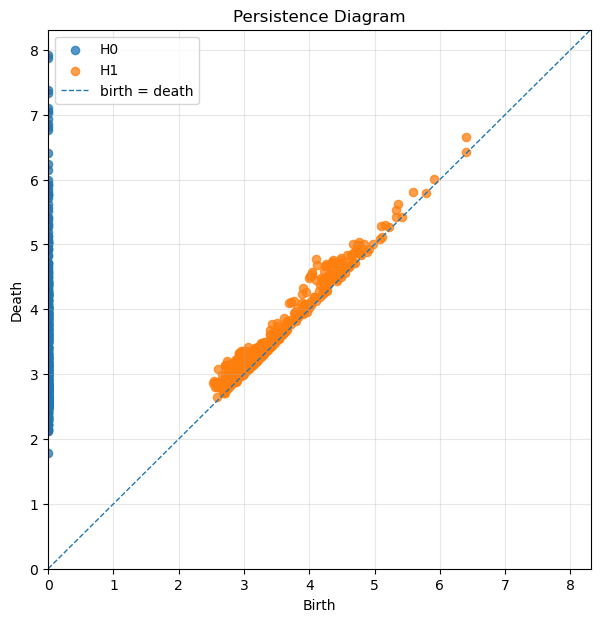

In [28]:

# =========================
# 6.2 Persistence Diagram の可視化
# =========================

if len(pd_plot_df) == 0:
    print("可視化できる有限寿命の点がありません。")
else:
    max_birth = pd_plot_df["birth"].max()
    max_death = pd_plot_df["death"].max()
    axis_max = max(max_birth, max_death)
    axis_max = axis_max * 1.05 if axis_max > 0 else 1.0

    plt.figure(figsize=(7, 7))

    for dim in sorted(pd_plot_df["dimension"].unique()):
        dim_df = pd_plot_df[pd_plot_df["dimension"] == dim]
        plt.scatter(
            dim_df["birth"],
            dim_df["death"],
            s=35,
            alpha=0.75,
            label=f"H{dim}"
        )

    # 対角線 birth = death
    plt.plot([0, axis_max], [0, axis_max], linestyle="--", linewidth=1, label="birth = death")

    plt.xlabel("Birth")
    plt.ylabel("Death")
    plt.title("Persistence Diagram")
    plt.xlim(0, axis_max)
    plt.ylim(0, axis_max)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()



### 6.3 次元別 Persistence Diagram の可視化

H0とH1を分けて見る。  
H0は連結成分の統合過程、H1はループ構造を表す。

今回の目的では、特に **H1 の点が対角線からどれだけ離れているか** を確認する。


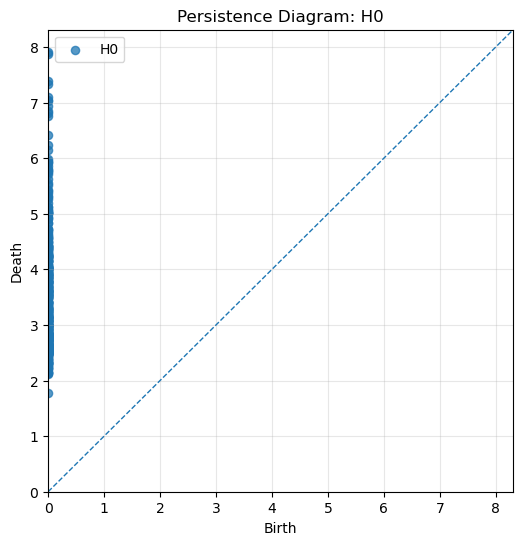

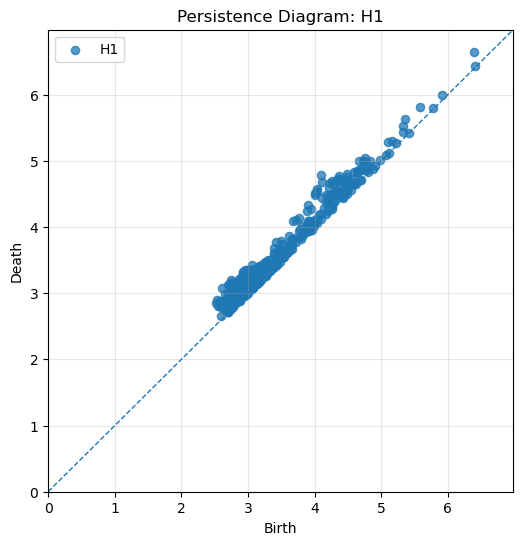

In [29]:

# =========================
# 6.3 次元別 Persistence Diagram の可視化
# =========================

for dim in sorted(pd_plot_df["dimension"].unique()):
    dim_df = pd_plot_df[pd_plot_df["dimension"] == dim].copy()

    if len(dim_df) == 0:
        continue

    axis_max = max(dim_df["birth"].max(), dim_df["death"].max())
    axis_max = axis_max * 1.05 if axis_max > 0 else 1.0

    plt.figure(figsize=(6, 6))
    plt.scatter(
        dim_df["birth"],
        dim_df["death"],
        s=35,
        alpha=0.75,
        label=f"H{dim}"
    )
    plt.plot([0, axis_max], [0, axis_max], linestyle="--", linewidth=1)

    plt.xlabel("Birth")
    plt.ylabel("Death")
    plt.title(f"Persistence Diagram: H{dim}")
    plt.xlim(0, axis_max)
    plt.ylim(0, axis_max)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()



### 6.4 Barcode の可視化

Barcode では、各ホモロジー特徴を横棒で表す。

- 横棒の左端: `birth`
- 横棒の右端: `death`
- 横棒の長さ: `lifetime`

横棒が長いほど、ノイズではなく構造的な特徴である可能性が高い。  
ただし、これは「断定」ではなく、点群化のパラメータやサンプリング数にも依存する。


In [30]:

# =========================
# 6.4 Barcode の可視化関数
# =========================

def plot_barcode(
    df,
    dim=None,
    top_n=80,
    title=None,
    sort_by_lifetime=True
):
    """
    Persistence Barcode を描画する関数。

    Parameters
    ----------
    df : pandas.DataFrame
        birth, death, dimension, lifetime を含む DataFrame。
    dim : int or None
        可視化するホモロジー次元。None の場合は全次元。
    top_n : int
        表示する上位バー数。点数が多い場合、寿命の長いものから表示する。
    title : str or None
        グラフタイトル。
    sort_by_lifetime : bool
        True の場合、lifetime の長い順に並べる。
    """
    plot_df = df.copy()
    plot_df = plot_df[np.isfinite(plot_df["death"])].copy()
    plot_df = plot_df[plot_df["lifetime"] > 0].copy()

    if dim is not None:
        plot_df = plot_df[plot_df["dimension"] == dim].copy()

    if len(plot_df) == 0:
        print("表示できるバーがありません。")
        return

    if sort_by_lifetime:
        plot_df = plot_df.sort_values("lifetime", ascending=False)
    else:
        plot_df = plot_df.sort_values(["dimension", "birth", "death"])

    plot_df = plot_df.head(top_n).copy()
    plot_df = plot_df.iloc[::-1].reset_index(drop=True)

    plt.figure(figsize=(9, max(4, 0.12 * len(plot_df))))

    for i, row in plot_df.iterrows():
        plt.hlines(
            y=i,
            xmin=row["birth"],
            xmax=row["death"],
            linewidth=2
        )

    plt.xlabel("Filtration value")
    plt.ylabel("Feature index")
    if title is None:
        title = "Persistence Barcode" if dim is None else f"Persistence Barcode: H{dim}"
    plt.title(title)
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()


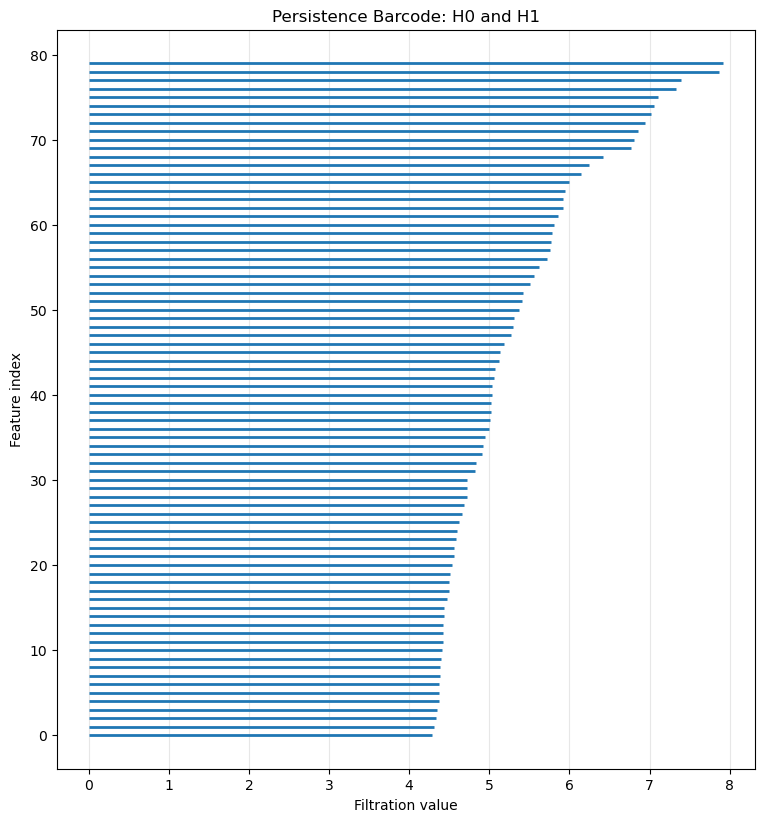

In [31]:

# =========================
# 6.4 Barcode の可視化: 全次元
# =========================

plot_barcode(
    pd_df,
    dim=None,
    top_n=80,
    title="Persistence Barcode: H0 and H1"
)



### 6.5 H0 / H1 別 Barcode の可視化

H0とH1を分けて Barcode を確認する。

- H0: 点群の連結成分がどのスケールで統合されるか
- H1: ループ構造がどのスケール範囲で残るか

今回のTDA特徴量作成では、H1の長寿命バーが重要な候補になる。


H0 の点数: 500
H0 の有限寿命点数: 499
H0 の無限寿命点数: 1


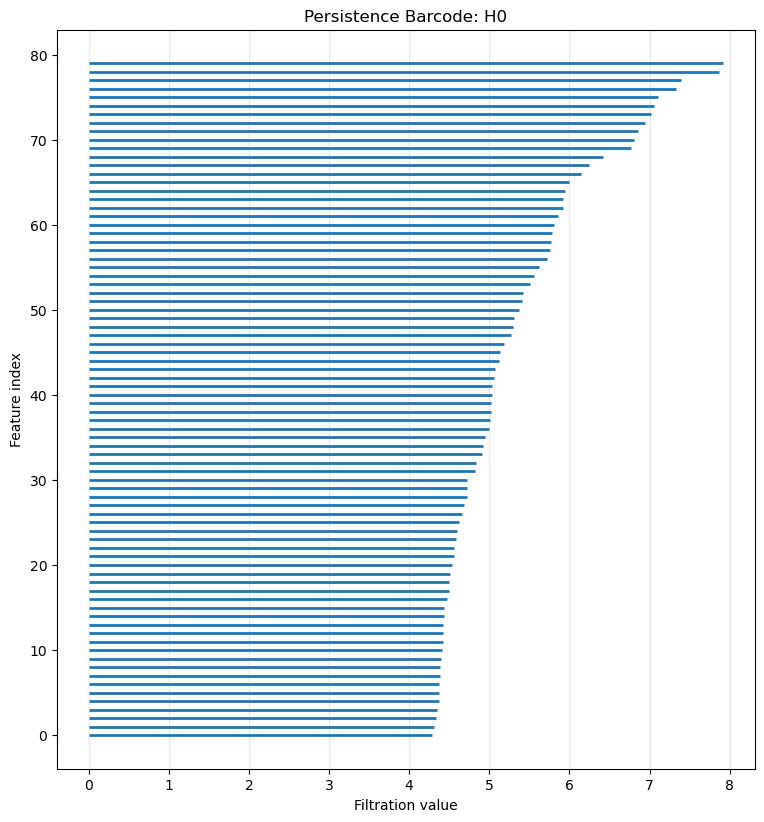

H1 の点数: 426
H1 の有限寿命点数: 426
H1 の無限寿命点数: 0


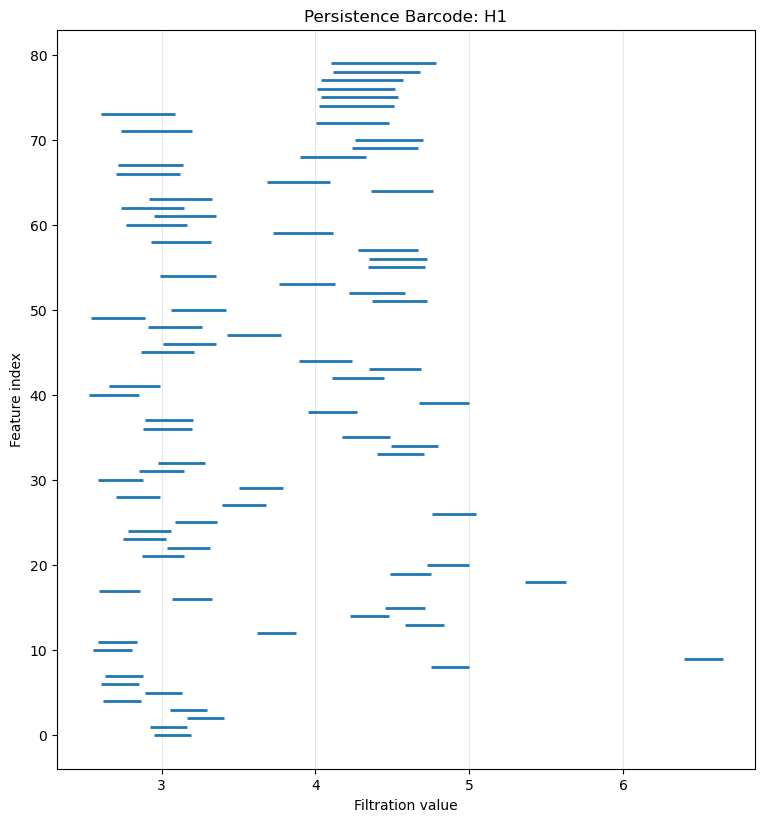

In [32]:

# =========================
# 6.5 H0 / H1 別 Barcode の可視化
# =========================

for dim in [0, 1]:
    dim_df = pd_df[pd_df["dimension"] == dim]

    print(f"H{dim} の点数:", len(dim_df))
    print(f"H{dim} の有限寿命点数:", np.isfinite(dim_df["death"]).sum())
    print(f"H{dim} の無限寿命点数:", (~np.isfinite(dim_df["death"])).sum())

    plot_barcode(
        pd_df,
        dim=dim,
        top_n=80,
        title=f"Persistence Barcode: H{dim}"
    )



### 6.6 H1 の長寿命特徴の確認

H1のうち、`lifetime` が大きい特徴を表で確認する。  
これは、後続のTDA特徴量作成で使う候補になる。

代表的な特徴量候補は次である。

- H1最大寿命
- H1寿命上位k個
- H1寿命の合計
- H1寿命の平均
- H1点数


H1 の長寿命特徴 Top 10


,birth,death,dimension,lifetime,is_infinite
593,4.100748,4.782342,1,0.681594,False
591,4.112032,4.678203,1,0.566171,False
598,4.036098,4.567873,1,0.531775,False
602,4.010962,4.515448,1,0.504486,False
597,4.038826,4.537926,1,0.499101,False
600,4.025277,4.508579,1,0.483302,False
916,2.603826,3.085511,1,0.481685,False
604,4.001030,4.480778,1,0.479747,False
878,2.739347,3.199208,1,0.459862,False
574,4.256534,4.699034,1,0.442500,False


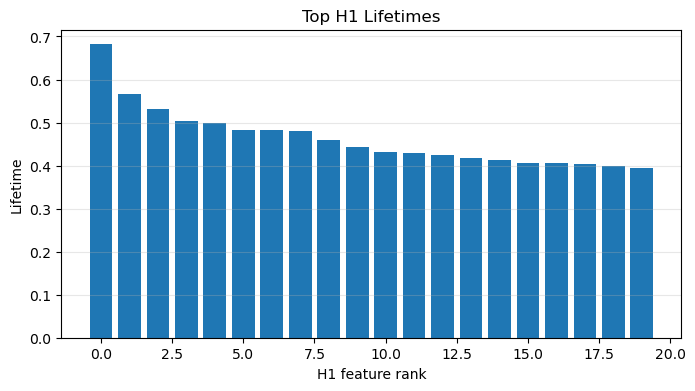

In [33]:

# =========================
# 6.6 H1 の長寿命特徴の確認
# =========================

h1_viz_df = pd_plot_df[pd_plot_df["dimension"] == 1].copy()
h1_viz_df = h1_viz_df.sort_values("lifetime", ascending=False)

if len(h1_viz_df) == 0:
    print("H1 の有限寿命特徴は検出されませんでした。")
else:
    print("H1 の長寿命特徴 Top 10")
    display(h1_viz_df.head(10))

    plt.figure(figsize=(8, 4))
    plt.bar(
        range(min(20, len(h1_viz_df))),
        h1_viz_df["lifetime"].head(20)
    )
    plt.xlabel("H1 feature rank")
    plt.ylabel("Lifetime")
    plt.title("Top H1 Lifetimes")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()



### 6.7 可視化結果の確認メモ

以下の観点で結果を読む。

1. **H1の点が対角線から離れているか**  
   - 離れている点があれば、ループ構造の候補と見る。

2. **H1のBarcodeに長い横棒があるか**  
   - 長いバーがあれば、時系列の回帰的・周期的な構造が点群に反映されている可能性がある。

3. **H1がほとんど対角線付近に集中しているか**  
   - その場合、今回の点群化パラメータでは明確なループ構造は弱い可能性がある。

4. **解釈は点群化パラメータに依存する**  
   - `embedding_dim`, `delay`, `stride`, `X_takens_ph` の点数を変えると、Persistence Diagram / Barcode も変わる。

この段階では、可視化結果をもとに「TDA特徴量として使えそうか」を判断する準備ができた、という位置づけである。


In [34]:

# =========================
# 6.8 最終確認
# =========================

print("6. Persistence Diagram / Barcode の可視化: 完了")
print("可視化対象 DataFrame: pd_plot_df")
print("可視化対象点数:", len(pd_plot_df))

if "h1_viz_df" in globals() and len(h1_viz_df) > 0:
    print("H1 最大寿命:", h1_viz_df["lifetime"].max())
    print("H1 寿命上位5個:")
    display(h1_viz_df[["birth", "death", "lifetime"]].head(5))
else:
    print("H1 の有限寿命特徴は検出されませんでした。")


6. Persistence Diagram / Barcode の可視化: 完了
可視化対象 DataFrame: pd_plot_df
可視化対象点数: 925
H1 最大寿命: 0.6815943717956543
H1 寿命上位5個:


,birth,death,lifetime
593,4.100748,4.782342,0.681594
591,4.112032,4.678203,0.566171
598,4.036098,4.567873,0.531775
602,4.010962,4.515448,0.504486
597,4.038826,4.537926,0.499101



## 7. TDA特徴量の作成

ここでは、Persistent Homology の計算結果 `pd_df` から、機械学習モデルや比較用の表に使える **TDA特徴量** を作成する。

今回の最小構成では、以下を特徴量として作る。

- H0特徴量: 連結成分の統合パターン
- H1特徴量: ループ構造の強さ
- lifetime 統計量: 最大値、平均、中央値、合計、標準偏差
- 長寿命バーの個数
- persistence entropy
- H1上位バーの lifetime

今回の目的では、特に **H1の寿命が長いかどうか** を重視する。H1は Takens Embedding で得られた点群のループ構造を表すため、周期性・回帰性の候補として解釈できる。



### 7.1 TDA特徴量作成用データの準備

5章・6章で作成した `pd_df` を使う。

`death = inf` の点は、通常 H0 の最後まで残る連結成分であり、寿命統計量にそのまま入れると値が無限大になる。  
そのため、特徴量作成では基本的に **finite death の点のみ** を使う。


In [35]:

# =========================
# 7.1 TDA特徴量作成用データの準備
# =========================

if "pd_df" not in globals():
    raise NameError("pd_df が定義されていません。先に 5. Persistent Homology の計算セルを実行してください。")

# finite death のみを特徴量作成対象にする
pd_feature_df = pd_df[np.isfinite(pd_df["death"])].copy()
pd_feature_df = pd_feature_df[pd_feature_df["lifetime"] > 0].copy()

print("TDA特徴量作成対象の点数:", len(pd_feature_df))
print("dimension ごとの点数")
display(pd_feature_df["dimension"].value_counts().sort_index().rename("n_points"))

# H0, H1 を分ける
h0_feature_df = pd_feature_df[pd_feature_df["dimension"] == 0].copy()
h1_feature_df = pd_feature_df[pd_feature_df["dimension"] == 1].copy()

print("H0 finite 点数:", len(h0_feature_df))
print("H1 finite 点数:", len(h1_feature_df))


TDA特徴量作成対象の点数: 925
dimension ごとの点数


dimension
0    499
1    426
Name: n_points, dtype: int64

H0 finite 点数: 499
H1 finite 点数: 426



### 7.2 lifetime 統計量を作る関数

各ホモロジー次元ごとに、lifetime の要約統計量を作る。

代表的には以下を見る。

| 特徴量 | 意味 |
|---|---|
| `n_points` | persistence diagram 上の点数 |
| `lifetime_max` | 最も長く残った特徴 |
| `lifetime_sum` | 寿命の総量 |
| `lifetime_mean` | 平均的な寿命 |
| `lifetime_median` | 寿命の中央値 |
| `lifetime_std` | 寿命のばらつき |
| `n_long_lifetime` | 長寿命特徴の個数 |
| `persistence_entropy` | 寿命分布の偏り |


In [36]:

# =========================
# 7.2 lifetime 統計量を作る関数
# =========================

def persistence_entropy(lifetimes, eps=1e-12):
    """
    lifetime の分布から persistence entropy を計算する。

    lifetime が一部の特徴に集中している場合、entropy は小さくなりやすい。
    lifetime が多くの特徴に分散している場合、entropy は大きくなりやすい。
    """
    lifetimes = np.asarray(lifetimes, dtype=float)
    lifetimes = lifetimes[np.isfinite(lifetimes)]
    lifetimes = lifetimes[lifetimes > 0]

    total = lifetimes.sum()
    if len(lifetimes) == 0 or total <= 0:
        return 0.0

    p = lifetimes / total
    return float(-np.sum(p * np.log(p + eps)))


def lifetime_summary_features(df, dim, long_quantile=0.90):
    """
    指定した homology dimension の persistence diagram から特徴量を作成する。
    """
    dim_df = df[df["dimension"] == dim].copy()
    lifetimes = dim_df["lifetime"].to_numpy(dtype=float)
    lifetimes = lifetimes[np.isfinite(lifetimes)]
    lifetimes = lifetimes[lifetimes > 0]

    prefix = f"H{dim}"

    if len(lifetimes) == 0:
        return {
            f"{prefix}_n_points": 0,
            f"{prefix}_lifetime_max": 0.0,
            f"{prefix}_lifetime_sum": 0.0,
            f"{prefix}_lifetime_mean": 0.0,
            f"{prefix}_lifetime_median": 0.0,
            f"{prefix}_lifetime_std": 0.0,
            f"{prefix}_lifetime_q25": 0.0,
            f"{prefix}_lifetime_q75": 0.0,
            f"{prefix}_n_long_lifetime": 0,
            f"{prefix}_persistence_entropy": 0.0,
        }

    threshold = np.quantile(lifetimes, long_quantile)

    return {
        f"{prefix}_n_points": int(len(lifetimes)),
        f"{prefix}_lifetime_max": float(np.max(lifetimes)),
        f"{prefix}_lifetime_sum": float(np.sum(lifetimes)),
        f"{prefix}_lifetime_mean": float(np.mean(lifetimes)),
        f"{prefix}_lifetime_median": float(np.median(lifetimes)),
        f"{prefix}_lifetime_std": float(np.std(lifetimes, ddof=0)),
        f"{prefix}_lifetime_q25": float(np.quantile(lifetimes, 0.25)),
        f"{prefix}_lifetime_q75": float(np.quantile(lifetimes, 0.75)),
        f"{prefix}_n_long_lifetime": int(np.sum(lifetimes >= threshold)),
        f"{prefix}_persistence_entropy": persistence_entropy(lifetimes),
    }

print("lifetime_summary_features を定義しました。")


lifetime_summary_features を定義しました。



### 7.3 H0・H1のTDA特徴量を作成する

今回は `max_homology_dimension = 1` で計算しているため、H0とH1を対象にする。

- H0: 点群の連結成分がどのように統合されるか
- H1: ループ構造がどの程度強く残るか

時系列の回帰的・周期的構造を見る目的では、H1特徴量を主に確認する。


In [37]:

# =========================
# 7.3 H0・H1のTDA特徴量を作成
# =========================

tda_features = {}

# H0, H1 の lifetime 統計量
for dim in [0, 1]:
    tda_features.update(lifetime_summary_features(pd_feature_df, dim=dim, long_quantile=0.90))

# 点群そのものの情報も特徴量・メタ情報として保存
if "X_ph" in globals():
    tda_features["point_cloud_n_points"] = int(X_ph.shape[0])
    tda_features["point_cloud_embedding_dim"] = int(X_ph.shape[1])
else:
    tda_features["point_cloud_n_points"] = np.nan
    tda_features["point_cloud_embedding_dim"] = np.nan

# Takens Embedding のパラメータも保存
for name in ["embedding_dim", "delay", "stride", "n_ph_points"]:
    if name in globals():
        value = globals()[name]
        if isinstance(value, (int, np.integer)):
            tda_features[name] = int(value)
        elif isinstance(value, (float, np.floating)):
            tda_features[name] = float(value)
        else:
            tda_features[name] = value

# 1行の特徴量テーブルにする
tda_features_df = pd.DataFrame([tda_features])

print("TDA特徴量の列数:", tda_features_df.shape[1])
display(tda_features_df.T.rename(columns={0: "value"}))


TDA特徴量の列数: 25


,value
H0_n_points,499.000000
H0_lifetime_max,7.913701
H0_lifetime_sum,1738.005166
H0_lifetime_mean,3.482976
H0_lifetime_median,3.208776
H0_lifetime_std,1.022751
H0_lifetime_q25,2.726513
H0_lifetime_q75,3.979224
H0_n_long_lifetime,50.000000
H0_persistence_entropy,6.173410



### 7.4 H1上位バーの特徴量を追加する

H1の lifetime 上位 `k` 個を、個別の特徴量として追加する。

これは、単に最大寿命だけを見るよりも、複数のループ候補があるかを確認しやすくするためである。


In [38]:

# =========================
# 7.4 H1上位バーの特徴量を追加
# =========================

TOP_K_H1 = 5

h1_lifetimes_sorted = (
    h1_feature_df["lifetime"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values(ascending=False)
    .to_numpy(dtype=float)
)

for k in range(TOP_K_H1):
    col = f"H1_lifetime_top{k+1}"
    if k < len(h1_lifetimes_sorted):
        tda_features_df[col] = float(h1_lifetimes_sorted[k])
    else:
        tda_features_df[col] = 0.0

# 上位バー比率: 1位がH1寿命合計に占める割合
h1_sum = float(tda_features_df.loc[0, "H1_lifetime_sum"])
h1_max = float(tda_features_df.loc[0, "H1_lifetime_max"])
tda_features_df["H1_max_to_sum_ratio"] = h1_max / h1_sum if h1_sum > 0 else 0.0

print("H1上位バー特徴量を追加しました。")
display(tda_features_df[[c for c in tda_features_df.columns if c.startswith("H1_")]].T.rename(columns={0: "value"}))


H1上位バー特徴量を追加しました。


,value
H1_n_points,426.000000
H1_lifetime_max,0.681594
H1_lifetime_sum,61.152811
H1_lifetime_mean,0.143551
H1_lifetime_median,0.115056
H1_lifetime_std,0.120248
H1_lifetime_q25,0.048612
H1_lifetime_q75,0.207230
H1_n_long_lifetime,43.000000
H1_persistence_entropy,5.712514



### 7.5 TDA特徴量の保存

作成した `tda_features_df` を CSV として保存する。

後続で通常特徴量モデルと比較する場合、この1行の特徴量を以下のように使う。

- まずはこの時系列全体のTDA特徴量として解釈する
- Rolling Window を導入する場合は、各時点・各区間ごとに同じ特徴量を作る
- 通常特徴量と結合する場合は、時点をそろえて結合する

今回は最小構成なので、まずは **時系列全体から1つのTDA特徴量セットを作る** ところまで行う。


In [39]:

# =========================
# 7.5 TDA特徴量の保存
# =========================

TDA_FEATURES_CSV = "tda_features_global.csv"
tda_features_df.to_csv(TDA_FEATURES_CSV, index=False, encoding="utf-8-sig")

print("保存完了:", TDA_FEATURES_CSV)
print("TDA特徴量 DataFrame 名: tda_features_df")
print("shape:", tda_features_df.shape)


保存完了: tda_features_global.csv
TDA特徴量 DataFrame 名: tda_features_df
shape: (1, 31)



### 7.6 TDA特徴量の確認

ここでは、H1特徴量を中心に確認する。

解釈の基本方針は次の通り。

- `H1_lifetime_max` が大きいほど、点群に長く残るループ構造がある可能性が高い
- `H1_lifetime_sum` が大きいほど、H1構造全体が強い可能性がある
- `H1_n_points` が多すぎて寿命が短い場合、ノイズ的な小ループが多い可能性がある
- `H1_max_to_sum_ratio` が高い場合、少数の代表的なループに寿命が集中している可能性がある

ただし、これらは点群化パラメータに依存するため、断定ではなく **今回の設定におけるTDA特徴量** として読む。


In [40]:

# =========================
# 7.6 TDA特徴量の確認
# =========================

important_tda_cols = [
    "H1_n_points",
    "H1_lifetime_max",
    "H1_lifetime_sum",
    "H1_lifetime_mean",
    "H1_lifetime_median",
    "H1_persistence_entropy",
    "H1_lifetime_top1",
    "H1_lifetime_top2",
    "H1_lifetime_top3",
    "H1_max_to_sum_ratio",
]

existing_cols = [c for c in important_tda_cols if c in tda_features_df.columns]

display(tda_features_df[existing_cols].T.rename(columns={0: "value"}))

h1_max_value = float(tda_features_df.loc[0, "H1_lifetime_max"])
h1_n_points = int(tda_features_df.loc[0, "H1_n_points"])

print("H1の点数:", h1_n_points)
print("H1最大寿命:", h1_max_value)

if h1_n_points == 0:
    print("H1特徴は検出されていません。今回の点群化設定では明確なループ構造は確認しにくいです。")
elif h1_max_value > 0:
    print("H1特徴が検出されています。次の段階では、この特徴が通常特徴量モデルの改善に寄与するかを確認します。")
else:
    print("H1特徴はありますが、寿命がほぼ0です。点群化パラメータの再検討が必要です。")


,value
H1_n_points,426.000000
H1_lifetime_max,0.681594
H1_lifetime_sum,61.152811
H1_lifetime_mean,0.143551
H1_lifetime_median,0.115056
H1_persistence_entropy,5.712514
H1_lifetime_top1,0.681594
H1_lifetime_top2,0.566171
H1_lifetime_top3,0.531775
H1_max_to_sum_ratio,0.011146


H1の点数: 426
H1最大寿命: 0.6815943717956543
H1特徴が検出されています。次の段階では、この特徴が通常特徴量モデルの改善に寄与するかを確認します。



### 7.7 この段階で作成された主な変数

| 変数名 | 意味 |
|---|---|
| `pd_feature_df` | TDA特徴量作成に使った persistence diagram の有限点 |
| `h0_feature_df` | H0 の有限点 |
| `h1_feature_df` | H1 の有限点 |
| `tda_features_df` | 作成したTDA特徴量テーブル |
| `tda_features_global.csv` | 保存したTDA特徴量CSV |

次は **8. TDA特徴量の考察** に進む。  
その後、通常特徴量と結合してモデル比較する場合は、Rolling Window によるTDA特徴量作成が必要になる。


In [41]:

# =========================
# 7.8 最終確認
# =========================

print("7. TDA特徴量の作成: 完了")
print("作成した特徴量テーブル: tda_features_df")
print("保存ファイル:", TDA_FEATURES_CSV)
print("shape:", tda_features_df.shape)


7. TDA特徴量の作成: 完了
作成した特徴量テーブル: tda_features_df
保存ファイル: tda_features_global.csv
shape: (1, 31)


## 8. TDA特徴量の考察

ここでは、7章で作成した `tda_features_df` を使って、TDA特徴量を**事実ベース**で整理する。

この段階では、TDA特徴量をまだ予測モデルへ組み込んでいない。  
そのため、ここで述べるのは次の範囲に限定する。

- 作成されたTDA特徴量の値
- H0 / H1 の lifetime 分布から読み取れること
- Sliding Window / Takens Embedding の設定
- 現時点で言えること・まだ言えないこと

特に、`H1_lifetime_max` や `H1_lifetime_topk` は、点群に含まれるループ構造の候補を見るための特徴量である。  
ただし、これらの値だけで「予測に有効」とは断定しない。予測性能への寄与は、後続のモデル比較で確認する。


In [42]:

# =========================
# 8.1 考察用TDA特徴量の読み込み・確認
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 7章の tda_features_df が存在すればそれを使う。
# 存在しない場合は、保存済みCSVから読み込む。
if "tda_features_df" not in globals():
    TDA_FEATURES_CSV = "tda_features_global.csv"
    tda_features_df = pd.read_csv(TDA_FEATURES_CSV)

print("TDA特徴量テーブル shape:", tda_features_df.shape)
display(tda_features_df.T.rename(columns={0: "value"}))


TDA特徴量テーブル shape: (1, 31)


,value
H0_n_points,499.000000
H0_lifetime_max,7.913701
H0_lifetime_sum,1738.005166
H0_lifetime_mean,3.482976
H0_lifetime_median,3.208776
H0_lifetime_std,1.022751
H0_lifetime_q25,2.726513
H0_lifetime_q75,3.979224
H0_n_long_lifetime,50.000000
H0_persistence_entropy,6.173410


### 8.2 H0 / H1 特徴量の要約

H0は連結成分の統合過程、H1はループ構造の候補を表す。  
ここでは、各次元について lifetime の代表値を表にまとめる。


In [43]:

# =========================
# 8.2 H0 / H1 特徴量の要約表
# =========================

def get_feature_value(df, col, default=np.nan):
    if col in df.columns:
        return df.loc[0, col]
    return default

summary_rows = []

for dim in [0, 1]:
    prefix = f"H{dim}"
    summary_rows.append({
        "homology_dim": prefix,
        "n_points": get_feature_value(tda_features_df, f"{prefix}_n_points"),
        "lifetime_max": get_feature_value(tda_features_df, f"{prefix}_lifetime_max"),
        "lifetime_sum": get_feature_value(tda_features_df, f"{prefix}_lifetime_sum"),
        "lifetime_mean": get_feature_value(tda_features_df, f"{prefix}_lifetime_mean"),
        "lifetime_median": get_feature_value(tda_features_df, f"{prefix}_lifetime_median"),
        "lifetime_std": get_feature_value(tda_features_df, f"{prefix}_lifetime_std"),
        "lifetime_q25": get_feature_value(tda_features_df, f"{prefix}_lifetime_q25"),
        "lifetime_q75": get_feature_value(tda_features_df, f"{prefix}_lifetime_q75"),
        "n_long_lifetime_top10pct": get_feature_value(tda_features_df, f"{prefix}_n_long_lifetime"),
        "persistence_entropy": get_feature_value(tda_features_df, f"{prefix}_persistence_entropy"),
    })

tda_summary_df = pd.DataFrame(summary_rows)

display(tda_summary_df)


,homology_dim,n_points,lifetime_max,lifetime_sum,lifetime_mean,lifetime_median,lifetime_std,lifetime_q25,lifetime_q75,n_long_lifetime_top10pct,persistence_entropy
0,H0,499,7.913701,1738.005166,3.482976,3.208776,1.022751,2.726513,3.979224,50,6.173410
1,H1,426,0.681594,61.152811,0.143551,0.115056,0.120248,0.048612,0.207230,43,5.712514


### 8.3 H0 / H1 lifetime 統計量の可視化

数値だけでは比較しにくいため、H0とH1の lifetime 統計量を棒グラフで確認する。  
H1の値は、ループ構造の候補の強さを見るうえで特に重要である。


,lifetime_max,lifetime_mean,lifetime_median,lifetime_q75
homology_dim,,,,
H0,7.913701,3.482976,3.208776,3.979224
H1,0.681594,0.143551,0.115056,0.207230


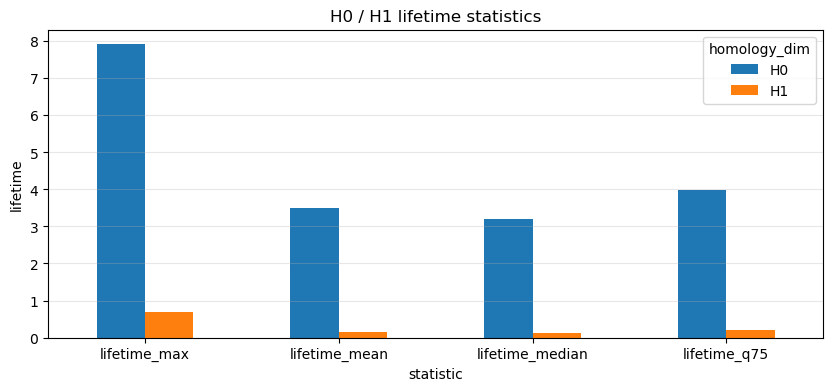

In [44]:

# =========================
# 8.3 H0 / H1 lifetime 統計量の可視化
# =========================

plot_cols = [
    "lifetime_max",
    "lifetime_mean",
    "lifetime_median",
    "lifetime_q75",
]

plot_df = tda_summary_df.set_index("homology_dim")[plot_cols]

display(plot_df)

plot_df.T.plot(kind="bar", figsize=(10, 4))
plt.title("H0 / H1 lifetime statistics")
plt.xlabel("statistic")
plt.ylabel("lifetime")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()


### 8.4 H1 上位 lifetime の確認

H1の lifetime 上位値を確認する。  
上位の lifetime が極端に大きい場合、特定のループ構造が相対的に強い可能性がある。  
一方、上位値が近い場合、単一の強いループというより、複数のループ候補が近い強さで存在している可能性がある。


,feature,value
0,H1_lifetime_top1,0.681594
1,H1_lifetime_top2,0.566171
2,H1_lifetime_top3,0.531775
3,H1_lifetime_top4,0.504486
4,H1_lifetime_top5,0.499101


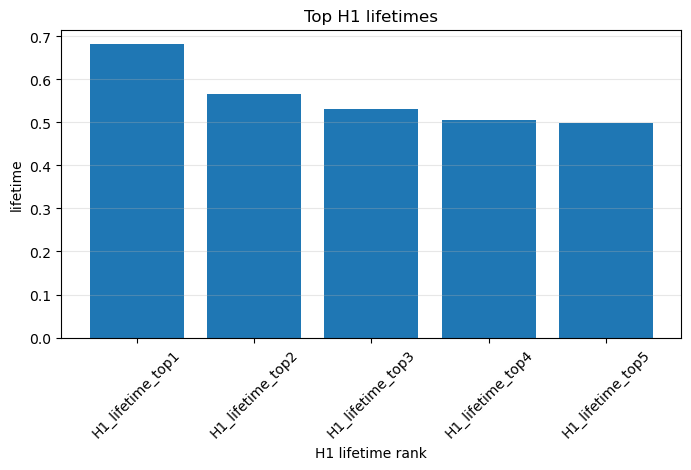

H1_max_to_sum_ratio: 0.011145757042813552


In [45]:

# =========================
# 8.4 H1 上位 lifetime の確認
# =========================

h1_top_cols = [
    col for col in tda_features_df.columns
    if col.startswith("H1_lifetime_top")
]

h1_top_df = (
    tda_features_df[h1_top_cols]
    .T
    .reset_index()
    .rename(columns={"index": "feature", 0: "value"})
)

# top1, top2, ... の順に並べる
h1_top_df["rank"] = h1_top_df["feature"].str.extract(r"top(\d+)").astype(int)
h1_top_df = h1_top_df.sort_values("rank").drop(columns="rank")

display(h1_top_df)

plt.figure(figsize=(8, 4))
plt.bar(h1_top_df["feature"], h1_top_df["value"])
plt.title("Top H1 lifetimes")
plt.xlabel("H1 lifetime rank")
plt.ylabel("lifetime")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

# 参考: H1最大寿命がH1寿命合計に占める割合
h1_ratio = float(get_feature_value(tda_features_df, "H1_max_to_sum_ratio", np.nan))
print("H1_max_to_sum_ratio:", h1_ratio)


### 8.5 事実ベースの考察を自動生成する

ここでは、実際の数値に基づいて考察文を出力する。  
文章は、断定を避けて「この特徴量から言える範囲」に限定する。


In [46]:

# =========================
# 8.5 事実ベースの考察文を自動生成
# =========================

def fmt_float(x, digits=4):
    if pd.isna(x):
        return "NaN"
    return f"{float(x):.{digits}f}"


h0_n = int(get_feature_value(tda_features_df, "H0_n_points", 0))
h1_n = int(get_feature_value(tda_features_df, "H1_n_points", 0))

h0_max = float(get_feature_value(tda_features_df, "H0_lifetime_max", 0))
h1_max = float(get_feature_value(tda_features_df, "H1_lifetime_max", 0))
h1_sum = float(get_feature_value(tda_features_df, "H1_lifetime_sum", 0))
h1_mean = float(get_feature_value(tda_features_df, "H1_lifetime_mean", 0))
h1_median = float(get_feature_value(tda_features_df, "H1_lifetime_median", 0))
h1_q75 = float(get_feature_value(tda_features_df, "H1_lifetime_q75", 0))
h1_entropy = float(get_feature_value(tda_features_df, "H1_persistence_entropy", 0))
h1_ratio = float(get_feature_value(tda_features_df, "H1_max_to_sum_ratio", 0))

pc_n = int(get_feature_value(tda_features_df, "point_cloud_n_points", 0))
emb_dim = int(get_feature_value(tda_features_df, "embedding_dim", get_feature_value(tda_features_df, "point_cloud_embedding_dim", 0)))
delay_value = int(get_feature_value(tda_features_df, "delay", 0))
stride_value = int(get_feature_value(tda_features_df, "stride", 0))

h1_top_values = []
for col in h1_top_cols:
    val = float(tda_features_df.loc[0, col])
    h1_top_values.append((col, val))

h1_top_values = sorted(
    h1_top_values,
    key=lambda x: int(x[0].split("top")[-1])
)

print("【TDA特徴量の事実ベース考察】")
print()
print("1. 点群化の設定")
print(f"- Persistent Homology の計算に使った点群数は {pc_n} 点である。")
print(f"- Takens Embedding の embedding_dim は {emb_dim}, delay は {delay_value}, stride は {stride_value} である。")
print(f"- したがって、今回のTDA特徴量は、主に「{emb_dim}日分の標準化された電力使用量パターン」から作られた点群に基づく。")
print()

print("2. H0特徴量について")
print(f"- H0の有限な persistence point 数は {h0_n} 個である。")
print(f"- H0_lifetime_max は {fmt_float(h0_max)} である。")
print("- H0は点群の連結成分がどのスケールで統合されるかを表すため、点群全体のばらつき・まとまり方を反映する特徴量として使える。")
print("- ただし、H0だけでは周期性やループ構造を直接示すとは言えない。")
print()

print("3. H1特徴量について")
print(f"- H1の persistence point 数は {h1_n} 個である。")
print(f"- H1_lifetime_max は {fmt_float(h1_max)} である。")
print(f"- H1_lifetime_mean は {fmt_float(h1_mean)}, H1_lifetime_median は {fmt_float(h1_median)}, H1_lifetime_q75 は {fmt_float(h1_q75)} である。")
print(f"- H1_lifetime_sum は {fmt_float(h1_sum)} である。")
print(f"- H1_persistence_entropy は {fmt_float(h1_entropy)} である。")
print(f"- H1_max_to_sum_ratio は {fmt_float(h1_ratio, digits=6)} である。")
print()

if h1_n == 0:
    print("- 今回の設定では、H1特徴は検出されていない。したがって、ループ構造の候補は確認できない。")
elif h1_max <= 0:
    print("- H1特徴は存在するが、lifetime がほぼ0であるため、明確なループ構造の候補とは言いにくい。")
else:
    print("- H1特徴は検出されており、少なくとも今回の点群化設定ではループ構造の候補が存在する。")
    print("- ただし、この段階では「ループ構造の候補がある」と言えるだけであり、それが予測性能を改善するかはまだ判断できない。")

print()
print("4. H1上位 lifetime について")
for name, value in h1_top_values:
    print(f"- {name}: {fmt_float(value)}")

if len(h1_top_values) >= 2:
    top1 = h1_top_values[0][1]
    top2 = h1_top_values[1][1]
    diff = top1 - top2
    print(f"- H1_lifetime_top1 と top2 の差は {fmt_float(diff)} である。")
    if top1 > 0:
        print(f"- top2 / top1 は {fmt_float(top2 / top1, digits=4)} である。")

print()
print("5. 現時点で言えること")
print("- TDA特徴量として、H0の連結成分に関する特徴量と、H1のループ候補に関する特徴量を作成できた。")
print("- 特にH1_lifetime_max, H1_lifetime_top1〜top5, H1_max_to_sum_ratio は、ループ構造の強さや集中度を表す候補特徴量として使える。")
print("- 今回の特徴量は、時系列そのものを直接モデルに入れるのではなく、Sliding Window で作った点群の形状を数値化したものである。")
print()

print("6. 現時点ではまだ言えないこと")
print("- TDA特徴量が予測精度を改善するかどうかは、この段階では判断できない。")
print("- 通常特徴量モデルにTDA特徴量を結合し、同じtrain/test条件で評価して初めて、有効性を確認できる。")
print("- また、embedding_dim, delay, 点群数を変えた場合に特徴量が安定するかも、追加検証が必要である。")


【TDA特徴量の事実ベース考察】

1. 点群化の設定
- Persistent Homology の計算に使った点群数は 500 点である。
- Takens Embedding の embedding_dim は 30, delay は 1, stride は 1 である。
- したがって、今回のTDA特徴量は、主に「30日分の標準化された電力使用量パターン」から作られた点群に基づく。

2. H0特徴量について
- H0の有限な persistence point 数は 499 個である。
- H0_lifetime_max は 7.9137 である。
- H0は点群の連結成分がどのスケールで統合されるかを表すため、点群全体のばらつき・まとまり方を反映する特徴量として使える。
- ただし、H0だけでは周期性やループ構造を直接示すとは言えない。

3. H1特徴量について
- H1の persistence point 数は 426 個である。
- H1_lifetime_max は 0.6816 である。
- H1_lifetime_mean は 0.1436, H1_lifetime_median は 0.1151, H1_lifetime_q75 は 0.2072 である。
- H1_lifetime_sum は 61.1528 である。
- H1_persistence_entropy は 5.7125 である。
- H1_max_to_sum_ratio は 0.011146 である。

- H1特徴は検出されており、少なくとも今回の点群化設定ではループ構造の候補が存在する。
- ただし、この段階では「ループ構造の候補がある」と言えるだけであり、それが予測性能を改善するかはまだ判断できない。

4. H1上位 lifetime について
- H1_lifetime_top1: 0.6816
- H1_lifetime_top2: 0.5662
- H1_lifetime_top3: 0.5318
- H1_lifetime_top4: 0.5045
- H1_lifetime_top5: 0.4991
- H1_lifetime_top1 と top2 の差は 0.1154 である。
- top2 / top1 は 0.8307 である。

5. 現時

### 8.6 notebook用の考察文

下のセルでは、notebookにそのまま貼れる Markdown 形式の考察文を作成する。


In [47]:

# =========================
# 8.6 notebook用 Markdown 考察文
# =========================

h1_top_text = "\n".join(
    [f"- `{name}` = {fmt_float(value)}" for name, value in h1_top_values]
)

tda_discussion_markdown = f"""
## 8. TDA特徴量の考察

### 8.1 点群化設定に関する事実

今回の Persistent Homology は、Sliding Window / Takens Embedding によって作成した点群に対して計算した。

- 点群数: `{pc_n}`
- embedding_dim: `{emb_dim}`
- delay: `{delay_value}`
- stride: `{stride_value}`

したがって、今回のTDA特徴量は、主に `{emb_dim}` 日分の標準化された `Global_active_power` の変動パターンを1点として作成した点群の形状に基づく。

### 8.2 H0特徴量に関する事実

H0は、点群の連結成分がスケールの増加に伴ってどのように統合されるかを表す。

- `H0_n_points` = `{h0_n}`
- `H0_lifetime_max` = `{fmt_float(h0_max)}`

H0特徴量は、点群全体のばらつきやまとまり方を反映する特徴量として解釈できる。  
ただし、H0だけから周期性やループ構造を直接判断することはできない。

### 8.3 H1特徴量に関する事実

H1は、点群に含まれるループ構造の候補を表す。

- `H1_n_points` = `{h1_n}`
- `H1_lifetime_max` = `{fmt_float(h1_max)}`
- `H1_lifetime_sum` = `{fmt_float(h1_sum)}`
- `H1_lifetime_mean` = `{fmt_float(h1_mean)}`
- `H1_lifetime_median` = `{fmt_float(h1_median)}`
- `H1_lifetime_q75` = `{fmt_float(h1_q75)}`
- `H1_persistence_entropy` = `{fmt_float(h1_entropy)}`
- `H1_max_to_sum_ratio` = `{fmt_float(h1_ratio, digits=6)}`

今回の設定では、H1特徴が検出されている。  
そのため、Sliding Window によって作成された点群には、ループ構造の候補が存在すると言える。

ただし、これはあくまで Persistent Homology 上の構造であり、現時点では「予測に有効」とは断定しない。

### 8.4 H1上位 lifetime

H1の lifetime 上位値は以下の通りである。

{h1_top_text}

上位のH1 lifetimeが存在するため、点群内に比較的長く残るループ候補があることは確認できる。  
一方で、`H1_max_to_sum_ratio` が極端に大きいわけではない場合、H1全体の寿命が単一のループだけに集中しているとは言いにくい。

### 8.5 現時点で言えること

今回のTDA特徴量作成により、以下の特徴量を得た。

- H0に基づく点群の連結構造の特徴量
- H1に基づくループ構造候補の特徴量
- H1 lifetime 上位値
- H1最大寿命がH1寿命合計に占める割合

これらは、通常のラグ特徴量や移動平均特徴量とは異なり、時系列を点群化した後の幾何的・位相的な形状を要約した特徴量である。

### 8.6 現時点ではまだ言えないこと

この段階では、TDA特徴量が予測性能を改善するかどうかは判断できない。  
有効性を確認するには、次の段階で通常特徴量とTDA特徴量を結合し、同じtrain/test条件でモデル評価を行う必要がある。

また、今回のTDA特徴量は `embedding_dim`, `delay`, 点群数などの設定に依存する。  
そのため、必要に応じてこれらの設定を変えた場合にも同様の特徴が得られるかを確認する必要がある。
"""

print(tda_discussion_markdown)



## 8. TDA特徴量の考察

### 8.1 点群化設定に関する事実

今回の Persistent Homology は、Sliding Window / Takens Embedding によって作成した点群に対して計算した。

- 点群数: `500`
- embedding_dim: `30`
- delay: `1`
- stride: `1`

したがって、今回のTDA特徴量は、主に `30` 日分の標準化された `Global_active_power` の変動パターンを1点として作成した点群の形状に基づく。

### 8.2 H0特徴量に関する事実

H0は、点群の連結成分がスケールの増加に伴ってどのように統合されるかを表す。

- `H0_n_points` = `499`
- `H0_lifetime_max` = `7.9137`

H0特徴量は、点群全体のばらつきやまとまり方を反映する特徴量として解釈できる。  
ただし、H0だけから周期性やループ構造を直接判断することはできない。

### 8.3 H1特徴量に関する事実

H1は、点群に含まれるループ構造の候補を表す。

- `H1_n_points` = `426`
- `H1_lifetime_max` = `0.6816`
- `H1_lifetime_sum` = `61.1528`
- `H1_lifetime_mean` = `0.1436`
- `H1_lifetime_median` = `0.1151`
- `H1_lifetime_q75` = `0.2072`
- `H1_persistence_entropy` = `5.7125`
- `H1_max_to_sum_ratio` = `0.011146`

今回の設定では、H1特徴が検出されている。  
そのため、Sliding Window によって作成された点群には、ループ構造の候補が存在すると言える。

ただし、これはあくまで Persistent Homology 上の構造であり、現時点では「予測に有効」とは断定しない。

### 8.4 H1上位 lifetime

H1の lifetime 上位値は以下の通りである。

- `H1_lifetime_top1` = 0.6816
- `H1_lif

### 8.7 考察の結論

この段階の結論は、**TDA特徴量の作成と値の確認はできたが、有効性はまだ未検証**である。

次に進むなら、以下のどちらかになる。

1. `embedding_dim`, `delay`, 点群数を変えてTDA特徴量の安定性を確認する  
2. 通常特徴量とTDA特徴量を結合し、モデルに入れて予測性能の差を見る

ポートフォリオとしては、次は **通常特徴量モデルにTDA特徴量を結合して比較する** 方が、成果物としての説得力が出やすい。


---

# 9. Rolling Window によるTDA特徴量の作成

ここでは、8章までで作成したTDA特徴量を、**時点ごとにモデルへ入力できる特徴量**へ拡張する。

これまでのTDA特徴量は、対象系列全体から1つの点群を作り、その点群のPersistence Diagramから特徴量を作成していた。

一方、予測モデルに組み込むためには、各時点に対応する特徴量が必要になる。そこで、一定期間のrolling windowを切り出し、各windowごとに以下を行う。

1. window内の系列を切り出す
2. Sliding Window / Takens Embedding により点群化する
3. Persistent Homology を計算する
4. Persistence Diagram からH0/H1特徴量を作成する
5. windowの終了日を`date`として保存する

最終的に、`rolling_tda_features_df` を作成する。


## 9.1 Rolling Window TDA の設定

計算量を抑えるため、まずは次の設定で実装する。

- rolling window size: 180日
- rolling step: 7日
- embedding dimension: 30
- delay: 1
- PH計算に使う最大点数: 150

`ROLLING_STEP = 1` にすると毎日特徴量を作成できるが、計算時間が長くなりやすい。最初は `7` で試す。


In [48]:
# =====================================================
# 9.1 Rolling Window TDA の設定
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except ImportError:
    # tqdm がない環境でも動くようにする
    def tqdm(x, **kwargs):
        return x

# TDAに使う系列を取得する
# 既存の章で tda_series_scaled / series_for_embedding を作っている前提。
if "tda_series_scaled" in globals():
    rolling_tda_series = tda_series_scaled.copy()
    print("rolling_tda_series: tda_series_scaled を使用します。")
elif "series_for_embedding" in globals():
    rolling_tda_series = series_for_embedding.copy()
    print("rolling_tda_series: series_for_embedding を使用します。")
else:
    raise NameError("tda_series_scaled または series_for_embedding が見つかりません。")

rolling_tda_series = rolling_tda_series.dropna().sort_index()

# Rolling Window の長さ
ROLLING_WINDOW_SIZE = 180

# Takens Embedding の設定
ROLLING_EMBEDDING_DIM = 30
ROLLING_DELAY = 1
ROLLING_STRIDE = 1

# Persistent Homology の計算量を抑えるための最大点数
ROLLING_MAX_POINTS_FOR_PH = 150

# rolling window を何ステップずつ進めるか
# 1: 毎日作成、7: 週次で作成
ROLLING_STEP = 7

print("Rolling TDA 対象系列")
print("データ数:", len(rolling_tda_series))
print("期間:", rolling_tda_series.index.min(), "〜", rolling_tda_series.index.max())
print("rolling window size:", ROLLING_WINDOW_SIZE)
print("embedding_dim:", ROLLING_EMBEDDING_DIM)
print("delay:", ROLLING_DELAY)
print("stride:", ROLLING_STRIDE)
print("max points for PH:", ROLLING_MAX_POINTS_FOR_PH)
print("rolling step:", ROLLING_STEP)


rolling_tda_series: tda_series_scaled を使用します。
Rolling TDA 対象系列
データ数: 1442
期間: 2006-12-16 00:00:00 〜 2010-11-26 00:00:00
rolling window size: 180
embedding_dim: 30
delay: 1
stride: 1
max points for PH: 150
rolling step: 7


## 9.2 PH計算 backend の確認

既存環境に `giotto-tda` があればそれを使う。ない場合は `ripser` を使う。

どちらもない場合は、以下のどちらかをインストールする。

```python
pip install giotto-tda
```

または

```python
pip install ripser
```


In [49]:
# =====================================================
# 9.2 PH backend の確認
# =====================================================

ph_backend = None

try:
    from gtda.homology import VietorisRipsPersistence
    ph_backend = "giotto-tda"
    print("giotto-tda を使用します。")
except ImportError:
    try:
        from ripser import ripser
        ph_backend = "ripser"
        print("giotto-tda が見つからないため ripser を使用します。")
    except ImportError as e:
        raise ImportError(
            "Persistent Homology の計算には giotto-tda または ripser が必要です。\n"
            "pip install giotto-tda\n"
            "または\n"
            "pip install ripser"
        ) from e


giotto-tda が見つからないため ripser を使用します。


## 9.3 点群から Persistence Diagram を計算する関数

rolling windowごとに点群が作られるため、点群を受け取りPersistence Diagramを返す関数を用意する。


In [50]:
# =====================================================
# 9.3 点群から persistence diagram を計算する関数
# =====================================================

def compute_persistence_diagram_from_point_cloud(
    X,
    homology_dimensions=(0, 1),
    ph_backend="ripser"
):
    """
    点群 X から Persistence Diagram を計算し、DataFrame として返す。

    Returns
    -------
    pd_df : pd.DataFrame
        columns = ["birth", "death", "dimension", "lifetime", "is_infinite"]
    """
    X = np.asarray(X, dtype=float)

    if X.ndim != 2:
        raise ValueError("X は 2次元配列である必要があります。")

    if np.isnan(X).sum() > 0 or np.isinf(X).sum() > 0:
        raise ValueError("X に NaN または inf が含まれています。")

    if ph_backend == "giotto-tda":
        vr = VietorisRipsPersistence(
            metric="euclidean",
            homology_dimensions=homology_dimensions,
            n_jobs=-1
        )

        diagrams = vr.fit_transform(X[None, :, :])
        persistence_diagram = diagrams[0]

    elif ph_backend == "ripser":
        maxdim = max(homology_dimensions)
        result = ripser(X, maxdim=maxdim, coeff=2)

        rows = []
        for dim, dgm in enumerate(result["dgms"]):
            if dim in homology_dimensions:
                for birth, death in dgm:
                    rows.append([birth, death, dim])

        persistence_diagram = np.array(rows, dtype=float)

    else:
        raise ValueError("ph_backend が不正です。")

    pd_df = pd.DataFrame(
        persistence_diagram,
        columns=["birth", "death", "dimension"]
    )

    if len(pd_df) == 0:
        return pd.DataFrame(
            columns=["birth", "death", "dimension", "lifetime", "is_infinite"]
        )

    pd_df["dimension"] = pd_df["dimension"].astype(int)
    pd_df["lifetime"] = pd_df["death"] - pd_df["birth"]
    pd_df["is_infinite"] = ~np.isfinite(pd_df["death"])

    return pd_df

print("compute_persistence_diagram_from_point_cloud を定義しました。")


compute_persistence_diagram_from_point_cloud を定義しました。


## 9.4 1つのrolling windowからTDA特徴量を作る関数

1つの期間に対して、

```text
系列 → Takens Embedding → 点群 → Persistence Diagram → TDA特徴量
```

をまとめて実行する関数を作る。


In [51]:
# =====================================================
# 9.4 Rolling Window 1個分のTDA特徴量を作る関数
# =====================================================

def make_tda_features_for_one_window(
    window_series,
    embedding_dim=30,
    delay=1,
    stride=1,
    max_points_for_ph=150,
    ph_backend="ripser"
):
    """
    1つの rolling window に対して
    Takens Embedding → Persistent Homology → TDA特徴量作成
    を行う。
    """
    window_series = window_series.dropna().sort_index()

    min_required_length = (embedding_dim - 1) * delay + 1

    if len(window_series) < min_required_length:
        return None

    # 1. Takens Embedding
    X_window, X_window_index = make_takens_embedding(
        window_series,
        embedding_dim=embedding_dim,
        delay=delay,
        stride=stride
    )

    # 2. 点数が多い場合は等間隔サンプリング
    # ランダムサンプリングではなく等間隔にすることで再現性を保つ。
    if X_window.shape[0] > max_points_for_ph:
        sample_positions = np.linspace(
            0,
            X_window.shape[0] - 1,
            max_points_for_ph,
            dtype=int
        )
        X_window_ph = X_window[sample_positions]
    else:
        X_window_ph = X_window.copy()

    # 3. Persistent Homology
    pd_window_df = compute_persistence_diagram_from_point_cloud(
        X_window_ph,
        homology_dimensions=(0, 1),
        ph_backend=ph_backend
    )

    # 4. H0 / H1 の lifetime 統計量
    features = {}

    for dim in [0, 1]:
        features.update(
            lifetime_summary_features(
                pd_window_df,
                dim=dim,
                long_quantile=0.90
            )
        )

    # 5. H1 上位 lifetime
    h1_lifetimes = (
        pd_window_df[
            (pd_window_df["dimension"] == 1)
            & np.isfinite(pd_window_df["death"])
            & (pd_window_df["lifetime"] > 0)
        ]["lifetime"]
        .sort_values(ascending=False)
        .to_numpy(dtype=float)
    )

    TOP_K_H1 = 5

    for k in range(TOP_K_H1):
        col = f"H1_lifetime_top{k+1}"
        if k < len(h1_lifetimes):
            features[col] = float(h1_lifetimes[k])
        else:
            features[col] = 0.0

    h1_sum = features.get("H1_lifetime_sum", 0.0)
    h1_top1 = features.get("H1_lifetime_top1", 0.0)
    h1_top2 = features.get("H1_lifetime_top2", 0.0)

    features["H1_max_to_sum_ratio"] = h1_top1 / h1_sum if h1_sum > 0 else 0.0
    features["H1_top2_to_top1_ratio"] = h1_top2 / h1_top1 if h1_top1 > 0 else 0.0
    features["H1_top1_minus_top2"] = h1_top1 - h1_top2

    # 6. 点群・window情報
    features["tda_window_size"] = int(len(window_series))
    features["tda_point_cloud_n_points"] = int(X_window_ph.shape[0])
    features["tda_embedding_dim"] = int(embedding_dim)
    features["tda_delay"] = int(delay)
    features["tda_stride"] = int(stride)

    return features

print("make_tda_features_for_one_window を定義しました。")


make_tda_features_for_one_window を定義しました。


## 9.5 Rolling Window TDA特徴量を作成する

各rolling windowの終了日を `date` として保存する。  
この `date` が、後で通常特徴量と結合するときのキーになる。


In [52]:
# =====================================================
# 9.5 Rolling Window TDA特徴量を作成
# =====================================================

rolling_tda_rows = []

start_positions = range(
    0,
    len(rolling_tda_series) - ROLLING_WINDOW_SIZE + 1,
    ROLLING_STEP
)

for start in tqdm(start_positions):
    end = start + ROLLING_WINDOW_SIZE

    window_series = rolling_tda_series.iloc[start:end]
    window_end_date = window_series.index[-1]

    try:
        features = make_tda_features_for_one_window(
            window_series=window_series,
            embedding_dim=ROLLING_EMBEDDING_DIM,
            delay=ROLLING_DELAY,
            stride=ROLLING_STRIDE,
            max_points_for_ph=ROLLING_MAX_POINTS_FOR_PH,
            ph_backend=ph_backend
        )

        if features is not None:
            features["date"] = window_end_date
            rolling_tda_rows.append(features)

    except Exception as e:
        print(f"window_end_date={window_end_date} でエラー:", e)

rolling_tda_features_df = pd.DataFrame(rolling_tda_rows)

if len(rolling_tda_features_df) > 0:
    rolling_tda_features_df["date"] = pd.to_datetime(rolling_tda_features_df["date"])
    rolling_tda_features_df = rolling_tda_features_df.sort_values("date").reset_index(drop=True)

print("Rolling TDA特徴量の作成完了")
print("shape:", rolling_tda_features_df.shape)

display(rolling_tda_features_df.head())
display(rolling_tda_features_df.tail())


Rolling TDA特徴量の作成完了
shape: (181, 34)


,H0_n_points,H0_lifetime_max,H0_lifetime_sum,H0_lifetime_mean,H0_lifetime_median,H0_lifetime_std,H0_lifetime_q25,H0_lifetime_q75,H0_n_long_lifetime,H0_persistence_entropy,H1_n_points,H1_lifetime_max,H1_lifetime_sum,H1_lifetime_mean,H1_lifetime_median,H1_lifetime_std,H1_lifetime_q25,H1_lifetime_q75,H1_n_long_lifetime,H1_persistence_entropy,H1_lifetime_top1,H1_lifetime_top2,H1_lifetime_top3,H1_lifetime_top4,H1_lifetime_top5,H1_max_to_sum_ratio,H1_top2_to_top1_ratio,H1_top1_minus_top2,tda_window_size,tda_point_cloud_n_points,tda_embedding_dim,tda_delay,tda_stride,date
0,149,8.483282,840.852056,5.643302,5.894402,1.540838,4.000627,6.987403,15,4.965618,121,0.872019,31.912018,0.263736,0.240612,0.192490,0.113200,0.373479,13,4.520216,0.872019,0.836886,0.743024,0.711422,0.691741,0.027326,0.959711,0.035132,180,150,30,1,1,2007-06-13
1,149,8.152966,808.785681,5.428092,5.654368,1.485786,3.825861,6.746675,15,4.965753,115,0.872019,31.680223,0.275480,0.245691,0.185778,0.134531,0.388998,12,4.503586,0.872019,0.839417,0.711422,0.649669,0.619012,0.027526,0.962614,0.032601,180,150,30,1,1,2007-06-20
2,149,7.911849,790.828684,5.307575,5.139360,1.466332,3.805858,6.644309,15,4.965510,111,0.872019,30.352891,0.273449,0.244450,0.189456,0.118038,0.395053,12,4.454370,0.872019,0.821437,0.711422,0.649669,0.619012,0.028729,0.941994,0.050582,180,150,30,1,1,2007-06-27
3,149,7.911849,783.398003,5.257705,4.893158,1.483037,3.805858,6.650986,15,4.964310,121,0.821437,27.810226,0.229837,0.191872,0.165231,0.108518,0.327838,13,4.527805,0.821437,0.649669,0.619012,0.555153,0.541603,0.029537,0.790893,0.171768,180,150,30,1,1,2007-07-04
4,149,7.911849,777.138334,5.215694,4.516284,1.515533,3.793485,6.671594,15,4.962085,130,0.821437,31.005152,0.238501,0.231836,0.166677,0.100818,0.359697,13,4.604822,0.821437,0.649669,0.619012,0.566273,0.555153,0.026494,0.790893,0.171768,180,150,30,1,1,2007-07-11


,H0_n_points,H0_lifetime_max,H0_lifetime_sum,H0_lifetime_mean,H0_lifetime_median,H0_lifetime_std,H0_lifetime_q25,H0_lifetime_q75,H0_n_long_lifetime,H0_persistence_entropy,H1_n_points,H1_lifetime_max,H1_lifetime_sum,H1_lifetime_mean,H1_lifetime_median,H1_lifetime_std,H1_lifetime_q25,H1_lifetime_q75,H1_n_long_lifetime,H1_persistence_entropy,H1_lifetime_top1,H1_lifetime_top2,H1_lifetime_top3,H1_lifetime_top4,H1_lifetime_top5,H1_max_to_sum_ratio,H1_top2_to_top1_ratio,H1_top1_minus_top2,tda_window_size,tda_point_cloud_n_points,tda_embedding_dim,tda_delay,tda_stride,date
176,149,4.189491,378.223472,2.538413,2.540658,0.661657,2.179860,2.824609,15,4.969193,125,1.708814,13.527388,0.108219,0.067340,0.167741,0.033297,0.129942,13,4.263562,1.708814,0.428840,0.389601,0.333748,0.299916,0.126323,0.250958,1.279974,180,150,30,1,1,2010-10-27
177,149,4.325080,389.124168,2.611572,2.558478,0.745084,2.179860,2.969036,15,4.962842,118,1.708814,12.121397,0.102724,0.068677,0.168252,0.033349,0.120272,12,4.195948,1.708814,0.389601,0.333748,0.329403,0.298532,0.140975,0.227995,1.319213,180,150,30,1,1,2010-11-03
178,149,4.670834,403.795649,2.710038,2.591851,0.843026,2.179860,3.127276,15,4.955497,110,1.708814,12.607993,0.114618,0.072163,0.176433,0.035277,0.153530,11,4.137281,1.708814,0.389601,0.333748,0.329403,0.326868,0.135534,0.227995,1.319213,180,150,30,1,1,2010-11-10
179,149,4.601094,418.914210,2.811505,2.644982,0.898304,2.201483,3.343407,15,4.952213,109,1.708814,11.699890,0.107338,0.069427,0.175283,0.032290,0.129639,11,4.096149,1.708814,0.389601,0.367688,0.333748,0.291068,0.146054,0.227995,1.319213,180,150,30,1,1,2010-11-17
180,149,4.601094,429.908247,2.885290,2.736739,0.922640,2.201483,3.851816,15,4.951194,100,1.708814,11.775445,0.117754,0.072163,0.184046,0.033045,0.152305,10,4.022200,1.708814,0.389601,0.383832,0.367688,0.333748,0.145117,0.227995,1.319213,180,150,30,1,1,2010-11-24


## 9.6 Rolling TDA特徴量の基本確認

欠損値、列名、基本統計量を確認する。


In [53]:
# =====================================================
# 9.6 Rolling TDA特徴量の基本確認
# =====================================================

if len(rolling_tda_features_df) == 0:
    print("rolling_tda_features_df が空です。設定を確認してください。")
else:
    print("列一覧")
    display(pd.DataFrame({
        "column": rolling_tda_features_df.columns
    }))

    print("欠損値数")
    display(
        rolling_tda_features_df
        .isna()
        .sum()
        .sort_values(ascending=False)
        .to_frame("missing_count")
    )

    print("基本統計量")
    display(rolling_tda_features_df.describe())


列一覧


,column
0,H0_n_points
1,H0_lifetime_max
2,H0_lifetime_sum
3,H0_lifetime_mean
4,H0_lifetime_median
5,H0_lifetime_std
6,H0_lifetime_q25
7,H0_lifetime_q75
8,H0_n_long_lifetime
9,H0_persistence_entropy


欠損値数


,missing_count
H0_n_points,0
H0_lifetime_max,0
H0_lifetime_sum,0
H0_lifetime_mean,0
H0_lifetime_median,0
H0_lifetime_std,0
H0_lifetime_q25,0
H0_lifetime_q75,0
H0_n_long_lifetime,0
H0_persistence_entropy,0


基本統計量


,H0_n_points,H0_lifetime_max,H0_lifetime_sum,H0_lifetime_mean,H0_lifetime_median,H0_lifetime_std,H0_lifetime_q25,H0_lifetime_q75,H0_n_long_lifetime,H0_persistence_entropy,H1_n_points,H1_lifetime_max,H1_lifetime_sum,H1_lifetime_mean,H1_lifetime_median,H1_lifetime_std,H1_lifetime_q25,H1_lifetime_q75,H1_n_long_lifetime,H1_persistence_entropy,H1_lifetime_top1,H1_lifetime_top2,H1_lifetime_top3,H1_lifetime_top4,H1_lifetime_top5,H1_max_to_sum_ratio,H1_top2_to_top1_ratio,H1_top1_minus_top2,tda_window_size,tda_point_cloud_n_points,tda_embedding_dim,tda_delay,tda_stride,date
count,181.0,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.0,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.0,181.0,181.0,181.0,181.0,181
mean,149.0,4.955195,521.266880,3.498435,3.424636,0.677666,2.985878,3.996028,15.0,4.983090,136.563536,0.933833,23.373121,0.167282,0.128362,0.159357,0.055375,0.239408,14.066298,4.493561,0.933833,0.584492,0.538157,0.508111,0.480523,0.050363,0.790523,0.349341,180.0,150.0,30.0,1.0,1.0,2009-03-04 00:00:00
min,149.0,3.295882,352.614530,2.366540,2.421907,0.239815,2.179860,2.627898,15.0,4.936965,61.000000,0.308440,9.800575,0.096220,0.067340,0.079404,0.026821,0.120272,7.000000,3.531030,0.308440,0.301908,0.295315,0.270184,0.257192,0.014197,0.123454,0.001068,180.0,150.0,30.0,1.0,1.0,2007-06-13 00:00:00
25%,149.0,4.206279,444.027284,2.980049,2.871989,0.466009,2.549778,3.343407,15.0,4.976031,113.000000,0.507987,14.558447,0.125666,0.086338,0.118808,0.037930,0.165953,12.000000,4.323655,0.507987,0.463842,0.396607,0.387375,0.355442,0.024221,0.753573,0.022701,180.0,150.0,30.0,1.0,1.0,2008-04-23 00:00:00
50%,149.0,4.908271,519.063246,3.483646,3.404814,0.575054,2.840255,3.914787,15.0,4.987750,139.000000,0.667541,19.451024,0.152721,0.114299,0.149555,0.050917,0.201895,14.000000,4.591227,0.667541,0.560464,0.527746,0.489089,0.460304,0.029702,0.911542,0.052792,180.0,150.0,30.0,1.0,1.0,2009-03-04 00:00:00
75%,149.0,5.486094,581.632901,3.903577,3.857041,0.796409,3.462697,4.371657,15.0,4.994307,161.000000,0.965280,30.461924,0.198059,0.162026,0.187380,0.067210,0.308018,17.000000,4.763438,0.965280,0.653456,0.619012,0.577424,0.554910,0.039142,0.946560,0.202425,180.0,150.0,30.0,1.0,1.0,2010-01-13 00:00:00
max,149.0,8.483282,840.852056,5.643302,5.894402,1.728036,4.743718,6.987403,15.0,5.001442,204.000000,3.031811,57.594122,0.290808,0.248558,0.344390,0.134531,0.480258,21.000000,4.978833,3.031811,1.156992,1.055424,1.045526,1.000646,0.265223,0.997704,2.657520,180.0,150.0,30.0,1.0,1.0,2010-11-24 00:00:00
std,0.0,1.137991,101.785536,0.683124,0.696751,0.332245,0.546491,0.934520,0.0,0.015281,33.970454,0.699352,11.182529,0.052793,0.048359,0.060572,0.021174,0.089653,3.436087,0.335071,0.699352,0.193955,0.168566,0.158516,0.142542,0.054383,0.251748,0.680583,0.0,0.0,0.0,0.0,0.0,NaN


## 9.7 H1特徴量の時系列変化を可視化する

8章までの結果では、H1特徴量は存在するものの、1つの圧倒的なループが支配的というより、複数のループ候補が分散している可能性があった。

そのため、Rolling Windowでは以下を確認する。

- `H1_lifetime_max`
- `H1_lifetime_sum`
- `H1_lifetime_mean`
- `H1_persistence_entropy`
- `H1_max_to_sum_ratio`
- `H1_top2_to_top1_ratio`


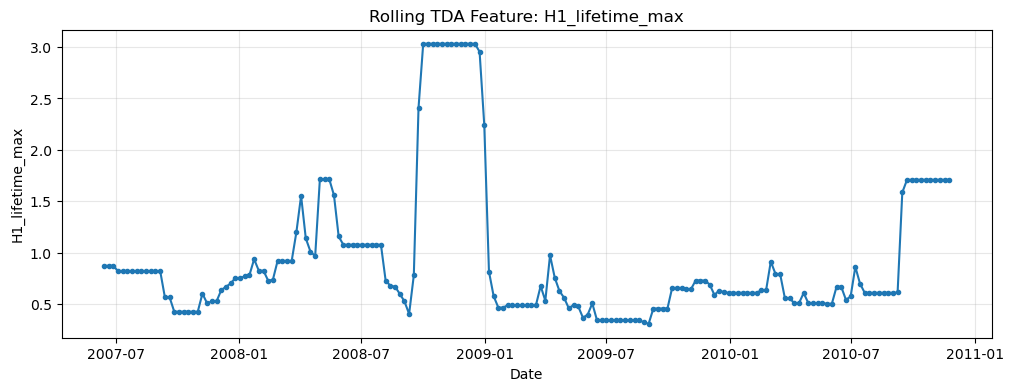

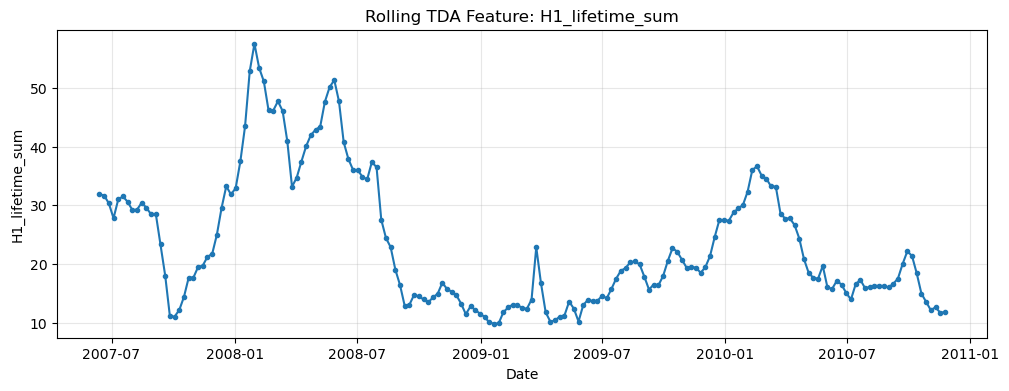

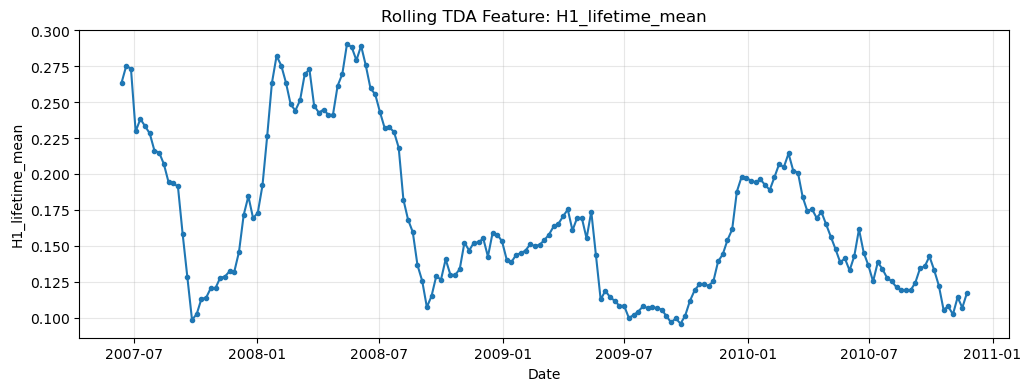

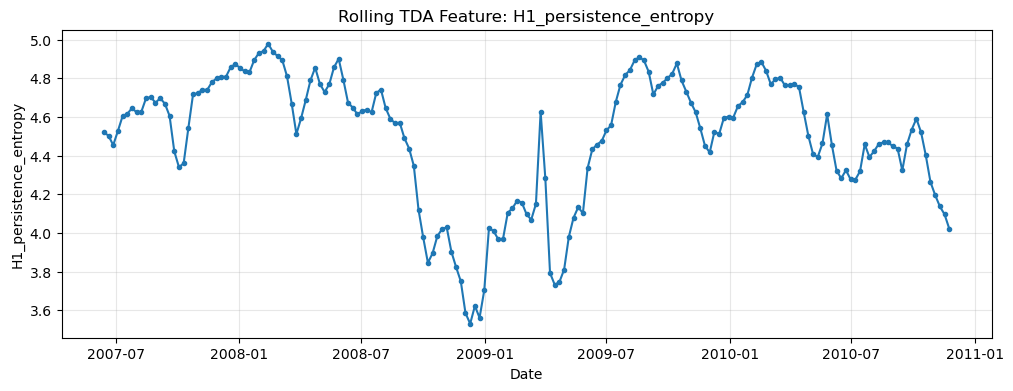

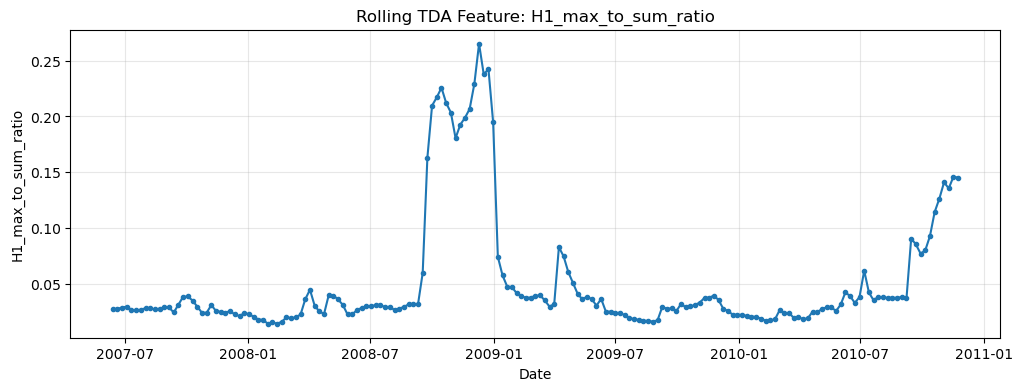

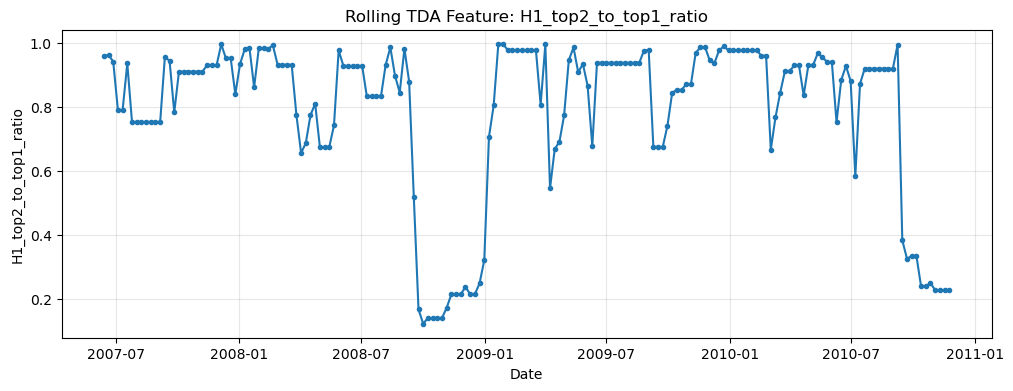

In [54]:
# =====================================================
# 9.7 H1特徴量の時系列変化
# =====================================================

plot_cols = [
    "H1_lifetime_max",
    "H1_lifetime_sum",
    "H1_lifetime_mean",
    "H1_persistence_entropy",
    "H1_max_to_sum_ratio",
    "H1_top2_to_top1_ratio",
]

existing_plot_cols = [
    col for col in plot_cols
    if col in rolling_tda_features_df.columns
]

if len(rolling_tda_features_df) == 0:
    print("rolling_tda_features_df が空のため、可視化をスキップします。")
elif len(existing_plot_cols) == 0:
    print("可視化対象のH1特徴量列が見つかりません。")
else:
    for col in existing_plot_cols:
        plt.figure(figsize=(12, 4))
        plt.plot(
            rolling_tda_features_df["date"],
            rolling_tda_features_df[col],
            marker="o",
            markersize=3
        )
        plt.title(f"Rolling TDA Feature: {col}")
        plt.xlabel("Date")
        plt.ylabel(col)
        plt.grid(True, alpha=0.3)
        plt.show()


## 9.8 Rolling TDA特徴量を保存する

次の章で通常特徴量と結合できるように、CSVとして保存する。


In [55]:
# =====================================================
# 9.8 Rolling TDA特徴量の保存
# =====================================================

ROLLING_TDA_FEATURES_CSV = "rolling_tda_features.csv"

rolling_tda_features_df.to_csv(
    ROLLING_TDA_FEATURES_CSV,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了:", ROLLING_TDA_FEATURES_CSV)
print("DataFrame 名: rolling_tda_features_df")
print("shape:", rolling_tda_features_df.shape)


保存完了: rolling_tda_features.csv
DataFrame 名: rolling_tda_features_df
shape: (181, 34)


## 9.9 この章の結論

この章では、系列全体に対するTDA特徴量ではなく、**時点ごとに対応するRolling Window TDA特徴量**を作成した。

作成した `rolling_tda_features_df` は、次のような構造を持つ。

| 列 | 内容 |
|---|---|
| `date` | rolling window の終了日 |
| `H0_*` | 連結成分に関するTDA特徴量 |
| `H1_*` | ループ構造に関するTDA特徴量 |
| `tda_*` | window size, embedding_dim, delay などの設定情報 |

次の段階では、`date` をキーとして通常特徴量と結合する。

```python
model_features_df = normal_features_df.merge(
    rolling_tda_features_df,
    on="date",
    how="left"
)
```

これにより、TDA特徴量を加えたモデルと、通常特徴量のみのモデルを比較できる。


---

# 10. 通常特徴量とTDA特徴量の結合

ここでは、9章で作成した `rolling_tda_features_df` を、通常の時系列特徴量と結合する。

重要な点は、**予測対象日の値を特徴量作成に使わないこと**である。  
9章の `rolling_tda_features_df["date"]` は、rolling window の終了日を表す。したがって、そのまま同じ日付の目的変数予測に使うと、window内に予測対象日の値が含まれる可能性がある。

そこで本章では、TDA特徴量の利用可能日を次のように定義する。

```text
tda_available_date = rolling_window_end_date + 1日
```

これにより、例えば 2008-01-10 までのデータから作ったTDA特徴量は、2008-01-11 以降の予測に使う。

最終的に、以下のDataFrameを作成する。

| DataFrame | 内容 |
|---|---|
| `normal_features_df` | 通常特徴量のみ |
| `tda_features_for_merge_df` | 結合用に整形したRolling TDA特徴量 |
| `model_features_with_tda_df` | 通常特徴量 + TDA特徴量 |
| `X_normal_aligned` | 比較用の通常特徴量のみの説明変数 |
| `X_tda_model` | 通常特徴量 + TDA特徴量の説明変数 |
| `y_model` | 目的変数 |


## 10.1 通常特徴量を再作成する

notebook1で使った通常特徴量に合わせて、以下を作成する。

- ラグ特徴量: `lag_1`, `lag_2`, `lag_3`, `lag_7`, `lag_14`
- 移動統計量: `rolling_mean_7`, `rolling_std_7`, `rolling_mean_14`, `rolling_std_14`
- カレンダー特徴量: `dayofweek`, `month`, `is_weekend`

ラグ特徴量・移動統計量はすべて `shift(1)` を使い、当日の目的変数を説明変数に含めない。


In [56]:
# =====================================================
# 10.1 通常特徴量を再作成する
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 目的変数系列を取得する
# -------------------------
target_col = "Global_active_power"

if "y_daily" in globals():
    # notebook1由来の y_daily がある場合
    if isinstance(y_daily, pd.DataFrame):
        base_series = y_daily[target_col].copy()
    else:
        base_series = y_daily.copy()
        base_series.name = target_col
    print("base_series: y_daily を使用します。")

elif "df_daily" in globals():
    # このTDA notebookで作成済みの df_daily を使う
    base_series = df_daily[target_col].copy()
    print("base_series: df_daily を使用します。")

elif "df_clean" in globals():
    # 分単位データしかない場合は日次平均に集約する
    base_series = df_clean[target_col].resample("D").mean()
    print("base_series: df_clean から日次平均を作成しました。")

else:
    raise NameError("y_daily, df_daily, df_clean のいずれも見つかりません。")

base_series = base_series.dropna().sort_index()
base_series.name = target_col

# -------------------------
# 通常特徴量を作成する
# -------------------------
normal_features_df = base_series.to_frame(name=target_col)

# ラグ特徴量
normal_features_df["lag_1"] = normal_features_df[target_col].shift(1)
normal_features_df["lag_2"] = normal_features_df[target_col].shift(2)
normal_features_df["lag_3"] = normal_features_df[target_col].shift(3)
normal_features_df["lag_7"] = normal_features_df[target_col].shift(7)
normal_features_df["lag_14"] = normal_features_df[target_col].shift(14)

# 移動平均・移動標準偏差
# shift(1) により、予測対象日の値を使わない
normal_features_df["rolling_mean_7"] = (
    normal_features_df[target_col]
    .shift(1)
    .rolling(window=7)
    .mean()
)

normal_features_df["rolling_std_7"] = (
    normal_features_df[target_col]
    .shift(1)
    .rolling(window=7)
    .std()
)

normal_features_df["rolling_mean_14"] = (
    normal_features_df[target_col]
    .shift(1)
    .rolling(window=14)
    .mean()
)

normal_features_df["rolling_std_14"] = (
    normal_features_df[target_col]
    .shift(1)
    .rolling(window=14)
    .std()
)

# カレンダー特徴量
normal_features_df["dayofweek"] = normal_features_df.index.dayofweek
normal_features_df["month"] = normal_features_df.index.month
normal_features_df["is_weekend"] = (
    normal_features_df.index.dayofweek >= 5
).astype(int)

# 欠損値を除去
normal_features_df = normal_features_df.dropna().copy()

# merge用に日付列を作る
normal_features_df = (
    normal_features_df
    .reset_index()
    .rename(columns={normal_features_df.index.name or "index": "date"})
)

# 念のため date 列名を補正
if "date" not in normal_features_df.columns:
    first_col = normal_features_df.columns[0]
    normal_features_df = normal_features_df.rename(columns={first_col: "date"})

normal_features_df["date"] = pd.to_datetime(normal_features_df["date"])
normal_features_df = normal_features_df.sort_values("date").reset_index(drop=True)

normal_feature_cols = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_14",
    "rolling_std_14",
    "dayofweek",
    "month",
    "is_weekend",
]

print("normal_features_df shape:", normal_features_df.shape)
print("通常特徴量列数:", len(normal_feature_cols))
print("期間:", normal_features_df["date"].min(), "〜", normal_features_df["date"].max())

display(normal_features_df.head())


base_series: df_daily を使用します。
normal_features_df shape: (1428, 14)
通常特徴量列数: 12
期間: 2006-12-30 00:00:00 〜 2010-11-26 00:00:00


,date,Global_active_power,lag_1,lag_2,lag_3,lag_7,lag_14,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,dayofweek,month,is_weekend
0,2006-12-30,1.939709,2.204439,1.439332,1.061639,3.314851,3.053475,2.061153,0.767759,1.920635,0.714551,5,12,1
1,2006-12-31,2.426525,1.939709,2.204439,1.439332,1.770842,2.354486,1.864704,0.533787,1.841080,0.636457,6,12,1
2,2007-01-01,1.909031,2.426525,1.939709,2.204439,1.904944,1.530435,1.958373,0.570816,1.846226,0.641201,0,1,0
3,2007-01-02,0.881414,1.909031,2.426525,1.939709,2.732021,1.157079,1.958956,0.570754,1.873268,0.634810,1,1,0
4,2007-01-03,0.704204,0.881414,1.909031,2.426525,1.061639,1.545658,1.694584,0.581490,1.853578,0.662408,2,1,0


## 10.2 Rolling TDA特徴量を結合用に整形する

`rolling_tda_features_df` の `date` は rolling window の終了日である。  
このまま同じ日付の目的変数予測に使うとリークの可能性があるため、`date + 1日` を `tda_available_date` とする。

また、通常特徴量と区別しやすいように、TDA特徴量列には `tda_` prefix を付ける。


In [57]:
# =====================================================
# 10.2 Rolling TDA特徴量を結合用に整形する
# =====================================================

# rolling_tda_features_df がメモリ上になければCSVから読み込む
if "rolling_tda_features_df" not in globals():
    ROLLING_TDA_FEATURES_CSV = "rolling_tda_features.csv"
    rolling_tda_features_df = pd.read_csv(ROLLING_TDA_FEATURES_CSV)
    print("rolling_tda_features_df をCSVから読み込みました。")

if len(rolling_tda_features_df) == 0:
    raise ValueError("rolling_tda_features_df が空です。先に9章を実行してください。")

# date型を整える
tda_features_for_merge_df = rolling_tda_features_df.copy()
tda_features_for_merge_df["date"] = pd.to_datetime(tda_features_for_merge_df["date"])
tda_features_for_merge_df = tda_features_for_merge_df.sort_values("date").reset_index(drop=True)

# window終了日の翌日から利用可能とみなす
# これにより、予測対象日の値がTDA特徴量に入るリークを避ける
tda_features_for_merge_df["tda_available_date"] = (
    tda_features_for_merge_df["date"] + pd.Timedelta(days=1)
)

# TDA特徴量列を選ぶ
# date は window終了日として保持し、結合キーは tda_available_date を使う
raw_tda_feature_cols = [
    col for col in tda_features_for_merge_df.columns
    if col not in ["date", "tda_available_date"]
]

# 通常特徴量と区別するため、TDA由来列に tda_ prefix を付ける
rename_map = {}
for col in raw_tda_feature_cols:
    if col.startswith("tda_"):
        rename_map[col] = col
    else:
        rename_map[col] = f"tda_{col}"

tda_features_for_merge_df = tda_features_for_merge_df.rename(columns=rename_map)

tda_feature_cols = list(rename_map.values())

# window終了日も確認用に残す
tda_features_for_merge_df = tda_features_for_merge_df.rename(
    columns={"date": "tda_window_end_date"}
)

# 結合に使う列順
tda_features_for_merge_df = tda_features_for_merge_df[
    ["tda_available_date", "tda_window_end_date"] + tda_feature_cols
].copy()

# 数値列に inf があれば欠損に変換
for col in tda_feature_cols:
    tda_features_for_merge_df[col] = pd.to_numeric(
        tda_features_for_merge_df[col],
        errors="coerce"
    )

tda_features_for_merge_df[tda_feature_cols] = tda_features_for_merge_df[tda_feature_cols].replace(
    [np.inf, -np.inf],
    np.nan
)

print("tda_features_for_merge_df shape:", tda_features_for_merge_df.shape)
print("TDA特徴量列数:", len(tda_feature_cols))
print("TDA window終了期間:", tda_features_for_merge_df["tda_window_end_date"].min(), "〜", tda_features_for_merge_df["tda_window_end_date"].max())
print("TDA利用可能期間:", tda_features_for_merge_df["tda_available_date"].min(), "〜", tda_features_for_merge_df["tda_available_date"].max())

display(tda_features_for_merge_df.head())


tda_features_for_merge_df shape: (181, 35)
TDA特徴量列数: 33
TDA window終了期間: 2007-06-13 00:00:00 〜 2010-11-24 00:00:00
TDA利用可能期間: 2007-06-14 00:00:00 〜 2010-11-25 00:00:00


,tda_available_date,tda_window_end_date,tda_H0_n_points,tda_H0_lifetime_max,tda_H0_lifetime_sum,tda_H0_lifetime_mean,tda_H0_lifetime_median,tda_H0_lifetime_std,tda_H0_lifetime_q25,tda_H0_lifetime_q75,tda_H0_n_long_lifetime,tda_H0_persistence_entropy,tda_H1_n_points,tda_H1_lifetime_max,tda_H1_lifetime_sum,tda_H1_lifetime_mean,tda_H1_lifetime_median,tda_H1_lifetime_std,tda_H1_lifetime_q25,tda_H1_lifetime_q75,tda_H1_n_long_lifetime,tda_H1_persistence_entropy,tda_H1_lifetime_top1,tda_H1_lifetime_top2,tda_H1_lifetime_top3,tda_H1_lifetime_top4,tda_H1_lifetime_top5,tda_H1_max_to_sum_ratio,tda_H1_top2_to_top1_ratio,tda_H1_top1_minus_top2,tda_window_size,tda_point_cloud_n_points,tda_embedding_dim,tda_delay,tda_stride
0,2007-06-14,2007-06-13,149,8.483282,840.852056,5.643302,5.894402,1.540838,4.000627,6.987403,15,4.965618,121,0.872019,31.912018,0.263736,0.240612,0.192490,0.113200,0.373479,13,4.520216,0.872019,0.836886,0.743024,0.711422,0.691741,0.027326,0.959711,0.035132,180,150,30,1,1
1,2007-06-21,2007-06-20,149,8.152966,808.785681,5.428092,5.654368,1.485786,3.825861,6.746675,15,4.965753,115,0.872019,31.680223,0.275480,0.245691,0.185778,0.134531,0.388998,12,4.503586,0.872019,0.839417,0.711422,0.649669,0.619012,0.027526,0.962614,0.032601,180,150,30,1,1
2,2007-06-28,2007-06-27,149,7.911849,790.828684,5.307575,5.139360,1.466332,3.805858,6.644309,15,4.965510,111,0.872019,30.352891,0.273449,0.244450,0.189456,0.118038,0.395053,12,4.454370,0.872019,0.821437,0.711422,0.649669,0.619012,0.028729,0.941994,0.050582,180,150,30,1,1
3,2007-07-05,2007-07-04,149,7.911849,783.398003,5.257705,4.893158,1.483037,3.805858,6.650986,15,4.964310,121,0.821437,27.810226,0.229837,0.191872,0.165231,0.108518,0.327838,13,4.527805,0.821437,0.649669,0.619012,0.555153,0.541603,0.029537,0.790893,0.171768,180,150,30,1,1
4,2007-07-12,2007-07-11,149,7.911849,777.138334,5.215694,4.516284,1.515533,3.793485,6.671594,15,4.962085,130,0.821437,31.005152,0.238501,0.231836,0.166677,0.100818,0.359697,13,4.604822,0.821437,0.649669,0.619012,0.566273,0.555153,0.026494,0.790893,0.171768,180,150,30,1,1


## 10.3 通常特徴量とTDA特徴量を結合する

`ROLLING_STEP = 7` の場合、TDA特徴量は毎日ではなく7日ごとに作成される。  
そのため、単純な完全一致 merge では多くの日で欠損が発生する。

ここでは `pd.merge_asof(..., direction="backward")` を使い、各予測日に対して、**その日以前に利用可能な最新のTDA特徴量**を結合する。

この方法により、未来情報は使わず、かつTDA特徴量を日次モデルに組み込める。


In [58]:
# =====================================================
# 10.3 通常特徴量とTDA特徴量を結合する
# =====================================================

# merge_asof のために日付順に並べる
normal_for_merge = normal_features_df.sort_values("date").reset_index(drop=True).copy()
tda_for_merge = tda_features_for_merge_df.sort_values("tda_available_date").reset_index(drop=True).copy()

model_features_with_tda_df = pd.merge_asof(
    normal_for_merge,
    tda_for_merge,
    left_on="date",
    right_on="tda_available_date",
    direction="backward"
)

print("結合直後 shape:", model_features_with_tda_df.shape)
print("TDA結合前の通常特徴量 shape:", normal_features_df.shape)

# TDA特徴量がまだ利用できない初期期間は欠損になる
missing_tda_rows = model_features_with_tda_df[tda_feature_cols].isna().all(axis=1).sum()
print("TDA特徴量が全て欠損の行数:", missing_tda_rows)

# TDA特徴量が利用できる行だけをモデル用データにする
model_features_with_tda_df = model_features_with_tda_df.dropna(subset=tda_feature_cols).copy()

# 念のため、残った数値欠損は中央値で補完する
# 通常は発生しない想定だが、PH計算の都合で一部特徴量が欠損する場合に備える
numeric_cols = normal_feature_cols + tda_feature_cols
for col in numeric_cols:
    if model_features_with_tda_df[col].isna().sum() > 0:
        median_value = model_features_with_tda_df[col].median()
        model_features_with_tda_df[col] = model_features_with_tda_df[col].fillna(median_value)

model_features_with_tda_df = model_features_with_tda_df.sort_values("date").reset_index(drop=True)

print("結合後・TDA利用可能行のみ shape:", model_features_with_tda_df.shape)
print("期間:", model_features_with_tda_df["date"].min(), "〜", model_features_with_tda_df["date"].max())

display(model_features_with_tda_df.head())
display(model_features_with_tda_df.tail())


結合直後 shape: (1428, 49)
TDA結合前の通常特徴量 shape: (1428, 14)
TDA特徴量が全て欠損の行数: 166
結合後・TDA利用可能行のみ shape: (1262, 49)
期間: 2007-06-14 00:00:00 〜 2010-11-26 00:00:00


,date,Global_active_power,lag_1,lag_2,lag_3,lag_7,lag_14,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,dayofweek,month,is_weekend,tda_available_date,tda_window_end_date,tda_H0_n_points,tda_H0_lifetime_max,tda_H0_lifetime_sum,tda_H0_lifetime_mean,tda_H0_lifetime_median,tda_H0_lifetime_std,tda_H0_lifetime_q25,tda_H0_lifetime_q75,tda_H0_n_long_lifetime,tda_H0_persistence_entropy,tda_H1_n_points,tda_H1_lifetime_max,tda_H1_lifetime_sum,tda_H1_lifetime_mean,tda_H1_lifetime_median,tda_H1_lifetime_std,tda_H1_lifetime_q25,tda_H1_lifetime_q75,tda_H1_n_long_lifetime,tda_H1_persistence_entropy,tda_H1_lifetime_top1,tda_H1_lifetime_top2,tda_H1_lifetime_top3,tda_H1_lifetime_top4,tda_H1_lifetime_top5,tda_H1_max_to_sum_ratio,tda_H1_top2_to_top1_ratio,tda_H1_top1_minus_top2,tda_window_size,tda_point_cloud_n_points,tda_embedding_dim,tda_delay,tda_stride
0,2007-06-14,0.874364,0.643939,0.638032,0.551843,0.684029,0.651771,0.813799,0.321939,0.885169,0.311140,3,6,0,2007-06-14,2007-06-13,149.0,8.483282,840.852056,5.643302,5.894402,1.540838,4.000627,6.987403,15.0,4.965618,121.0,0.872019,31.912018,0.263736,0.240612,0.19249,0.1132,0.373479,13.0,4.520216,0.872019,0.836886,0.743024,0.711422,0.691741,0.027326,0.959711,0.035132,180.0,150.0,30.0,1.0,1.0
1,2007-06-15,0.687225,0.874364,0.643939,0.638032,1.491699,0.726142,0.840989,0.317154,0.901068,0.303898,4,6,0,2007-06-14,2007-06-13,149.0,8.483282,840.852056,5.643302,5.894402,1.540838,4.000627,6.987403,15.0,4.965618,121.0,0.872019,31.912018,0.263736,0.240612,0.19249,0.1132,0.373479,13.0,4.520216,0.872019,0.836886,0.743024,0.711422,0.691741,0.027326,0.959711,0.035132,180.0,150.0,30.0,1.0,1.0
2,2007-06-16,1.401224,0.687225,0.874364,0.643939,0.755930,1.030807,0.726065,0.136191,0.898288,0.305794,5,6,1,2007-06-14,2007-06-13,149.0,8.483282,840.852056,5.643302,5.894402,1.540838,4.000627,6.987403,15.0,4.965618,121.0,0.872019,31.912018,0.263736,0.240612,0.19249,0.1132,0.373479,13.0,4.520216,0.872019,0.836886,0.743024,0.711422,0.691741,0.027326,0.959711,0.035132,180.0,150.0,30.0,1.0,1.0
3,2007-06-17,1.352146,1.401224,0.687225,0.874364,0.931119,1.463907,0.818249,0.290617,0.924747,0.332960,6,6,1,2007-06-14,2007-06-13,149.0,8.483282,840.852056,5.643302,5.894402,1.540838,4.000627,6.987403,15.0,4.965618,121.0,0.872019,31.912018,0.263736,0.240612,0.19249,0.1132,0.373479,13.0,4.520216,0.872019,0.836886,0.743024,0.711422,0.691741,0.027326,0.959711,0.035132,180.0,150.0,30.0,1.0,1.0
4,2007-06-18,0.471163,1.352146,1.401224,0.687225,0.551843,0.633068,0.878396,0.354432,0.916764,0.320131,0,6,0,2007-06-14,2007-06-13,149.0,8.483282,840.852056,5.643302,5.894402,1.540838,4.000627,6.987403,15.0,4.965618,121.0,0.872019,31.912018,0.263736,0.240612,0.19249,0.1132,0.373479,13.0,4.520216,0.872019,0.836886,0.743024,0.711422,0.691741,0.027326,0.959711,0.035132,180.0,150.0,30.0,1.0,1.0


,date,Global_active_power,lag_1,lag_2,lag_3,lag_7,lag_14,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,dayofweek,month,is_weekend,tda_available_date,tda_window_end_date,tda_H0_n_points,tda_H0_lifetime_max,tda_H0_lifetime_sum,tda_H0_lifetime_mean,tda_H0_lifetime_median,tda_H0_lifetime_std,tda_H0_lifetime_q25,tda_H0_lifetime_q75,tda_H0_n_long_lifetime,tda_H0_persistence_entropy,tda_H1_n_points,tda_H1_lifetime_max,tda_H1_lifetime_sum,tda_H1_lifetime_mean,tda_H1_lifetime_median,tda_H1_lifetime_std,tda_H1_lifetime_q25,tda_H1_lifetime_q75,tda_H1_n_long_lifetime,tda_H1_persistence_entropy,tda_H1_lifetime_top1,tda_H1_lifetime_top2,tda_H1_lifetime_top3,tda_H1_lifetime_top4,tda_H1_lifetime_top5,tda_H1_max_to_sum_ratio,tda_H1_top2_to_top1_ratio,tda_H1_top1_minus_top2,tda_window_size,tda_point_cloud_n_points,tda_embedding_dim,tda_delay,tda_stride
1257,2010-11-22,1.417733,0.625632,1.525699,1.090556,1.213460,1.267736,1.107106,0.265755,1.221517,0.222261,0,11,0,2010-11-18,2010-11-17,149.0,4.601094,418.914210,2.811505,2.644982,0.898304,2.201483,3.343407,15.0,4.952213,109.0,1.708814,11.699890,0.107338,0.069427,0.175283,0.032290,0.129639,11.0,4.096149,1.708814,0.389601,0.367688,0.333748,0.291068,0.146054,0.227995,1.319213,180.0,150.0,30.0,1.0,1.0
1258,2010-11-23,1.095511,1.417733,0.625632,1.525699,1.048436,1.404235,1.136288,0.289531,1.232231,0.228197,1,11,0,2010-11-18,2010-11-17,149.0,4.601094,418.914210,2.811505,2.644982,0.898304,2.201483,3.343407,15.0,4.952213,109.0,1.708814,11.699890,0.107338,0.069427,0.175283,0.032290,0.129639,11.0,4.096149,1.708814,0.389601,0.367688,0.333748,0.291068,0.146054,0.227995,1.319213,180.0,150.0,30.0,1.0,1.0
1259,2010-11-24,1.247394,1.095511,1.417733,0.625632,1.098633,1.351760,1.143013,0.287692,1.210179,0.225194,2,11,0,2010-11-18,2010-11-17,149.0,4.601094,418.914210,2.811505,2.644982,0.898304,2.201483,3.343407,15.0,4.952213,109.0,1.708814,11.699890,0.107338,0.069427,0.175283,0.032290,0.129639,11.0,4.096149,1.708814,0.389601,0.367688,0.333748,0.291068,0.146054,0.227995,1.319213,180.0,150.0,30.0,1.0,1.0
1260,2010-11-25,0.993864,1.247394,1.095511,1.417733,1.147328,1.231661,1.164265,0.289357,1.202725,0.221849,3,11,0,2010-11-25,2010-11-24,149.0,4.601094,429.908247,2.885290,2.736739,0.922640,2.201483,3.851816,15.0,4.951194,100.0,1.708814,11.775445,0.117754,0.072163,0.184046,0.033045,0.152305,10.0,4.022200,1.708814,0.389601,0.383832,0.367688,0.333748,0.145117,0.227995,1.319213,180.0,150.0,30.0,1.0,1.0
1261,2010-11-26,1.178230,0.993864,1.247394,1.095511,1.090556,1.275571,1.142341,0.296577,1.185739,0.228467,4,11,0,2010-11-25,2010-11-24,149.0,4.601094,429.908247,2.885290,2.736739,0.922640,2.201483,3.851816,15.0,4.951194,100.0,1.708814,11.775445,0.117754,0.072163,0.184046,0.033045,0.152305,10.0,4.022200,1.708814,0.389601,0.383832,0.367688,0.333748,0.145117,0.227995,1.319213,180.0,150.0,30.0,1.0,1.0


## 10.4 結合後の欠損値と列を確認する

ここでは、結合後のDataFrameがモデルに使える状態か確認する。


In [59]:
# =====================================================
# 10.4 結合後の欠損値と列を確認する
# =====================================================

print("model_features_with_tda_df shape:", model_features_with_tda_df.shape)

print("通常特徴量列")
display(pd.DataFrame({"normal_feature": normal_feature_cols}))

print("TDA特徴量列")
display(pd.DataFrame({"tda_feature": tda_feature_cols}))

missing_summary = (
    model_features_with_tda_df
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

print("欠損値数")
display(missing_summary[missing_summary["missing_count"] > 0])

if missing_summary["missing_count"].sum() == 0:
    print("欠損値はありません。")
else:
    print("欠損値が残っています。上の表を確認してください。")


model_features_with_tda_df shape: (1262, 49)
通常特徴量列


,normal_feature
0,lag_1
1,lag_2
2,lag_3
3,lag_7
4,lag_14
5,rolling_mean_7
6,rolling_std_7
7,rolling_mean_14
8,rolling_std_14
9,dayofweek


TDA特徴量列


,tda_feature
0,tda_H0_n_points
1,tda_H0_lifetime_max
2,tda_H0_lifetime_sum
3,tda_H0_lifetime_mean
4,tda_H0_lifetime_median
5,tda_H0_lifetime_std
6,tda_H0_lifetime_q25
7,tda_H0_lifetime_q75
8,tda_H0_n_long_lifetime
9,tda_H0_persistence_entropy


欠損値数


,missing_count


欠損値はありません。


## 10.5 モデル入力用の `X` と `y` を作成する

次章のモデル学習で比較しやすいように、以下を作成する。

- `X_normal_aligned`: TDA特徴量が利用できる期間に揃えた通常特徴量のみ
- `X_tda_model`: 通常特徴量 + TDA特徴量
- `y_model`: 目的変数

これにより、通常特徴量のみのモデルとTDA追加モデルを**同じ期間・同じ行数**で比較できる。


In [60]:
# =====================================================
# 10.5 モデル入力用の X, y を作成する
# =====================================================

# 説明変数と目的変数
X_normal_aligned = model_features_with_tda_df[normal_feature_cols].copy()
X_tda_model = model_features_with_tda_df[normal_feature_cols + tda_feature_cols].copy()
y_model = model_features_with_tda_df[target_col].copy()

# index を date にしておくと、時系列分割・可視化で扱いやすい
model_dates = model_features_with_tda_df["date"].copy()

X_normal_aligned.index = model_dates
X_tda_model.index = model_dates
y_model.index = model_dates

print("X_normal_aligned:", X_normal_aligned.shape)
print("X_tda_model      :", X_tda_model.shape)
print("y_model          :", y_model.shape)

print("通常特徴量数:", len(normal_feature_cols))
print("TDA特徴量数:", len(tda_feature_cols))
print("合計特徴量数:", X_tda_model.shape[1])

print("期間:", y_model.index.min(), "〜", y_model.index.max())

display(X_tda_model.head())


X_normal_aligned: (1262, 12)
X_tda_model      : (1262, 45)
y_model          : (1262,)
通常特徴量数: 12
TDA特徴量数: 33
合計特徴量数: 45
期間: 2007-06-14 00:00:00 〜 2010-11-26 00:00:00


,lag_1,lag_2,lag_3,lag_7,lag_14,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,dayofweek,month,is_weekend,tda_H0_n_points,tda_H0_lifetime_max,tda_H0_lifetime_sum,tda_H0_lifetime_mean,tda_H0_lifetime_median,tda_H0_lifetime_std,tda_H0_lifetime_q25,tda_H0_lifetime_q75,tda_H0_n_long_lifetime,tda_H0_persistence_entropy,tda_H1_n_points,tda_H1_lifetime_max,tda_H1_lifetime_sum,tda_H1_lifetime_mean,tda_H1_lifetime_median,tda_H1_lifetime_std,tda_H1_lifetime_q25,tda_H1_lifetime_q75,tda_H1_n_long_lifetime,tda_H1_persistence_entropy,tda_H1_lifetime_top1,tda_H1_lifetime_top2,tda_H1_lifetime_top3,tda_H1_lifetime_top4,tda_H1_lifetime_top5,tda_H1_max_to_sum_ratio,tda_H1_top2_to_top1_ratio,tda_H1_top1_minus_top2,tda_window_size,tda_point_cloud_n_points,tda_embedding_dim,tda_delay,tda_stride
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2007-06-14,0.643939,0.638032,0.551843,0.684029,0.651771,0.813799,0.321939,0.885169,0.311140,3,6,0,149.0,8.483282,840.852056,5.643302,5.894402,1.540838,4.000627,6.987403,15.0,4.965618,121.0,0.872019,31.912018,0.263736,0.240612,0.19249,0.1132,0.373479,13.0,4.520216,0.872019,0.836886,0.743024,0.711422,0.691741,0.027326,0.959711,0.035132,180.0,150.0,30.0,1.0,1.0
2007-06-15,0.874364,0.643939,0.638032,1.491699,0.726142,0.840989,0.317154,0.901068,0.303898,4,6,0,149.0,8.483282,840.852056,5.643302,5.894402,1.540838,4.000627,6.987403,15.0,4.965618,121.0,0.872019,31.912018,0.263736,0.240612,0.19249,0.1132,0.373479,13.0,4.520216,0.872019,0.836886,0.743024,0.711422,0.691741,0.027326,0.959711,0.035132,180.0,150.0,30.0,1.0,1.0
2007-06-16,0.687225,0.874364,0.643939,0.755930,1.030807,0.726065,0.136191,0.898288,0.305794,5,6,1,149.0,8.483282,840.852056,5.643302,5.894402,1.540838,4.000627,6.987403,15.0,4.965618,121.0,0.872019,31.912018,0.263736,0.240612,0.19249,0.1132,0.373479,13.0,4.520216,0.872019,0.836886,0.743024,0.711422,0.691741,0.027326,0.959711,0.035132,180.0,150.0,30.0,1.0,1.0
2007-06-17,1.401224,0.687225,0.874364,0.931119,1.463907,0.818249,0.290617,0.924747,0.332960,6,6,1,149.0,8.483282,840.852056,5.643302,5.894402,1.540838,4.000627,6.987403,15.0,4.965618,121.0,0.872019,31.912018,0.263736,0.240612,0.19249,0.1132,0.373479,13.0,4.520216,0.872019,0.836886,0.743024,0.711422,0.691741,0.027326,0.959711,0.035132,180.0,150.0,30.0,1.0,1.0
2007-06-18,1.352146,1.401224,0.687225,0.551843,0.633068,0.878396,0.354432,0.916764,0.320131,0,6,0,149.0,8.483282,840.852056,5.643302,5.894402,1.540838,4.000627,6.987403,15.0,4.965618,121.0,0.872019,31.912018,0.263736,0.240612,0.19249,0.1132,0.373479,13.0,4.520216,0.872019,0.836886,0.743024,0.711422,0.691741,0.027326,0.959711,0.035132,180.0,150.0,30.0,1.0,1.0


## 10.6 時系列順に train/test 分割する

次章でモデル比較を行うため、通常特徴量のみの場合とTDA特徴量を追加した場合で、同じ train/test 期間を使う。


In [61]:
# =====================================================
# 10.6 時系列順に train/test 分割
# =====================================================

train_size_tda = int(len(y_model) * 0.8)

X_normal_train = X_normal_aligned.iloc[:train_size_tda]
X_normal_test = X_normal_aligned.iloc[train_size_tda:]

X_tda_train = X_tda_model.iloc[:train_size_tda]
X_tda_test = X_tda_model.iloc[train_size_tda:]

y_train_tda = y_model.iloc[:train_size_tda]
y_test_tda = y_model.iloc[train_size_tda:]

print("通常特徴量のみ")
print("X_normal_train:", X_normal_train.shape)
print("X_normal_test :", X_normal_test.shape)

print("通常特徴量 + TDA特徴量")
print("X_tda_train:", X_tda_train.shape)
print("X_tda_test :", X_tda_test.shape)

print("y")
print("y_train_tda:", y_train_tda.shape)
print("y_test_tda :", y_test_tda.shape)

print("train期間:", y_train_tda.index.min(), "〜", y_train_tda.index.max())
print("test期間 :", y_test_tda.index.min(), "〜", y_test_tda.index.max())


通常特徴量のみ
X_normal_train: (1009, 12)
X_normal_test : (253, 12)
通常特徴量 + TDA特徴量
X_tda_train: (1009, 45)
X_tda_test : (253, 45)
y
y_train_tda: (1009,)
y_test_tda : (253,)
train期間: 2007-06-14 00:00:00 〜 2010-03-18 00:00:00
test期間 : 2010-03-19 00:00:00 〜 2010-11-26 00:00:00


## 10.7 結合後データを保存する

次章のモデル学習で再利用できるように、結合済みデータをCSVとして保存する。


In [62]:
# =====================================================
# 10.7 結合後データの保存
# =====================================================

MERGED_FEATURES_CSV = "model_features_with_tda.csv"

model_features_with_tda_df.to_csv(
    MERGED_FEATURES_CSV,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了:", MERGED_FEATURES_CSV)
print("DataFrame 名: model_features_with_tda_df")
print("shape:", model_features_with_tda_df.shape)


保存完了: model_features_with_tda.csv
DataFrame 名: model_features_with_tda_df
shape: (1262, 49)


## 10.8 この章の結論

この章では、通常特徴量とRolling Window TDA特徴量を結合した。

ポイントは次の通り。

1. 通常特徴量は、ラグ・移動統計量・カレンダー特徴量で作成した。
2. TDA特徴量は、rolling window の終了日の翌日から利用可能とした。
3. `merge_asof` により、各予測日に対して過去に利用可能な最新のTDA特徴量を結合した。
4. `X_normal_aligned` と `X_tda_model` を作成し、同じ期間で通常特徴量モデルとTDA追加モデルを比較できる状態にした。

次の段階では、以下を比較する。

```text
通常特徴量のみのモデル
vs
通常特徴量 + TDA特徴量のモデル
```

これにより、TDA特徴量が予測性能の改善に寄与するかを確認する。


---

# 11. モデル学習：通常特徴量のみ vs 通常特徴量 + TDA特徴量

この章では、10章で作成した以下の2種類の説明変数を使って、同じ目的変数・同じ train/test 期間で予測モデルを学習する。

| 比較対象 | 説明変数 |
|---|---|
| 通常特徴量モデル | `X_normal_aligned` |
| TDA追加モデル | `X_tda_model` |

比較の目的は、Rolling Window によって作成したTDA特徴量が、通常特徴量だけの場合に比べて予測性能を改善するかを確認することである。

評価指標は、これまでの時系列解析 notebook に合わせて以下を使う。

- MAE
- RMSE
- MAPE
- MASE
- R2

注意点として、この章では **TDA特徴量の有効性を断定するのではなく、同一条件で比較したときに改善が見られるか** を確認する。


## 11.1 学習用データの確認

まず、10章で作成した `X_normal_train`, `X_normal_test`, `X_tda_train`, `X_tda_test`, `y_train_tda`, `y_test_tda` が存在するか確認する。

存在しない場合は、保存済みの `model_features_with_tda.csv` から再構成する。


In [63]:
# =====================================================
# 11.1 学習用データの確認・再構成
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------------------
# 10章の変数がない場合はCSVから再構成する
# -----------------------------------------
required_vars = [
    "X_normal_train", "X_normal_test",
    "X_tda_train", "X_tda_test",
    "y_train_tda", "y_test_tda",
    "normal_feature_cols", "tda_feature_cols"
]

missing_vars = [v for v in required_vars if v not in globals()]

if len(missing_vars) > 0:
    print("以下の変数が見つからないため、model_features_with_tda.csv から再構成します。")
    print(missing_vars)

    MERGED_FEATURES_CSV = "model_features_with_tda.csv"
    model_features_with_tda_df = pd.read_csv(MERGED_FEATURES_CSV)
    model_features_with_tda_df["date"] = pd.to_datetime(model_features_with_tda_df["date"])
    model_features_with_tda_df = model_features_with_tda_df.sort_values("date").reset_index(drop=True)

    target_col = "Global_active_power"

    # 通常特徴量列
    normal_feature_cols = [
        "lag_1", "lag_2", "lag_3", "lag_7", "lag_14",
        "rolling_mean_7", "rolling_std_7",
        "rolling_mean_14", "rolling_std_14",
        "dayofweek", "month", "is_weekend"
    ]
    normal_feature_cols = [
        col for col in normal_feature_cols
        if col in model_features_with_tda_df.columns
    ]

    # TDA特徴量列
    tda_feature_cols = [
        col for col in model_features_with_tda_df.columns
        if col.startswith("tda_")
        and col not in ["tda_available_date", "tda_window_end_date"]
    ]

    X_normal_aligned = model_features_with_tda_df[normal_feature_cols].copy()
    X_tda_model = model_features_with_tda_df[normal_feature_cols + tda_feature_cols].copy()
    y_model = model_features_with_tda_df[target_col].copy()

    model_dates = model_features_with_tda_df["date"].copy()
    X_normal_aligned.index = model_dates
    X_tda_model.index = model_dates
    y_model.index = model_dates

    train_size_tda = int(len(y_model) * 0.8)

    X_normal_train = X_normal_aligned.iloc[:train_size_tda]
    X_normal_test = X_normal_aligned.iloc[train_size_tda:]

    X_tda_train = X_tda_model.iloc[:train_size_tda]
    X_tda_test = X_tda_model.iloc[train_size_tda:]

    y_train_tda = y_model.iloc[:train_size_tda]
    y_test_tda = y_model.iloc[train_size_tda:]

else:
    print("10章で作成した学習用変数を使用します。")

print("通常特徴量のみ")
print("X_normal_train:", X_normal_train.shape)
print("X_normal_test :", X_normal_test.shape)

print("\n通常特徴量 + TDA特徴量")
print("X_tda_train:", X_tda_train.shape)
print("X_tda_test :", X_tda_test.shape)

print("\ny")
print("y_train_tda:", y_train_tda.shape)
print("y_test_tda :", y_test_tda.shape)

print("\n通常特徴量数:", len(normal_feature_cols))
print("TDA特徴量数:", len(tda_feature_cols))
print("train期間:", y_train_tda.index.min(), "〜", y_train_tda.index.max())
print("test期間 :", y_test_tda.index.min(), "〜", y_test_tda.index.max())


10章で作成した学習用変数を使用します。
通常特徴量のみ
X_normal_train: (1009, 12)
X_normal_test : (253, 12)

通常特徴量 + TDA特徴量
X_tda_train: (1009, 45)
X_tda_test : (253, 45)

y
y_train_tda: (1009,)
y_test_tda : (253,)

通常特徴量数: 12
TDA特徴量数: 33
train期間: 2007-06-14 00:00:00 〜 2010-03-18 00:00:00
test期間 : 2010-03-19 00:00:00 〜 2010-11-26 00:00:00


## 11.2 評価指標の関数を定義する

MASE は、学習期間における naive 予測の平均絶対誤差を分母にする。  
この値が 1 未満なら、学習期間の naive 予測を基準にしたとき、平均的には naive より良い可能性がある。


In [64]:
# =====================================================
# 11.2 評価指標の関数
# =====================================================

def mean_absolute_percentage_error_safe(y_true, y_pred):
    """
    y_true が0に近い点を除外して MAPE を計算する。
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.abs(y_true) > 1e-8
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def mase_score(y_true, y_pred, y_train):
    """
    MASE を計算する。
    分母は train 期間の naive 予測 MAE。
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_train = np.asarray(y_train, dtype=float)

    if len(y_train) < 2:
        return np.nan

    naive_error = np.mean(np.abs(y_train[1:] - y_train[:-1]))

    if naive_error == 0:
        return np.nan

    return np.mean(np.abs(y_true - y_pred)) / naive_error


def evaluate_regression_model(y_true, y_pred, y_train_for_mase):
    """
    予測結果を複数指標で評価する。
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error_safe(y_true, y_pred)
    mase = mase_score(y_true, y_pred, y_train_for_mase)
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "MASE": mase,
        "R2": r2
    }


## 11.3 比較するモデルを定義する

ここでは、最低限の比較として以下の3種類を使う。

| モデル | 役割 |
|---|---|
| Ridge | 線形モデルの比較対象 |
| RandomForest | 非線形モデルの比較対象 |
| GradientBoosting | 木ベースの逐次改善モデル |

通常特徴量のみとTDA追加モデルで、同じモデル群を学習する。


In [65]:
# =====================================================
# 11.3 モデル定義
# =====================================================

models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_samples_leaf=5,
        random_state=42
    )
}

print("使用するモデル")
for name in models.keys():
    print("-", name)


使用するモデル
- Ridge
- RandomForest
- GradientBoosting


## 11.4 通常特徴量のみのモデルを学習する

まず、通常特徴量のみを使ってモデルを学習する。  
この結果が、TDA特徴量を追加した場合の比較基準になる。


In [66]:
# =====================================================
# 11.4 通常特徴量のみのモデル学習
# =====================================================

normal_model_results = []
normal_predictions = pd.DataFrame(index=y_test_tda.index)
normal_predictions["y_true"] = y_test_tda.values

trained_normal_models = {}

for model_name, model in models.items():
    model.fit(X_normal_train, y_train_tda)
    y_pred = model.predict(X_normal_test)

    metrics = evaluate_regression_model(
        y_true=y_test_tda,
        y_pred=y_pred,
        y_train_for_mase=y_train_tda
    )

    row = {
        "feature_set": "normal_only",
        "model": model_name,
        **metrics
    }
    normal_model_results.append(row)
    normal_predictions[f"normal_only_{model_name}"] = y_pred
    trained_normal_models[model_name] = model

normal_model_results_df = pd.DataFrame(normal_model_results)
normal_model_results_df = normal_model_results_df.sort_values("RMSE").reset_index(drop=True)

display(normal_model_results_df)


,feature_set,model,MAE,RMSE,MAPE,MASE,R2
0,normal_only,GradientBoosting,0.158254,0.220544,17.633341,0.603824,0.446169
1,normal_only,RandomForest,0.163198,0.222327,18.603584,0.622685,0.437175
2,normal_only,Ridge,0.169015,0.228476,19.494325,0.644882,0.405613


## 11.5 通常特徴量 + TDA特徴量のモデルを学習する

次に、通常特徴量に Rolling Window TDA特徴量を追加したモデルを学習する。  
train/test の期間は通常特徴量のみのモデルと同じである。


In [67]:
# =====================================================
# 11.5 通常特徴量 + TDA特徴量のモデル学習
# =====================================================

tda_model_results = []
tda_predictions = pd.DataFrame(index=y_test_tda.index)
tda_predictions["y_true"] = y_test_tda.values

trained_tda_models = {}

for model_name, model in models.items():
    model.fit(X_tda_train, y_train_tda)
    y_pred = model.predict(X_tda_test)

    metrics = evaluate_regression_model(
        y_true=y_test_tda,
        y_pred=y_pred,
        y_train_for_mase=y_train_tda
    )

    row = {
        "feature_set": "normal_plus_tda",
        "model": model_name,
        **metrics
    }
    tda_model_results.append(row)
    tda_predictions[f"normal_plus_tda_{model_name}"] = y_pred
    trained_tda_models[model_name] = model

tda_model_results_df = pd.DataFrame(tda_model_results)
tda_model_results_df = tda_model_results_df.sort_values("RMSE").reset_index(drop=True)

display(tda_model_results_df)


,feature_set,model,MAE,RMSE,MAPE,MASE,R2
0,normal_plus_tda,GradientBoosting,0.159206,0.220767,18.435807,0.607457,0.445048
1,normal_plus_tda,RandomForest,0.166194,0.222641,19.388910,0.634118,0.435585
2,normal_plus_tda,Ridge,0.179896,0.237015,21.366028,0.686398,0.360352


## 11.6 通常特徴量のみ vs TDA追加モデルの比較表

同じモデル同士で、通常特徴量のみとTDA追加後の評価指標を比較する。

ここでは、RMSEとMAEは **小さいほど良い**、R2は **大きいほど良い** として見る。


In [68]:
# =====================================================
# 11.6 モデル比較表
# =====================================================

model_comparison_df = pd.concat(
    [normal_model_results_df, tda_model_results_df],
    axis=0,
    ignore_index=True
)

model_comparison_df = model_comparison_df.sort_values(
    ["model", "feature_set"]
).reset_index(drop=True)

# 同じモデル同士で normal_only と normal_plus_tda を横持ち比較する
comparison_wide_df = model_comparison_df.pivot(
    index="model",
    columns="feature_set",
    values=["MAE", "RMSE", "MAPE", "MASE", "R2"]
)

# 改善量を計算する
improvement_rows = []

for model_name in sorted(model_comparison_df["model"].unique()):
    normal_row = model_comparison_df[
        (model_comparison_df["model"] == model_name)
        & (model_comparison_df["feature_set"] == "normal_only")
    ].iloc[0]

    tda_row = model_comparison_df[
        (model_comparison_df["model"] == model_name)
        & (model_comparison_df["feature_set"] == "normal_plus_tda")
    ].iloc[0]

    improvement_rows.append({
        "model": model_name,
        "normal_RMSE": normal_row["RMSE"],
        "tda_RMSE": tda_row["RMSE"],
        "RMSE_diff_tda_minus_normal": tda_row["RMSE"] - normal_row["RMSE"],
        "RMSE_improvement_rate_pct": (normal_row["RMSE"] - tda_row["RMSE"]) / normal_row["RMSE"] * 100,
        "normal_MAE": normal_row["MAE"],
        "tda_MAE": tda_row["MAE"],
        "MAE_diff_tda_minus_normal": tda_row["MAE"] - normal_row["MAE"],
        "MAE_improvement_rate_pct": (normal_row["MAE"] - tda_row["MAE"]) / normal_row["MAE"] * 100,
        "normal_MASE": normal_row["MASE"],
        "tda_MASE": tda_row["MASE"],
        "normal_R2": normal_row["R2"],
        "tda_R2": tda_row["R2"],
        "R2_diff_tda_minus_normal": tda_row["R2"] - normal_row["R2"]
    })

model_improvement_df = pd.DataFrame(improvement_rows)
model_improvement_df = model_improvement_df.sort_values("RMSE_improvement_rate_pct", ascending=False).reset_index(drop=True)

print("全モデルの評価結果")
display(model_comparison_df)

print("同一モデルにおけるTDA追加効果")
display(model_improvement_df)


全モデルの評価結果


,feature_set,model,MAE,RMSE,MAPE,MASE,R2
0,normal_only,GradientBoosting,0.158254,0.220544,17.633341,0.603824,0.446169
1,normal_plus_tda,GradientBoosting,0.159206,0.220767,18.435807,0.607457,0.445048
2,normal_only,RandomForest,0.163198,0.222327,18.603584,0.622685,0.437175
3,normal_plus_tda,RandomForest,0.166194,0.222641,19.388910,0.634118,0.435585
4,normal_only,Ridge,0.169015,0.228476,19.494325,0.644882,0.405613
5,normal_plus_tda,Ridge,0.179896,0.237015,21.366028,0.686398,0.360352


同一モデルにおけるTDA追加効果


,model,normal_RMSE,tda_RMSE,RMSE_diff_tda_minus_normal,RMSE_improvement_rate_pct,normal_MAE,tda_MAE,MAE_diff_tda_minus_normal,MAE_improvement_rate_pct,normal_MASE,tda_MASE,normal_R2,tda_R2,R2_diff_tda_minus_normal
0,GradientBoosting,0.220544,0.220767,0.000223,-0.101189,0.158254,0.159206,0.000952,-0.601805,0.603824,0.607457,0.446169,0.445048,-0.001121
1,RandomForest,0.222327,0.222641,0.000314,-0.141158,0.163198,0.166194,0.002996,-1.835982,0.622685,0.634118,0.437175,0.435585,-0.001590
2,Ridge,0.228476,0.237015,0.008539,-3.737565,0.169015,0.179896,0.010881,-6.437873,0.644882,0.686398,0.405613,0.360352,-0.045261


## 11.7 最良モデルを確認する

通常特徴量のみ、TDA追加モデルを含めた全モデルの中で、RMSEが最も小さいモデルを確認する。


In [69]:
# =====================================================
# 11.7 最良モデルの確認
# =====================================================

best_model_row = model_comparison_df.sort_values("RMSE").iloc[0]

print("RMSE基準の最良モデル")
display(best_model_row.to_frame("value"))

best_feature_set = best_model_row["feature_set"]
best_model_name = best_model_row["model"]

if best_feature_set == "normal_only":
    best_predictions = normal_predictions[["y_true", f"normal_only_{best_model_name}"]].copy()
    best_predictions = best_predictions.rename(columns={f"normal_only_{best_model_name}": "y_pred"})
else:
    best_predictions = tda_predictions[["y_true", f"normal_plus_tda_{best_model_name}"]].copy()
    best_predictions = best_predictions.rename(columns={f"normal_plus_tda_{best_model_name}": "y_pred"})

best_predictions["residual"] = best_predictions["y_true"] - best_predictions["y_pred"]

print("best_feature_set:", best_feature_set)
print("best_model_name :", best_model_name)

display(best_predictions.head())


RMSE基準の最良モデル


,value
feature_set,normal_only
model,GradientBoosting
MAE,0.158254
RMSE,0.220544
MAPE,17.633341
MASE,0.603824
R2,0.446169


best_feature_set: normal_only
best_model_name : GradientBoosting


,y_true,y_pred,residual
date,,,
2010-03-19,1.155128,1.093604,0.061524
2010-03-20,0.567810,1.457754,-0.889943
2010-03-21,1.477105,1.044836,0.432268
2010-03-22,1.124021,1.144180,-0.020159
2010-03-23,1.265390,1.046759,0.218631


## 11.8 予測結果を可視化する

最良モデルについて、test期間の実測値と予測値を比較する。


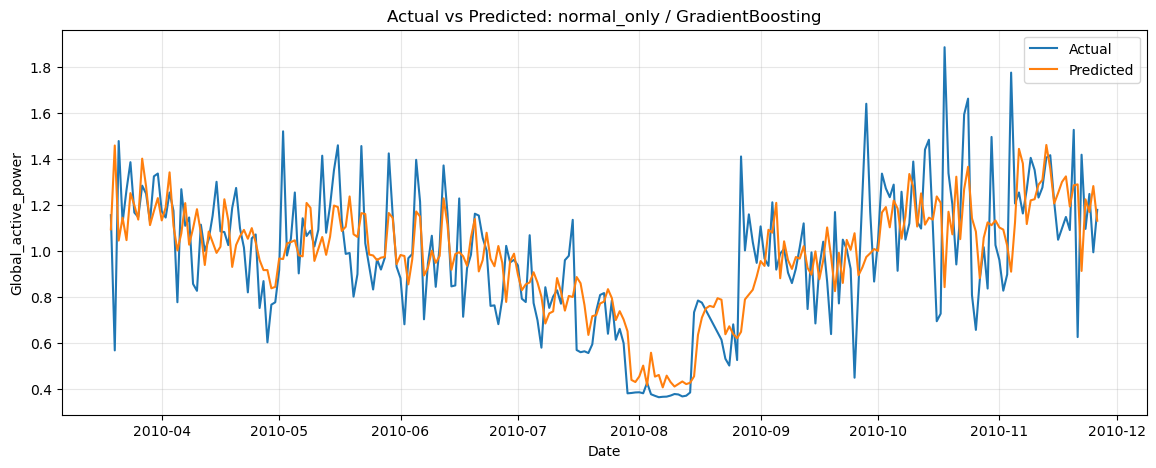

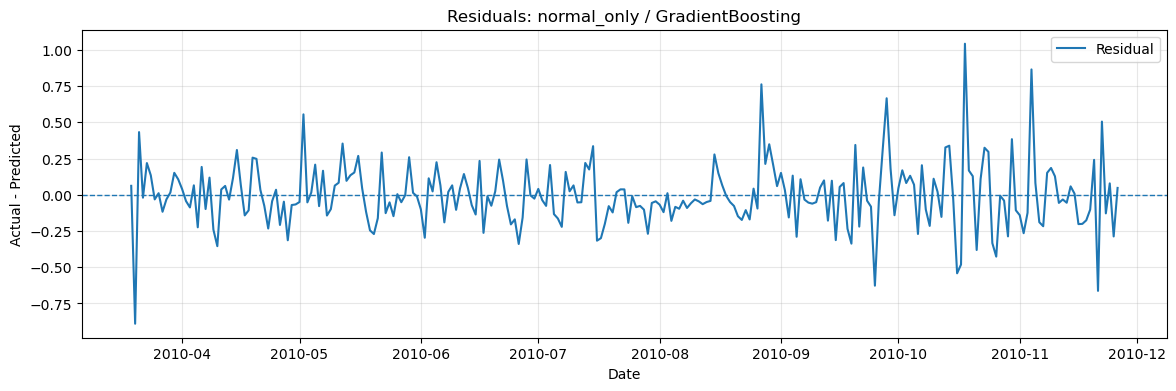

In [70]:
# =====================================================
# 11.8 最良モデルの予測結果を可視化
# =====================================================

plt.figure(figsize=(14, 5))
plt.plot(best_predictions.index, best_predictions["y_true"], label="Actual")
plt.plot(best_predictions.index, best_predictions["y_pred"], label="Predicted")
plt.title(f"Actual vs Predicted: {best_feature_set} / {best_model_name}")
plt.xlabel("Date")
plt.ylabel(target_col if "target_col" in globals() else "target")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(best_predictions.index, best_predictions["residual"], label="Residual")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title(f"Residuals: {best_feature_set} / {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 11.9 TDA特徴量の重要度を確認する

木ベースモデルでは `feature_importances_` を使って、TDA特徴量がどの程度使われているかを確認する。

ここでは、TDA追加モデルのうち `RandomForest` と `GradientBoosting` を対象にする。


RandomForest: 特徴量重要度 Top20


,feature,importance,is_tda_feature
0,rolling_mean_7,0.445712,False
1,lag_1,0.165823,False
2,rolling_mean_14,0.077492,False
3,lag_14,0.052471,False
4,lag_7,0.029345,False
5,dayofweek,0.025469,False
6,lag_3,0.025145,False
7,rolling_std_14,0.024315,False
8,lag_2,0.021106,False
9,rolling_std_7,0.018307,False


RandomForest: 通常特徴量 importance 合計 = 0.9070
RandomForest: TDA特徴量 importance 合計 = 0.0930
------------------------------------------------------------


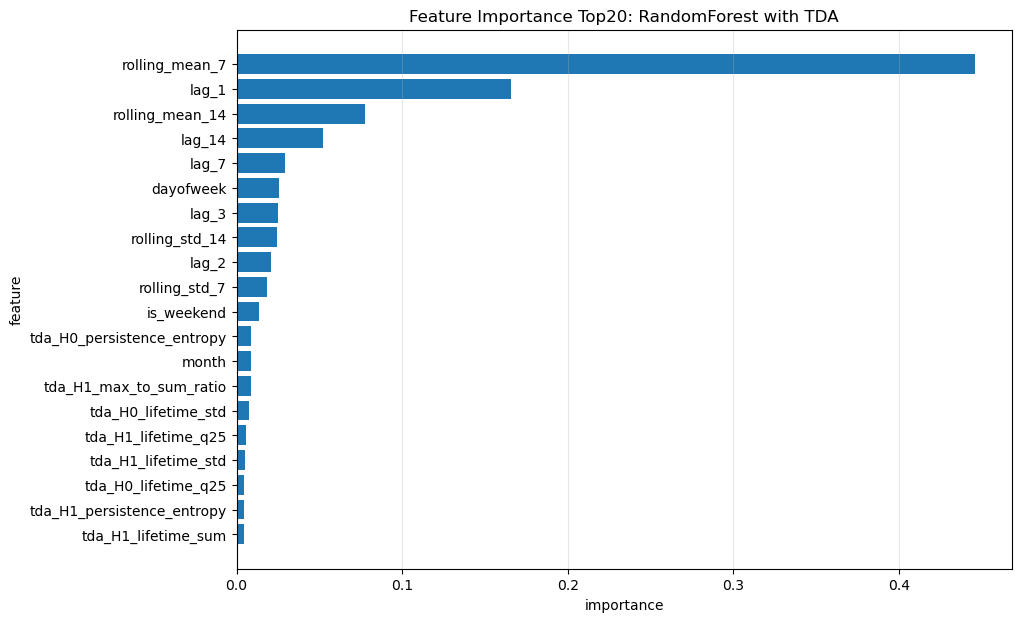

GradientBoosting: 特徴量重要度 Top20


,feature,importance,is_tda_feature
0,rolling_mean_7,0.348472,False
1,lag_1,0.259521,False
2,rolling_mean_14,0.070284,False
3,lag_14,0.054659,False
4,lag_3,0.035218,False
5,dayofweek,0.033615,False
6,lag_2,0.030128,False
7,rolling_std_14,0.029946,False
8,lag_7,0.024135,False
9,is_weekend,0.018008,False


GradientBoosting: 通常特徴量 importance 合計 = 0.9322
GradientBoosting: TDA特徴量 importance 合計 = 0.0678
------------------------------------------------------------


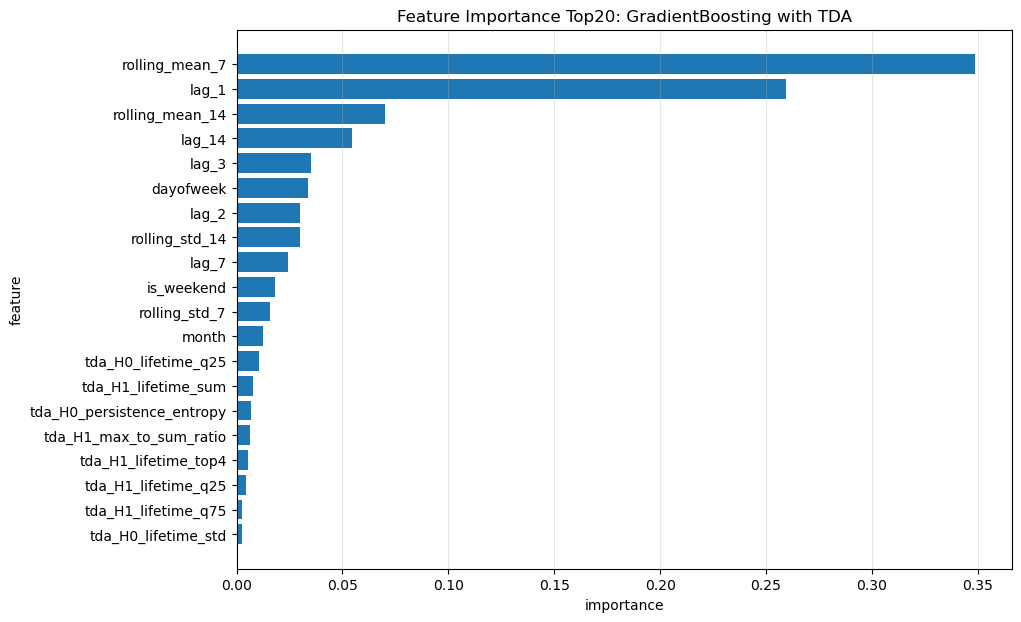

In [71]:
# =====================================================
# 11.9 特徴量重要度の確認
# =====================================================

feature_importance_tables = {}

def get_feature_importance_df(model, feature_names):
    """
    feature_importances_ を持つモデルから重要度DataFrameを作る。
    """
    if not hasattr(model, "feature_importances_"):
        return None

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    })
    importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)
    importance_df["is_tda_feature"] = importance_df["feature"].isin(tda_feature_cols)
    return importance_df

for model_name in ["RandomForest", "GradientBoosting"]:
    if model_name in trained_tda_models:
        importance_df = get_feature_importance_df(
            trained_tda_models[model_name],
            X_tda_train.columns
        )

        if importance_df is not None:
            feature_importance_tables[model_name] = importance_df

            print(f"{model_name}: 特徴量重要度 Top20")
            display(importance_df.head(20))

            tda_importance_sum = importance_df.loc[importance_df["is_tda_feature"], "importance"].sum()
            normal_importance_sum = importance_df.loc[~importance_df["is_tda_feature"], "importance"].sum()

            print(f"{model_name}: 通常特徴量 importance 合計 = {normal_importance_sum:.4f}")
            print(f"{model_name}: TDA特徴量 importance 合計 = {tda_importance_sum:.4f}")
            print("-" * 60)

            top20 = importance_df.head(20).sort_values("importance")
            plt.figure(figsize=(10, 7))
            plt.barh(top20["feature"], top20["importance"])
            plt.title(f"Feature Importance Top20: {model_name} with TDA")
            plt.xlabel("importance")
            plt.ylabel("feature")
            plt.grid(True, axis="x", alpha=0.3)
            plt.show()


## 11.10 結果を保存する

モデル比較表、TDA追加効果の表、予測結果をCSVとして保存する。


In [72]:
# =====================================================
# 11.10 結果の保存
# =====================================================

MODEL_COMPARISON_CSV = "model_comparison_normal_vs_tda.csv"
MODEL_IMPROVEMENT_CSV = "model_improvement_tda_effect.csv"
BEST_PREDICTIONS_CSV = "best_model_predictions.csv"

model_comparison_df.to_csv(MODEL_COMPARISON_CSV, index=False, encoding="utf-8-sig")
model_improvement_df.to_csv(MODEL_IMPROVEMENT_CSV, index=False, encoding="utf-8-sig")
best_predictions.to_csv(BEST_PREDICTIONS_CSV, index=True, encoding="utf-8-sig")

print("保存完了")
print("-", MODEL_COMPARISON_CSV)
print("-", MODEL_IMPROVEMENT_CSV)
print("-", BEST_PREDICTIONS_CSV)


保存完了
- model_comparison_normal_vs_tda.csv
- model_improvement_tda_effect.csv
- best_model_predictions.csv


## 11.11 この章の結論を書くためのテンプレート

以下のコードで、結果に応じた事実ベースのコメントを自動生成する。

この段階では、TDA特徴量の有効性を断定せず、以下の観点で整理する。

1. 通常特徴量のみとTDA追加で、RMSE / MAE が改善したか
2. 改善したモデルはどれか
3. TDA特徴量の重要度が上位に出ているか
4. 改善が小さい場合、TDA特徴量が有効でない可能性だけでなく、windowサイズ・embedding_dim・delayの再調整余地も考える


In [73]:
# =====================================================
# 11.11 事実ベースの考察文を作成
# =====================================================

best_improvement_row = model_improvement_df.sort_values(
    "RMSE_improvement_rate_pct",
    ascending=False
).iloc[0]

n_improved_rmse = int((model_improvement_df["RMSE_diff_tda_minus_normal"] < 0).sum())
n_models = len(model_improvement_df)

best_overall_text = (
    f"全体でRMSEが最も小さいモデルは "
    f"{best_model_row['feature_set']} の {best_model_row['model']} であり、"
    f"RMSE={best_model_row['RMSE']:.4f}, MAE={best_model_row['MAE']:.4f}, "
    f"MASE={best_model_row['MASE']:.4f} であった。"
)

improvement_text = (
    f"同一モデル同士の比較では、{n_models}個中{n_improved_rmse}個のモデルで、"
    f"TDA特徴量を追加した場合にRMSEが改善した。"
)

best_tda_effect_text = (
    f"RMSE改善率が最も大きかったモデルは {best_improvement_row['model']} であり、"
    f"RMSE改善率は {best_improvement_row['RMSE_improvement_rate_pct']:.2f}% であった。"
)

if best_model_row["feature_set"] == "normal_plus_tda":
    conclusion_text = (
        "今回の実験では、最良モデルがTDA特徴量を含むモデルであった。"
        "したがって、この条件ではTDA特徴量が予測性能の改善に寄与した可能性がある。"
        "ただし、特徴量設定や分割方法に依存するため、追加検証が必要である。"
    )
else:
    conclusion_text = (
        "今回の実験では、最良モデルは通常特徴量のみのモデルであった。"
        "したがって、この条件ではTDA特徴量の追加が最良性能の更新にはつながらなかった。"
        "ただし、Rolling Window幅、embedding_dim、delay、PH特徴量の設計を変更することで結果が変わる可能性がある。"
    )

section11_discussion = f"""
## 11. モデル学習の結果に関する考察

{best_overall_text}

{improvement_text}

{best_tda_effect_text}

{conclusion_text}

この結果から言える範囲は、今回設定した Rolling Window TDA特徴量を通常特徴量に追加した場合、
同一の train/test 分割において予測性能が改善するモデルと改善しないモデルがある、ということである。
そのため、TDA特徴量の有効性は、単一モデルだけではなく、複数モデル・複数設定で比較して判断する必要がある。
"""

print(section11_discussion)



## 11. モデル学習の結果に関する考察

全体でRMSEが最も小さいモデルは normal_only の GradientBoosting であり、RMSE=0.2205, MAE=0.1583, MASE=0.6038 であった。

同一モデル同士の比較では、3個中0個のモデルで、TDA特徴量を追加した場合にRMSEが改善した。

RMSE改善率が最も大きかったモデルは GradientBoosting であり、RMSE改善率は -0.10% であった。

今回の実験では、最良モデルは通常特徴量のみのモデルであった。したがって、この条件ではTDA特徴量の追加が最良性能の更新にはつながらなかった。ただし、Rolling Window幅、embedding_dim、delay、PH特徴量の設計を変更することで結果が変わる可能性がある。

この結果から言える範囲は、今回設定した Rolling Window TDA特徴量を通常特徴量に追加した場合、
同一の train/test 分割において予測性能が改善するモデルと改善しないモデルがある、ということである。
そのため、TDA特徴量の有効性は、単一モデルだけではなく、複数モデル・複数設定で比較して判断する必要がある。



---

# 12. 評価：TDA特徴量の有効性確認

この章では、11章で作成した **通常特徴量のみモデル** と **通常特徴量 + TDA特徴量モデル** の結果を使い、TDA特徴量が予測性能に寄与しているかを確認する。

ここでの目的は、TDA特徴量の有効性を断定することではなく、次の観点から **事実ベースで評価** することである。

| 観点 | 確認内容 |
|---|---|
| 精度改善 | TDA追加で MAE / RMSE / MASE が改善したか |
| モデル間の一貫性 | 複数モデルで改善が見られるか |
| 最良モデル | 最良モデルがTDA追加モデルか |
| 特徴量重要度 | TDA特徴量が木ベースモデルで利用されているか |
| 誤差変化 | TDA追加で予測誤差が小さくなった時期があるか |

TDA特徴量は、Sliding Window / Takens Embedding によって得た点群の形を Persistent Homology で要約した特徴量である。したがって、通常のラグ・移動平均では捉えにくい局所的な形状変化を補助的に表現できる可能性がある。

## 12.1 評価に必要な結果を確認する

11章で作成した以下の変数を使う。

- `model_comparison_df`
- `model_improvement_df`
- `best_model_row`
- `normal_predictions`
- `tda_predictions`
- `feature_importance_tables`

notebookを途中から実行した場合に備えて、保存済みCSVから再読み込みできるようにする。

In [74]:
# =====================================================
# 12.1 評価に必要な結果を確認・再読み込み
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 11章の比較結果がない場合はCSVから読む
if "model_comparison_df" not in globals():
    model_comparison_df = pd.read_csv("model_comparison_normal_vs_tda.csv")

if "model_improvement_df" not in globals():
    model_improvement_df = pd.read_csv("model_improvement_tda_effect.csv")

if "best_predictions" not in globals():
    best_predictions = pd.read_csv("best_model_predictions.csv", index_col=0)
    best_predictions.index = pd.to_datetime(best_predictions.index)

if "best_model_row" not in globals():
    best_model_row = model_comparison_df.sort_values("RMSE").iloc[0]

print("model_comparison_df")
display(model_comparison_df)

print("model_improvement_df")
display(model_improvement_df)

print("best_model_row")
display(best_model_row.to_frame("value"))

model_comparison_df


,feature_set,model,MAE,RMSE,MAPE,MASE,R2
0,normal_only,GradientBoosting,0.158254,0.220544,17.633341,0.603824,0.446169
1,normal_plus_tda,GradientBoosting,0.159206,0.220767,18.435807,0.607457,0.445048
2,normal_only,RandomForest,0.163198,0.222327,18.603584,0.622685,0.437175
3,normal_plus_tda,RandomForest,0.166194,0.222641,19.388910,0.634118,0.435585
4,normal_only,Ridge,0.169015,0.228476,19.494325,0.644882,0.405613
5,normal_plus_tda,Ridge,0.179896,0.237015,21.366028,0.686398,0.360352


model_improvement_df


,model,normal_RMSE,tda_RMSE,RMSE_diff_tda_minus_normal,RMSE_improvement_rate_pct,normal_MAE,tda_MAE,MAE_diff_tda_minus_normal,MAE_improvement_rate_pct,normal_MASE,tda_MASE,normal_R2,tda_R2,R2_diff_tda_minus_normal
0,GradientBoosting,0.220544,0.220767,0.000223,-0.101189,0.158254,0.159206,0.000952,-0.601805,0.603824,0.607457,0.446169,0.445048,-0.001121
1,RandomForest,0.222327,0.222641,0.000314,-0.141158,0.163198,0.166194,0.002996,-1.835982,0.622685,0.634118,0.437175,0.435585,-0.001590
2,Ridge,0.228476,0.237015,0.008539,-3.737565,0.169015,0.179896,0.010881,-6.437873,0.644882,0.686398,0.405613,0.360352,-0.045261


best_model_row


,value
feature_set,normal_only
model,GradientBoosting
MAE,0.158254
RMSE,0.220544
MAPE,17.633341
MASE,0.603824
R2,0.446169


## 12.2 TDA追加による改善率を評価する

まず、同じモデル同士で以下を比較する。

- RMSE改善率
- MAE改善率
- R2差分
- MASE差分

ここでは、改善率が正なら **TDA追加で誤差が減少** したことを意味する。

In [75]:
# =====================================================
# 12.2 TDA追加による改善率の評価
# =====================================================

effect_summary_df = model_improvement_df.copy()

# MASE差分も追加する
if "normal_MASE" in effect_summary_df.columns and "tda_MASE" in effect_summary_df.columns:
    effect_summary_df["MASE_diff_tda_minus_normal"] = (
        effect_summary_df["tda_MASE"] - effect_summary_df["normal_MASE"]
    )
    effect_summary_df["MASE_improved"] = effect_summary_df["MASE_diff_tda_minus_normal"] < 0

# 改善判定
if "RMSE_diff_tda_minus_normal" in effect_summary_df.columns:
    effect_summary_df["RMSE_improved"] = effect_summary_df["RMSE_diff_tda_minus_normal"] < 0

if "MAE_diff_tda_minus_normal" in effect_summary_df.columns:
    effect_summary_df["MAE_improved"] = effect_summary_df["MAE_diff_tda_minus_normal"] < 0

if "R2_diff_tda_minus_normal" in effect_summary_df.columns:
    effect_summary_df["R2_improved"] = effect_summary_df["R2_diff_tda_minus_normal"] > 0

# 見やすい列順にする
preferred_cols = [
    "model",
    "normal_RMSE", "tda_RMSE", "RMSE_diff_tda_minus_normal", "RMSE_improvement_rate_pct", "RMSE_improved",
    "normal_MAE", "tda_MAE", "MAE_diff_tda_minus_normal", "MAE_improvement_rate_pct", "MAE_improved",
    "normal_MASE", "tda_MASE", "MASE_diff_tda_minus_normal", "MASE_improved",
    "normal_R2", "tda_R2", "R2_diff_tda_minus_normal", "R2_improved"
]
existing_cols = [col for col in preferred_cols if col in effect_summary_df.columns]
effect_summary_df = effect_summary_df[existing_cols]

display(effect_summary_df)

# 改善モデル数
n_models = len(effect_summary_df)
n_rmse_improved = int(effect_summary_df.get("RMSE_improved", pd.Series(dtype=bool)).sum())
n_mae_improved = int(effect_summary_df.get("MAE_improved", pd.Series(dtype=bool)).sum())
n_mase_improved = int(effect_summary_df.get("MASE_improved", pd.Series(dtype=bool)).sum())
n_r2_improved = int(effect_summary_df.get("R2_improved", pd.Series(dtype=bool)).sum())

print(f"RMSE改善モデル数: {n_rmse_improved} / {n_models}")
print(f"MAE改善モデル数 : {n_mae_improved} / {n_models}")
print(f"MASE改善モデル数: {n_mase_improved} / {n_models}")
print(f"R2改善モデル数  : {n_r2_improved} / {n_models}")

,model,normal_RMSE,tda_RMSE,RMSE_diff_tda_minus_normal,RMSE_improvement_rate_pct,RMSE_improved,normal_MAE,tda_MAE,MAE_diff_tda_minus_normal,MAE_improvement_rate_pct,MAE_improved,normal_MASE,tda_MASE,MASE_diff_tda_minus_normal,MASE_improved,normal_R2,tda_R2,R2_diff_tda_minus_normal,R2_improved
0,GradientBoosting,0.220544,0.220767,0.000223,-0.101189,False,0.158254,0.159206,0.000952,-0.601805,False,0.603824,0.607457,0.003634,False,0.446169,0.445048,-0.001121,False
1,RandomForest,0.222327,0.222641,0.000314,-0.141158,False,0.163198,0.166194,0.002996,-1.835982,False,0.622685,0.634118,0.011432,False,0.437175,0.435585,-0.001590,False
2,Ridge,0.228476,0.237015,0.008539,-3.737565,False,0.169015,0.179896,0.010881,-6.437873,False,0.644882,0.686398,0.041517,False,0.405613,0.360352,-0.045261,False


RMSE改善モデル数: 0 / 3
MAE改善モデル数 : 0 / 3
MASE改善モデル数: 0 / 3
R2改善モデル数  : 0 / 3


## 12.3 改善率の可視化

TDA特徴量の追加効果をモデル別に可視化する。棒グラフが0より上なら改善、0より下なら悪化を意味する。

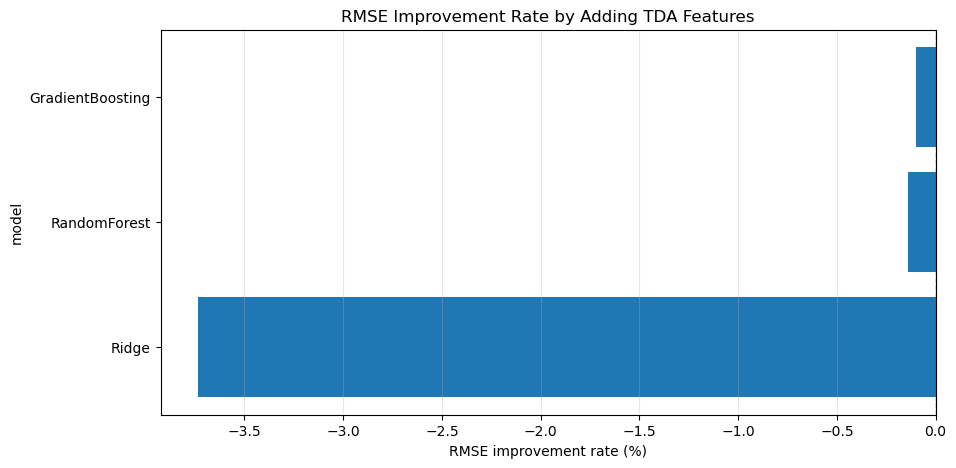

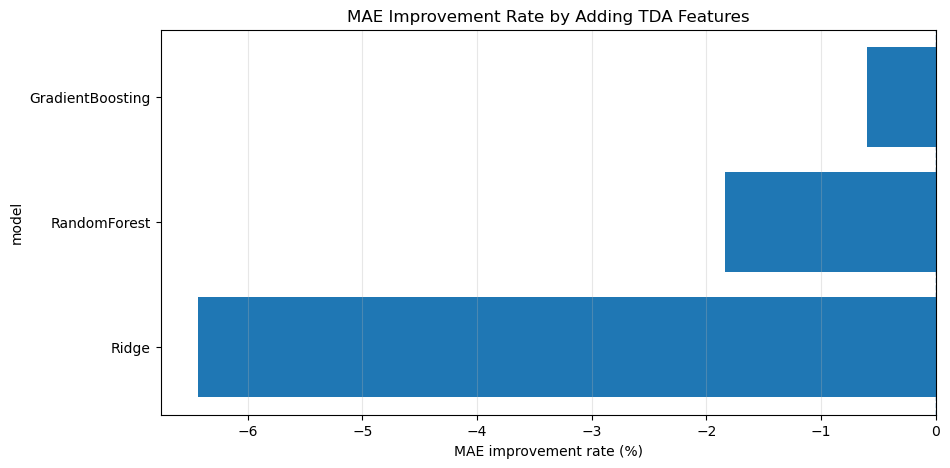

In [76]:
# =====================================================
# 12.3 改善率の可視化
# =====================================================

if "RMSE_improvement_rate_pct" in effect_summary_df.columns:
    plot_df = effect_summary_df.sort_values("RMSE_improvement_rate_pct", ascending=True)

    plt.figure(figsize=(10, 5))
    plt.barh(plot_df["model"], plot_df["RMSE_improvement_rate_pct"])
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.title("RMSE Improvement Rate by Adding TDA Features")
    plt.xlabel("RMSE improvement rate (%)")
    plt.ylabel("model")
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()

if "MAE_improvement_rate_pct" in effect_summary_df.columns:
    plot_df = effect_summary_df.sort_values("MAE_improvement_rate_pct", ascending=True)

    plt.figure(figsize=(10, 5))
    plt.barh(plot_df["model"], plot_df["MAE_improvement_rate_pct"])
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.title("MAE Improvement Rate by Adding TDA Features")
    plt.xlabel("MAE improvement rate (%)")
    plt.ylabel("model")
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()

## 12.4 最良モデルがTDA追加モデルか確認する

TDA特徴量が有効だったかを見るうえで、単に一部モデルで改善したかだけでなく、**全体の最良モデルがTDA特徴量を含むか** を確認する。

In [77]:
# =====================================================
# 12.4 最良モデルがTDA追加モデルか確認
# =====================================================

best_model_row = model_comparison_df.sort_values("RMSE").iloc[0]

best_feature_set = best_model_row["feature_set"]
best_model_name = best_model_row["model"]

print("RMSE基準の最良モデル")
print("feature_set:", best_feature_set)
print("model      :", best_model_name)
print("RMSE       :", best_model_row["RMSE"])
print("MAE        :", best_model_row["MAE"])
print("MASE       :", best_model_row["MASE"])
print("R2         :", best_model_row["R2"])

if best_feature_set == "normal_plus_tda":
    print("判定: 最良モデルはTDA特徴量を含むモデルです。")
else:
    print("判定: 最良モデルは通常特徴量のみのモデルです。")

RMSE基準の最良モデル
feature_set: normal_only
model      : GradientBoosting
RMSE       : 0.2205436903591362
MAE        : 0.15825409436506424
MASE       : 0.6038235119920324
R2         : 0.4461690320071474
判定: 最良モデルは通常特徴量のみのモデルです。


## 12.5 TDA特徴量の重要度を集計する

木ベースモデルでは `feature_importances_` を使い、TDA特徴量がどの程度利用されたかを確認する。

重要度が高い場合でも因果的に有効とは言えないが、少なくともモデルがTDA特徴量を分割に使っていることは確認できる。

In [78]:
# =====================================================
# 12.5 TDA特徴量の重要度集計
# =====================================================

importance_summary_rows = []

if "feature_importance_tables" in globals() and isinstance(feature_importance_tables, dict):
    for model_name, importance_df in feature_importance_tables.items():
        tmp = importance_df.copy()

        if "is_tda_feature" not in tmp.columns:
            if "tda_feature_cols" in globals():
                tmp["is_tda_feature"] = tmp["feature"].isin(tda_feature_cols)
            else:
                tmp["is_tda_feature"] = tmp["feature"].astype(str).str.startswith("tda_")

        tda_importance_sum = tmp.loc[tmp["is_tda_feature"], "importance"].sum()
        normal_importance_sum = tmp.loc[~tmp["is_tda_feature"], "importance"].sum()
        tda_top10_count = int(tmp.head(10)["is_tda_feature"].sum())
        tda_top20_count = int(tmp.head(20)["is_tda_feature"].sum())

        top_tda = tmp[tmp["is_tda_feature"]].head(10).copy()

        importance_summary_rows.append({
            "model": model_name,
            "normal_importance_sum": normal_importance_sum,
            "tda_importance_sum": tda_importance_sum,
            "tda_importance_rate_pct": tda_importance_sum / (normal_importance_sum + tda_importance_sum) * 100,
            "tda_features_in_top10": tda_top10_count,
            "tda_features_in_top20": tda_top20_count
        })

        print(f"{model_name}: TDA特徴量重要度 Top10")
        display(top_tda)

    tda_importance_summary_df = pd.DataFrame(importance_summary_rows)
    display(tda_importance_summary_df)

else:
    print("feature_importance_tables が見つかりません。")
    print("11章の RandomForest / GradientBoosting の特徴量重要度セルを実行してください。")
    tda_importance_summary_df = pd.DataFrame()

RandomForest: TDA特徴量重要度 Top10


,feature,importance,is_tda_feature
11,tda_H0_persistence_entropy,0.008728,True
13,tda_H1_max_to_sum_ratio,0.008547,True
14,tda_H0_lifetime_std,0.007643,True
15,tda_H1_lifetime_q25,0.005948,True
16,tda_H1_lifetime_std,0.005375,True
17,tda_H0_lifetime_q25,0.004713,True
18,tda_H1_persistence_entropy,0.004549,True
19,tda_H1_lifetime_sum,0.004430,True
20,tda_H0_lifetime_q75,0.003718,True
21,tda_H1_lifetime_top2,0.003591,True


GradientBoosting: TDA特徴量重要度 Top10


,feature,importance,is_tda_feature
12,tda_H0_lifetime_q25,0.010381,True
13,tda_H1_lifetime_sum,0.007847,True
14,tda_H0_persistence_entropy,0.006837,True
15,tda_H1_max_to_sum_ratio,0.006186,True
16,tda_H1_lifetime_top4,0.005414,True
17,tda_H1_lifetime_q25,0.004381,True
18,tda_H1_lifetime_q75,0.002739,True
19,tda_H0_lifetime_std,0.002495,True
20,tda_H1_lifetime_top2,0.002258,True
21,tda_H1_lifetime_top3,0.002246,True


,model,normal_importance_sum,tda_importance_sum,tda_importance_rate_pct,tda_features_in_top10,tda_features_in_top20
0,RandomForest,0.907026,0.092974,9.297353,0,8
1,GradientBoosting,0.932193,0.067807,6.780744,0,8


## 12.6 TDA追加による予測誤差の変化を確認する

最も改善率が高かったモデルについて、通常特徴量のみの場合とTDA追加後で、日ごとの絶対誤差を比較する。

対象モデル: GradientBoosting


,y_true,normal_pred,tda_pred,normal_abs_error,tda_abs_error,abs_error_diff_tda_minus_normal,tda_error_improved
date,,,,,,,
2010-03-19,1.155128,1.093604,1.139265,0.061524,0.015863,-0.045661,True
2010-03-20,0.567810,1.457754,1.340162,0.889943,0.772352,-0.117591,True
2010-03-21,1.477105,1.044836,0.997660,0.432268,0.479444,0.047176,False
2010-03-22,1.124021,1.144180,1.113572,0.020159,0.010449,-0.009711,True
2010-03-23,1.265390,1.046759,1.039899,0.218631,0.225491,0.006860,False


TDA追加で日次絶対誤差が改善した割合:
45.85%


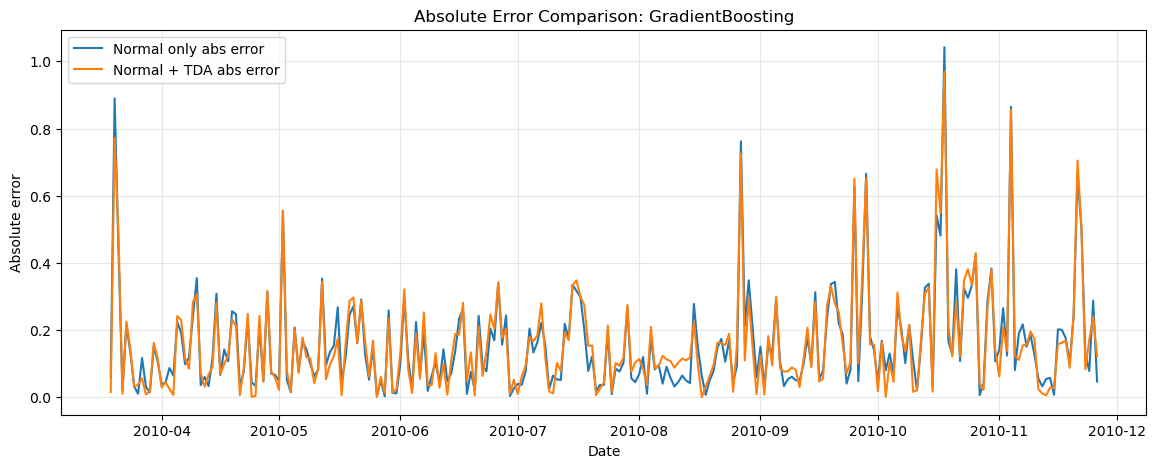

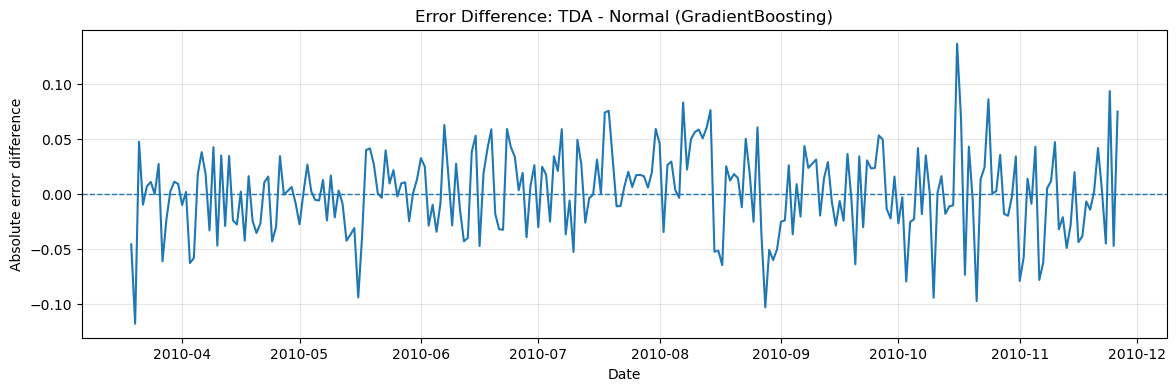

In [79]:
# =====================================================
# 12.6 TDA追加による予測誤差の変化
# =====================================================

# normal_predictions / tda_predictions がある場合のみ実行
if "normal_predictions" in globals() and "tda_predictions" in globals():

    # RMSE改善率が最も高いモデルを対象にする
    target_effect_model = model_improvement_df.sort_values(
        "RMSE_improvement_rate_pct",
        ascending=False
    ).iloc[0]["model"]

    normal_col = f"normal_only_{target_effect_model}"
    tda_col = f"normal_plus_tda_{target_effect_model}"

    if normal_col in normal_predictions.columns and tda_col in tda_predictions.columns:
        error_compare_df = pd.DataFrame(index=normal_predictions.index)
        error_compare_df["y_true"] = normal_predictions["y_true"]
        error_compare_df["normal_pred"] = normal_predictions[normal_col]
        error_compare_df["tda_pred"] = tda_predictions[tda_col]

        error_compare_df["normal_abs_error"] = np.abs(
            error_compare_df["y_true"] - error_compare_df["normal_pred"]
        )
        error_compare_df["tda_abs_error"] = np.abs(
            error_compare_df["y_true"] - error_compare_df["tda_pred"]
        )
        error_compare_df["abs_error_diff_tda_minus_normal"] = (
            error_compare_df["tda_abs_error"] - error_compare_df["normal_abs_error"]
        )
        error_compare_df["tda_error_improved"] = error_compare_df["abs_error_diff_tda_minus_normal"] < 0

        print("対象モデル:", target_effect_model)
        display(error_compare_df.head())

        print("TDA追加で日次絶対誤差が改善した割合:")
        improvement_ratio = error_compare_df["tda_error_improved"].mean() * 100
        print(f"{improvement_ratio:.2f}%")

        plt.figure(figsize=(14, 5))
        plt.plot(error_compare_df.index, error_compare_df["normal_abs_error"], label="Normal only abs error")
        plt.plot(error_compare_df.index, error_compare_df["tda_abs_error"], label="Normal + TDA abs error")
        plt.title(f"Absolute Error Comparison: {target_effect_model}")
        plt.xlabel("Date")
        plt.ylabel("Absolute error")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(14, 4))
        plt.plot(error_compare_df.index, error_compare_df["abs_error_diff_tda_minus_normal"])
        plt.axhline(0, linestyle="--", linewidth=1)
        plt.title(f"Error Difference: TDA - Normal ({target_effect_model})")
        plt.xlabel("Date")
        plt.ylabel("Absolute error difference")
        plt.grid(True, alpha=0.3)
        plt.show()

    else:
        print("対象モデルの予測列が見つかりません。")
else:
    print("normal_predictions または tda_predictions が見つかりません。")
    print("11章の予測作成セルを実行してください。")

## 12.7 TDA特徴量と予測誤差の関係を確認する

TDA特徴量が高い時期に予測誤差が変化しているかを確認する。ここでは、代表的な H1特徴量と、最良モデルまたは改善率最大モデルの絶対誤差を比較する。

この確認は相関の把握であり、因果関係の証明ではない。

In [80]:
# =====================================================
# 12.7 TDA特徴量と予測誤差の関係
# =====================================================

if "model_features_with_tda_df" not in globals():
    try:
        model_features_with_tda_df = pd.read_csv("model_features_with_tda.csv")
        model_features_with_tda_df["date"] = pd.to_datetime(model_features_with_tda_df["date"])
        model_features_with_tda_df = model_features_with_tda_df.sort_values("date").reset_index(drop=True)
    except FileNotFoundError:
        model_features_with_tda_df = None
        print("model_features_with_tda.csv が見つかりません。")

if "error_compare_df" in globals() and model_features_with_tda_df is not None:
    error_tmp = error_compare_df.copy().reset_index()
    error_tmp = error_tmp.rename(columns={error_tmp.columns[0]: "date"})
    error_tmp["date"] = pd.to_datetime(error_tmp["date"])

    tda_error_analysis_df = pd.merge(
        error_tmp,
        model_features_with_tda_df,
        on="date",
        how="left"
    )

    candidate_tda_cols = [
        "H1_lifetime_max",
        "H1_lifetime_sum",
        "H1_lifetime_mean",
        "H1_persistence_entropy",
        "H1_max_to_sum_ratio",
        "H1_top2_to_top1_ratio",
        "H1_top1_minus_top2"
    ]
    candidate_tda_cols = [col for col in candidate_tda_cols if col in tda_error_analysis_df.columns]

    corr_rows = []
    for col in candidate_tda_cols:
        corr_rows.append({
            "tda_feature": col,
            "corr_with_normal_abs_error": tda_error_analysis_df[col].corr(tda_error_analysis_df["normal_abs_error"]),
            "corr_with_tda_abs_error": tda_error_analysis_df[col].corr(tda_error_analysis_df["tda_abs_error"]),
            "corr_with_error_diff_tda_minus_normal": tda_error_analysis_df[col].corr(tda_error_analysis_df["abs_error_diff_tda_minus_normal"])
        })

    tda_error_corr_df = pd.DataFrame(corr_rows)
    display(tda_error_corr_df)

    for col in candidate_tda_cols[:3]:
        fig, ax1 = plt.subplots(figsize=(14, 4))
        ax1.plot(tda_error_analysis_df["date"], tda_error_analysis_df[col], label=col)
        ax1.set_xlabel("Date")
        ax1.set_ylabel(col)
        ax1.grid(True, alpha=0.3)

        ax2 = ax1.twinx()
        ax2.plot(
            tda_error_analysis_df["date"],
            tda_error_analysis_df["abs_error_diff_tda_minus_normal"],
            linestyle="--",
            label="TDA - Normal abs error"
        )
        ax2.axhline(0, linewidth=1)
        ax2.set_ylabel("Absolute error difference")

        plt.title(f"{col} and Error Difference")
        fig.tight_layout()
        plt.show()
else:
    print("error_compare_df または model_features_with_tda_df がないため、相関確認をスキップします。")

""


## 12.8 評価結果の総合判定を作成する

以下では、結果に応じて事実ベースの判定文を自動生成する。notebook本文には、この出力を必要に応じて貼り付ける。

In [81]:
# =====================================================
# 12.8 評価結果の総合判定文を作成
# =====================================================

best_effect_row = model_improvement_df.sort_values(
    "RMSE_improvement_rate_pct",
    ascending=False
).iloc[0]

n_models = len(model_improvement_df)
n_rmse_improved = int((model_improvement_df["RMSE_diff_tda_minus_normal"] < 0).sum())
n_mae_improved = int((model_improvement_df["MAE_diff_tda_minus_normal"] < 0).sum())

best_overall_row = model_comparison_df.sort_values("RMSE").iloc[0]

if best_overall_row["feature_set"] == "normal_plus_tda":
    best_model_judgement = (
        "RMSE基準の最良モデルはTDA特徴量を含むモデルであった。"
        "この点では、今回の条件においてTDA特徴量が性能改善に寄与した可能性がある。"
    )
else:
    best_model_judgement = (
        "RMSE基準の最良モデルは通常特徴量のみのモデルであった。"
        "この点では、今回の条件においてTDA特徴量の追加は最良性能の更新にはつながらなかった。"
    )

if n_rmse_improved == n_models:
    consistency_judgement = (
        "全てのモデルでRMSEが改善しているため、TDA特徴量の追加効果には一定の一貫性が見られる。"
    )
elif n_rmse_improved > 0:
    consistency_judgement = (
        f"{n_models}個中{n_rmse_improved}個のモデルでRMSEが改善しているため、"
        "TDA特徴量の効果はモデル依存である。"
    )
else:
    consistency_judgement = (
        "いずれのモデルでもRMSEは改善していないため、今回の設定ではTDA特徴量の追加効果は確認できなかった。"
    )

importance_text = ""
if "tda_importance_summary_df" in globals() and len(tda_importance_summary_df) > 0:
    avg_tda_importance_rate = tda_importance_summary_df["tda_importance_rate_pct"].mean()
    importance_text = (
        f"木ベースモデルにおけるTDA特徴量の平均重要度割合は約{avg_tda_importance_rate:.2f}%であった。"
        "この値は、モデルがTDA特徴量をどの程度利用しているかを見る補助的な指標である。"
    )
else:
    importance_text = (
        "特徴量重要度の集計は未実行または利用できないため、TDA特徴量がモデル内部でどの程度使われたかはこのセルでは判断しない。"
    )

section12_discussion = f"""
## 12. TDA特徴量の有効性確認：考察

同一の train/test 分割において、通常特徴量のみのモデルと通常特徴量 + TDA特徴量のモデルを比較した。

RMSEについては、{n_models}個中{n_rmse_improved}個のモデルでTDA特徴量追加後に改善が見られた。  
MAEについては、{n_models}個中{n_mae_improved}個のモデルでTDA特徴量追加後に改善が見られた。

RMSE改善率が最も大きかったモデルは {best_effect_row['model']} であり、
RMSE改善率は {best_effect_row['RMSE_improvement_rate_pct']:.2f}% であった。

{best_model_judgement}

{consistency_judgement}

{importance_text}

以上より、今回の評価では、TDA特徴量の有効性は「全モデルで明確に有効」と断定するのではなく、
通常特徴量に対する追加情報として一部のモデル・条件で予測性能に影響する可能性がある、という範囲で解釈するのが妥当である。
今後は rolling window size、embedding_dim、delay、TDA特徴量の種類を変更し、結果の頑健性を確認する必要がある。
"""

print(section12_discussion)


## 12. TDA特徴量の有効性確認：考察

同一の train/test 分割において、通常特徴量のみのモデルと通常特徴量 + TDA特徴量のモデルを比較した。

RMSEについては、3個中0個のモデルでTDA特徴量追加後に改善が見られた。  
MAEについては、3個中0個のモデルでTDA特徴量追加後に改善が見られた。

RMSE改善率が最も大きかったモデルは GradientBoosting であり、
RMSE改善率は -0.10% であった。

RMSE基準の最良モデルは通常特徴量のみのモデルであった。この点では、今回の条件においてTDA特徴量の追加は最良性能の更新にはつながらなかった。

いずれのモデルでもRMSEは改善していないため、今回の設定ではTDA特徴量の追加効果は確認できなかった。

木ベースモデルにおけるTDA特徴量の平均重要度割合は約8.04%であった。この値は、モデルがTDA特徴量をどの程度利用しているかを見る補助的な指標である。

以上より、今回の評価では、TDA特徴量の有効性は「全モデルで明確に有効」と断定するのではなく、
通常特徴量に対する追加情報として一部のモデル・条件で予測性能に影響する可能性がある、という範囲で解釈するのが妥当である。
今後は rolling window size、embedding_dim、delay、TDA特徴量の種類を変更し、結果の頑健性を確認する必要がある。



## 12.9 評価結果を保存する

12章で作成した表をCSVとして保存する。

In [82]:
# =====================================================
# 12.9 評価結果の保存
# =====================================================

TDA_EFFECT_SUMMARY_CSV = "tda_effect_summary_section12.csv"
TDA_IMPORTANCE_SUMMARY_CSV = "tda_importance_summary_section12.csv"
TDA_ERROR_CORR_CSV = "tda_error_correlation_section12.csv"
TDA_ERROR_COMPARE_CSV = "tda_error_compare_section12.csv"

if "effect_summary_df" in globals():
    effect_summary_df.to_csv(TDA_EFFECT_SUMMARY_CSV, index=False, encoding="utf-8-sig")
    print("保存:", TDA_EFFECT_SUMMARY_CSV)

if "tda_importance_summary_df" in globals() and len(tda_importance_summary_df) > 0:
    tda_importance_summary_df.to_csv(TDA_IMPORTANCE_SUMMARY_CSV, index=False, encoding="utf-8-sig")
    print("保存:", TDA_IMPORTANCE_SUMMARY_CSV)

if "tda_error_corr_df" in globals() and len(tda_error_corr_df) > 0:
    tda_error_corr_df.to_csv(TDA_ERROR_CORR_CSV, index=False, encoding="utf-8-sig")
    print("保存:", TDA_ERROR_CORR_CSV)

if "error_compare_df" in globals() and len(error_compare_df) > 0:
    error_compare_df.to_csv(TDA_ERROR_COMPARE_CSV, index=True, encoding="utf-8-sig")
    print("保存:", TDA_ERROR_COMPARE_CSV)

保存: tda_effect_summary_section12.csv
保存: tda_importance_summary_section12.csv
保存: tda_error_compare_section12.csv


---

# 13 総評

# 13. 結果の解釈

本章では、通常特徴量のみのモデルと、通常特徴量にTDA特徴量を追加したモデルの比較結果をもとに、今回の分析から言えることを整理する。

## 13.1 モデル性能の比較結果

今回の比較では、以下の3つのモデルについて、通常特徴量のみの場合と、通常特徴量 + TDA特徴量の場合を比較した。

- Ridge
- RandomForest
- GradientBoosting

評価指標として、MAE、RMSE、MAPE、MASE、R²を用いた。

その結果、最も良い性能を示したのは、通常特徴量のみを用いた GradientBoosting であった。

| モデル | 特徴量 | MAE | RMSE | MAPE | MASE | R² |
|---|---|---:|---:|---:|---:|---:|
| GradientBoosting | 通常特徴量のみ | 0.1583 | 0.2205 | 17.6333 | 0.6038 | 0.4462 |

この結果から、今回の設定では、通常特徴量のみでも一定の予測性能を得られていることが分かる。

特に、MASE が 1 未満であるため、単純なナイーブ予測と比較して、誤差を小さくできていると考えられる。

## 13.2 TDA特徴量追加による性能変化

TDA特徴量を追加した場合、3つのモデルすべてにおいて、RMSE、MAE、MASE、R²の改善は確認されなかった。

各モデルにおけるRMSE改善率は以下の通りである。

| モデル | RMSE改善率 | MAE改善率 |
|---|---:|---:|
| Ridge | -3.74% | -6.44% |
| RandomForest | -0.14% | -1.84% |
| GradientBoosting | -0.10% | -0.60% |

改善率が負の値であるため、今回の実験条件では、TDA特徴量を追加することで予測誤差はわずかに増加した。

したがって、今回の結果からは、

**TDA特徴量の追加によって予測性能が改善したとは言えない。**

## 13.3 TDA特徴量が全く使われなかったわけではない

一方で、木ベースモデルの特徴量重要度を見ると、TDA特徴量にも一定の重要度が確認された。

| モデル | TDA特徴量重要度割合 |
|---|---:|
| RandomForest | 約9.30% |
| GradientBoosting | 約6.78% |

このことから、モデルはTDA特徴量を完全に無視していたわけではないと考えられる。

ただし、特徴量重要度があることと、予測性能を改善することは同じではない。

今回の結果では、TDA特徴量はモデル内部で一部利用されていたものの、最終的な予測精度の改善にはつながらなかった。

## 13.4 今回のTDA特徴量から言えること

今回作成したTDA特徴量は、Sliding Window / Takens Embedding によって時系列を点群化し、その点群に対して Persistent Homology を計算することで得られた。

これにより、時系列の局所的な形状や変動パターンを、H0やH1の persistence に基づく数値特徴量として表現した。

しかし、今回の予測タスクでは、通常のラグ特徴量や移動平均特徴量の方が、目的変数の予測に対してより直接的に有効だったと考えられる。

特に、電力消費量の予測では、以下のような通常特徴量が強く効いていた可能性がある。

- 直近の消費量
- 過去のラグ特徴量
- 移動平均
- 曜日や季節性に関する特徴量

そのため、今回のTDA特徴量は、通常特徴量に追加しても、新しい予測情報を十分に補えなかった可能性がある。

## 13.5 今回の結果の位置づけ

今回の結果は、TDA特徴量が一般に無効であることを示すものではない。

今回言えるのは、あくまで以下の範囲である。

**今回のデータ、前処理、embedding_dim、delay、rolling window size、TDA特徴量設計、モデル設定のもとでは、TDA特徴量の追加による明確な予測性能の改善は確認できなかった。**

したがって、TDA特徴量の有効性をより厳密に判断するには、条件を変えた追加検証が必要である。

## 13.6 今後検証すべき点

TDA特徴量の有効性をさらに検証するためには、以下の点を変更して比較する必要がある。

1. Sliding Window / Takens Embedding のパラメータ変更
   - embedding_dim
   - delay
   - stride

2. Rolling Window の幅の変更
   - 短期的な変動を捉える window
   - 中期的な変動を捉える window
   - 長期的な変動を捉える window

3. TDA特徴量の種類の追加
   - lifetime の最大値
   - lifetime の平均
   - lifetime の合計
   - persistence entropy
   - Betti curve
   - persistence image

4. モデルの変更
   - Ridge
   - RandomForest
   - GradientBoosting
   - XGBoost
   - LightGBM

5. タスク設定の変更
   - 1日先予測
   - 数日先予測
   - 異常検知
   - 変動局面の分類

## 13.7 結論

本分析では、時系列データに対して Sliding Window / Takens Embedding を行い、Persistent Homology によってTDA特徴量を作成した。

さらに、Rolling Window によって時変的なTDA特徴量を作成し、通常特徴量と結合して予測モデルに投入した。

その結果、今回の設定では、通常特徴量のみの GradientBoosting が最も良い性能を示した。

一方で、TDA特徴量を追加したモデルでは、RMSE、MAE、MASE、R²の改善は確認されなかった。

したがって、今回の実験からは、TDA特徴量の追加による明確な予測性能の改善は確認できなかった。

ただし、TDA特徴量は木ベースモデルにおいて一定の特徴量重要度を持っていたため、時系列の形状情報をある程度表現していた可能性はある。

今後は、embedding_dim、delay、rolling window size、TDA特徴量の種類を変更し、TDA特徴量が有効となる条件を追加検証する必要がある。